<div style="background:#1f4e79; color:white; padding:25px; border-radius:8px; font-size:42px; font-weight:bold;">
PART A: SETUP AND MASTER PATHS
</div>

<br>

<div style="font-size:22px; color:#333;">
This section imports libraries, defines all source folders, and creates the new Business Model output folder.
</div>

In [1]:
# ============================================================
# BLOCK 1: Setup, imports, and master paths
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# Reproducibility seeds
GLOBAL_SEED = 12345
np.random.seed(GLOBAL_SEED)


# Main TFM folder
TFM_ROOT = Path("/Users/ileanabeltranperez/Desktop/TFM")

# Existing input folders
BOLETIN_FOLDER = TFM_ROOT / "data" / "boletin visados"
RD_FOLDER = TFM_ROOT / "data" / "RD model data"
HYBRID_OLD_FOLDER = TFM_ROOT / "data" / "hybrid dataset"

# New output folder for the final Business Model dataset
BUSINESS_MODEL_FOLDER = TFM_ROOT / "data" / "Business Model dataset"
BUSINESS_MODEL_FOLDER.mkdir(parents=True, exist_ok=True)

# Raw / source input files
RD_FILE = RD_FOLDER / "Prestamos desembolsados y saldados RD.xlsx"
INE_COST_INDEX_PATH = HYBRID_OLD_FOLDER / "indice de precios de materiales 2021-2025.xlsx"

# Ministerio de Fomento source files (MITMA) 
FILES = sorted(
    list(BOLETIN_FOLDER.glob("*-21.XLS")) +
    list(BOLETIN_FOLDER.glob("*-23.XLS")) +
    list(BOLETIN_FOLDER.glob("*-21.xls")) +
    list(BOLETIN_FOLDER.glob("*-23.xls"))
)

# Final output
FINAL_PATH = BUSINESS_MODEL_FOLDER / "Business_Model.xlsx"

# Checks
print("BOLETIN_FOLDER exists:", BOLETIN_FOLDER.exists(), BOLETIN_FOLDER)
print("RD_FILE exists:", RD_FILE.exists(), RD_FILE)
print("INE cost index exists:", INE_COST_INDEX_PATH.exists(), INE_COST_INDEX_PATH)
print("MITMA source files found:", len(FILES))
print("BUSINESS_MODEL_FOLDER exists:", BUSINESS_MODEL_FOLDER.exists(), BUSINESS_MODEL_FOLDER)
print("FINAL_PATH:", FINAL_PATH)

# Compatibility alias for original Provincias.ipynb code
FOLDER = BUSINESS_MODEL_FOLDER

BOLETIN_FOLDER exists: True /Users/ileanabeltranperez/Desktop/TFM/data/boletin visados
RD_FILE exists: True /Users/ileanabeltranperez/Desktop/TFM/data/RD model data/Prestamos desembolsados y saldados RD.xlsx
INE cost index exists: True /Users/ileanabeltranperez/Desktop/TFM/data/hybrid dataset/indice de precios de materiales 2021-2025.xlsx
MITMA source files found: 10
BUSINESS_MODEL_FOLDER exists: True /Users/ileanabeltranperez/Desktop/TFM/data/Business Model dataset
FINAL_PATH: /Users/ileanabeltranperez/Desktop/TFM/data/Business Model dataset/Business_Model.xlsx


<div style="background:#1f4e79; color:white; padding:25px; border-radius:8px; font-size:42px; font-weight:bold;">
PART B: MINISTERIO DE FOMENTO PROVINCIAS DATASET (MITMA)
</div>

<br>

<div style="font-size:22px; color:#333;">
This section builds the MITMA province-level dataset using visados, surface area, growth, volatility, future labels, and Score Zona.
</div>

In [2]:
# ============================================================
# BLOCK 2: Provincias setup
# Source notebook: Provincias.ipynb
# ============================================================

# identify

assert len(FILES) > 0, "Run the import/setup cell first (it defines FILES)."

def parse_filename(file_path):   # Example: "Madrid-21.XLS" -> ("Madrid", 21)
    stem = Path(file_path).stem
    prov, tab = stem.split("-")
    return prov.strip(), int(tab.strip())

def read_xls(file_path):  # Reads one XLS file 
    return pd.read_excel(file_path, engine="xlrd")

def year_rows_mask(df, year_col_idx=0): # Year is stored in the first column inside the rows (not in headers)
    y = pd.to_numeric(df.iloc[:, year_col_idx], errors="coerce")
    return (y >= 1900) & (y <= 2100)

In [3]:
# ============================================================
# BLOCK 3: Extract MITMA tables
# Source notebook: Provincias.ipynb
# Purpose:
#   - Define extraction functions for MITMA table 21 and table 23
# Functions created:
#   - extract_21_yearly()
#   - extract_23_yearly()
# Columns created:
#   - Año
#   - Visados Viviendas
#   - Superficie a Construir m2
# ============================================================

# extract

def extract_21_yearly(df):
    """
    Tabla 21 (viviendas):
    - Year is in column 0 (rows)
    - Total viviendas is in column 10 (based on your Madrid-21 layout)
    """
    mask = year_rows_mask(df, 0)

    out = pd.DataFrame({
        "Año": pd.to_numeric(df.loc[mask, df.columns[0]], errors="coerce").astype("Int64"),
        "Visados Viviendas": pd.to_numeric(df.loc[mask, df.columns[10]], errors="coerce")
    }).dropna(subset=["Año", "Visados Viviendas"])

    return out

def extract_23_yearly(df):
    """
    Tabla 23 (m2):
    - Year is in column 0 (rows)
    - Value column is not consistent in headers, so we pick the numeric column
      with the most numeric values on the year rows.
    Returns: (dataframe, best_col_index_used)
    """
    mask = year_rows_mask(df, 0)
    df_year = df.loc[mask].copy()

    best_col = None
    best_count = -1

    for i in range(1, df.shape[1]):  # skip year col (0)
        s = pd.to_numeric(df_year.iloc[:, i], errors="coerce")
        cnt = s.notna().sum()
        if cnt > best_count:
            best_count = cnt
            best_col = i

    out = pd.DataFrame({
        "Año": pd.to_numeric(df_year.iloc[:, 0], errors="coerce").astype("Int64"),
        "Superficie a Construir m2": pd.to_numeric(df_year.iloc[:, best_col], errors="coerce")
    }).dropna(subset=["Año", "Superficie a Construir m2"])

    return out, best_col

In [4]:
# ============================================================
# BLOCK 4: Build MITMA provincias dataset
# Source notebook: Provincias.ipynb
# Purpose:
#   - Read files
#   - Merge table 21 and table 23 by Provincia and Año
# DataFrames created:
#   - d21
#   - d23
#   - panel
# Columns created:
#   - Provincia
#   - Año
#   - Visados Viviendas
#   - Superficie a Construir m2
#   - m2 por Vivienda
#   - Crecimiento YoY Viviendas
#   - Crecimiento YoY m2
# Files created:
#   - none
# ============================================================

# build dataset

rows_21, rows_23 = [], []
best_cols_23 = {}

for f in FILES:
    prov, tab = parse_filename(f)
    df = read_xls(f)

    if tab == 21:
        tmp = extract_21_yearly(df)
        tmp["Provincia"] = prov
        rows_21.append(tmp)

    elif tab == 23:
        tmp, best_col = extract_23_yearly(df)
        tmp["Provincia"] = prov
        rows_23.append(tmp)
        best_cols_23[prov] = best_col

d21 = pd.concat(rows_21, ignore_index=True)
d23 = pd.concat(rows_23, ignore_index=True)

# Merge 21 + 23 into Provincia–Año
panel = d21.merge(d23, on=["Provincia", "Año"], how="outer").sort_values(["Provincia", "Año"])

# Feature: m2 per vivienda
panel["m2 por Vivienda"] = panel["Superficie a Construir m2"] / panel["Visados Viviendas"]

# YoY features
panel["Crecimiento YoY Viviendas"] = panel.groupby("Provincia")["Visados Viviendas"].pct_change(1)
panel["Crecimiento YoY m2"] = panel.groupby("Provincia")["Superficie a Construir m2"].pct_change(1)

print("MITMA annual province dataset created in memory.")
print("Tabla 23 chosen column index by province:", best_cols_23)

display(panel.head(25))

WARNING *** file size (1122240) not 512 + multiple of sector size (512)
WARNING *** file size (1097664) not 512 + multiple of sector size (512)
WARNING *** file size (1122240) not 512 + multiple of sector size (512)
WARNING *** file size (1097664) not 512 + multiple of sector size (512)
WARNING *** file size (1122240) not 512 + multiple of sector size (512)
WARNING *** file size (1097664) not 512 + multiple of sector size (512)
WARNING *** file size (1122240) not 512 + multiple of sector size (512)
WARNING *** file size (1097664) not 512 + multiple of sector size (512)
WARNING *** file size (1122240) not 512 + multiple of sector size (512)
WARNING *** file size (1097664) not 512 + multiple of sector size (512)
MITMA annual province dataset created in memory.
Tabla 23 chosen column index by province: {'Alicante': 2, 'Barcelona': 2, 'Madrid': 2, 'Malaga': 2, 'Valencia': 2}


,Año,Visados Viviendas,Provincia,Superficie a Construir m2,m2 por Vivienda,Crecimiento YoY Viviendas,Crecimiento YoY m2
0,1991,61.0,Alicante,151727.0,2487.327869,NaN,NaN
1,1992,30.0,Alicante,88053.0,2935.100000,-0.508197,-0.419662
2,1993,79.0,Alicante,117201.0,1483.556962,1.633333,0.331028
3,1994,67.0,Alicante,162541.0,2425.985075,-0.151899,0.386857
4,1995,54.0,Alicante,96060.0,1778.888889,-0.194030,-0.409011
5,1996,32.0,Alicante,157858.0,4933.062500,-0.407407,0.643327
6,1997,88.0,Alicante,377288.0,4287.363636,1.750000,1.390047
7,1998,106.0,Alicante,577671.0,5449.726415,0.204545,0.531114
8,1999,127.0,Alicante,440183.0,3466.007874,0.198113,-0.238004
9,2000,149.0,Alicante,473193.0,3175.791946,0.173228,0.074992


In [5]:
# ============================================================
# BLOCK 5: MITMA features and future targets
# Source notebook: Provincias.ipynb
# Purpose:
#   - Create historical growth, volatility, and next-year target variables
# Columns created:
#   - m2 por Vivienda
#   - Crecimiento YoY Viviendas
#   - Crecimiento YoY m2
#   - Volatilidad 4A Viviendas
#   - Volatilidad 4A m2
#   - Viviendas Siguiente Año
#   - m2 Siguiente Año
# ============================================================


panel = panel.sort_values(["Provincia", "Año"]).reset_index(drop=True)

panel["m2 por Vivienda"] = panel["Superficie a Construir m2"] / panel["Visados Viviendas"]
panel["Crecimiento YoY Viviendas"] = panel.groupby("Provincia")["Visados Viviendas"].pct_change(1)
panel["Crecimiento YoY m2"] = panel.groupby("Provincia")["Superficie a Construir m2"].pct_change(1)

panel["Volatilidad 4A Viviendas"] = (
    panel.groupby("Provincia")["Visados Viviendas"].rolling(4).std().reset_index(level=0, drop=True)
)
panel["Volatilidad 4A m2"] = (
    panel.groupby("Provincia")["Superficie a Construir m2"].rolling(4).std().reset_index(level=0, drop=True)
)

panel["Viviendas Siguiente Año"] = panel.groupby("Provincia")["Visados Viviendas"].shift(-1)
panel["m2 Siguiente Año"] = panel.groupby("Provincia")["Superficie a Construir m2"].shift(-1)

print("MITMA features created.")
print("Rows:", len(panel))
print("Columns:", len(panel.columns))
display(panel.head())

MITMA features created.
Rows: 255
Columns: 11


,Año,Visados Viviendas,Provincia,Superficie a Construir m2,m2 por Vivienda,Crecimiento YoY Viviendas,Crecimiento YoY m2,Volatilidad 4A Viviendas,Volatilidad 4A m2,Viviendas Siguiente Año,m2 Siguiente Año
0,1991,61.0,Alicante,151727.0,2487.327869,NaN,NaN,NaN,NaN,30.0,88053.0
1,1992,30.0,Alicante,88053.0,2935.100000,-0.508197,-0.419662,NaN,NaN,79.0,117201.0
2,1993,79.0,Alicante,117201.0,1483.556962,1.633333,0.331028,NaN,NaN,67.0,162541.0
3,1994,67.0,Alicante,162541.0,2425.985075,-0.151899,0.386857,20.886599,33932.714299,54.0,96060.0
4,1995,54.0,Alicante,96060.0,1778.888889,-0.194030,-0.409011,20.984121,33397.306452,32.0,157858.0


In [6]:
# ============================================================
# BLOCK 6: MITMA zona buena labels
# Source notebook: Provincias.ipynb
# Columns created:
#   - Zona Buena Top2 Siguiente Año
#   - Zona Buena Above Median Siguiente Año
# ============================================================

panel["Zona Buena Top2 Siguiente Año"] = 0
panel["Zona Buena Above Median Siguiente Año"] = 0

for year, g in panel.groupby("Año"):
    s = g["Viviendas Siguiente Año"]
    valid = s.notna()
    
    if valid.sum() < 3:
        continue

    ranks = s[valid].rank(method="first", ascending=False)
    top2_idx = ranks[ranks <= 2].index
    panel.loc[top2_idx, "Zona Buena Top2 Siguiente Año"] = 1

    med = s[valid].median()
    above_idx = s[valid][s[valid] > med].index
    panel.loc[above_idx, "Zona Buena Above Median Siguiente Año"] = 1

print("MITMA zona buena labels created.")
print(panel[["Zona Buena Top2 Siguiente Año", "Zona Buena Above Median Siguiente Año"]].sum())
display(panel[[
    "Provincia",
    "Año",
    "Viviendas Siguiente Año",
    "Zona Buena Top2 Siguiente Año",
    "Zona Buena Above Median Siguiente Año"
]].head(20))

MITMA zona buena labels created.
Zona Buena Top2 Siguiente Año             70
Zona Buena Above Median Siguiente Año    108
dtype: int64


,Provincia,Año,Viviendas Siguiente Año,Zona Buena Top2 Siguiente Año,Zona Buena Above Median Siguiente Año
0,Alicante,1991,30.0,0,0
1,Alicante,1992,79.0,0,0
2,Alicante,1993,67.0,0,0
3,Alicante,1994,54.0,0,0
4,Alicante,1995,32.0,0,0
5,Alicante,1996,88.0,0,0
6,Alicante,1997,106.0,0,0
7,Alicante,1998,127.0,0,0
8,Alicante,1999,149.0,0,0
9,Alicante,2000,136.0,0,0


In [7]:
# ============================================================
# BLOCK 7: MITMA score zona
# Source notebook: Provincias.ipynb
# Column created:
#   - Score Zona (nivel+tendencia-volatilidad)
# Formula:
#   z(Visados Viviendas) + z(Crecimiento YoY Viviendas) - z(Volatilidad 4A Viviendas)
# ============================================================

def zscore(x):
    x = np.asarray(x, dtype=float)

    if np.all(np.isnan(x)):
        return np.full_like(x, np.nan)

    mu = np.nanmean(x)
    sd = np.nanstd(x)

    if sd == 0 or np.isnan(sd):
        return np.full_like(x, np.nan)

    return (x - mu) / sd

panel["Score Zona (nivel+tendencia-volatilidad)"] = (
    panel.groupby("Año")["Visados Viviendas"].transform(zscore)
    + panel.groupby("Año")["Crecimiento YoY Viviendas"].transform(zscore)
    - panel.groupby("Año")["Volatilidad 4A Viviendas"].transform(zscore)
)

print("MITMA Score Zona created.")
display(panel[[
    "Provincia",
    "Año",
    "Visados Viviendas",
    "Crecimiento YoY Viviendas",
    "Volatilidad 4A Viviendas",
    "Score Zona (nivel+tendencia-volatilidad)"
]].head(20))

MITMA Score Zona created.


,Provincia,Año,Visados Viviendas,Crecimiento YoY Viviendas,Volatilidad 4A Viviendas,Score Zona (nivel+tendencia-volatilidad)
0,Alicante,1991,61.0,NaN,NaN,NaN
1,Alicante,1992,30.0,-0.508197,NaN,NaN
2,Alicante,1993,79.0,1.633333,NaN,NaN
3,Alicante,1994,67.0,-0.151899,20.886599,-0.626734
4,Alicante,1995,54.0,-0.194030,20.984121,-0.162506
5,Alicante,1996,32.0,-0.407407,20.116328,-1.000129
6,Alicante,1997,88.0,1.750000,23.471614,1.281091
7,Alicante,1998,106.0,0.204545,33.266600,-0.135966
8,Alicante,1999,127.0,0.198113,40.746165,-0.497926
9,Alicante,2000,149.0,0.173228,26.362853,-0.027433


In [8]:
# ============================================================
# BLOCK 8: Finalize MITMA dataset
# Source notebook:
#   - Provincias.ipynb
# Purpose:
#   - Finalize MITMA province-level dataset for use in the Business Model pipeline
# DataFrame finalized:
#   - panel
# Files created:
#   - None
# ============================================================

print("MITMA dataset finalized.")
print("Final MITMA rows:", len(panel))
print("Final MITMA columns:", len(panel.columns))
print("Columns:")
print(panel.columns.tolist())

MITMA dataset finalized.
Final MITMA rows: 255
Final MITMA columns: 14
Columns:
['Año', 'Visados Viviendas', 'Provincia', 'Superficie a Construir m2', 'm2 por Vivienda', 'Crecimiento YoY Viviendas', 'Crecimiento YoY m2', 'Volatilidad 4A Viviendas', 'Volatilidad 4A m2', 'Viviendas Siguiente Año', 'm2 Siguiente Año', 'Zona Buena Top2 Siguiente Año', 'Zona Buena Above Median Siguiente Año', 'Score Zona (nivel+tendencia-volatilidad)']


<div style="background:#1f4e79; color:white; padding:25px; border-radius:8px; font-size:42px; font-weight:bold;">
PART C: RD SALDADOS DATASET
</div>

<br>

<div style="font-size:22px; color:#333;">
This section loads RD desembolsados and saldados data, then creates borrower history proxy variables for the Modelo A Business Model.
</div>


In [9]:
# ============================================================
# BLOCK 9: RD saldados setup and sheet check
# Source notebook:
#   - Data Prestamos (RD).ipynb
# Purpose:
#   - Validate RD source file
#   - Inspect available sheets
# Key variables used:
#   - RD_FILE
# DataFrames created:
#   - None
# Columns created:
#   - None
# ============================================================

assert RD_FILE.exists(), f"File not found: {RD_FILE}"
print("OK:", RD_FILE)

xls = pd.ExcelFile(RD_FILE)
print("Sheets:", xls.sheet_names)

OK: /Users/ileanabeltranperez/Desktop/TFM/data/RD model data/Prestamos desembolsados y saldados RD.xlsx
Sheets: ['Prestamos desembolsados', 'Prestamos saldados']


In [10]:
# ============================================================
# BLOCK 10: Load RD desembolsados and saldados
# Source notebook:
#   - Data Prestamos (RD).ipynb
# Purpose:
#   - Load the two RD sheets used for borrower proxy history
# DataFrames created:
#   - df_des
#   - df_sal
# Columns created:
#   - None
# ============================================================

df_des = pd.read_excel(RD_FILE, sheet_name="Prestamos desembolsados")
df_sal = pd.read_excel(RD_FILE, sheet_name="Prestamos saldados")

print("Desembolsados:", df_des.shape)
print("Saldados:", df_sal.shape)

display(df_des.head())

Desembolsados: (51, 8)
Saldados: (91, 10)


,Sec.,Código,No. Prest.,Nombre,Dirección,Teléfono,Negocio,Valor (RD$)
0,1,4,416,GLORIA MIGUELINA BERNARD,"CALLE B #36, URBANIZACION SAVICA DE MENDOZA",(561) 574-4569,PERSONAL,2100.00
1,2,4,444,GLORIA MIGUELINA BERNARD,"CALLE B #36, URBANIZACION SAVICA DE MENDOZA",(561) 574-4569,PERSONAL,3150.00
2,3,15,391,ROBERTO NOVA/ALBA LUZ ALCANTARA,"AUT, SAN NISIDRO #1, RES, TITO III",(305) 915-3547,PERSONAL,10094.01
3,4,22,402,CELANDIA RICART/ALBA LIDIA RAMIREZ,"AV.LEOPOLDO NAVARRO#33, DON BOSCO",(829) 652-6333,PERSONAL,4221.00
4,5,34,453,FELIPE OMAR ACHECAR,"C/ PEDRO ENRIQUEZ UREÑA ESQ. GALVAN APTO. 1-E,...",(809) 274-8192,PERSONAL,200000.00


In [11]:
# ============================================================
# BLOCK 11: Create RD client key
# Source notebook:
#   - Data Prestamos (RD).ipynb
# Purpose:
#   - Build client-level linkage between desembolsados and saldados
# Columns created:
#   - Codigo_cliente
# ============================================================

# Clean column names to avoid invisible spaces
df_des.columns = df_des.columns.str.strip()
df_sal.columns = df_sal.columns.str.strip()

# Desembolsados: Codigo_cliente comes from "Código"
df_des["Codigo_cliente"] = (
    df_des["Código"]
    .astype(str)
    .str.replace("'", "", regex=False)
    .str.strip()
)
df_des["Codigo_cliente"] = pd.to_numeric(df_des["Codigo_cliente"], errors="coerce")

# Saldados: extract code from "Código y Nombre del Cliente", e.g. "000108.- NAME"
df_sal["Codigo_cliente"] = (
    df_sal["Código y Nombre del Cliente"]
    .astype(str)
    .str.extract(r"^\s*0*(\d+)\s*\.-", expand=False)
)
df_sal["Codigo_cliente"] = pd.to_numeric(df_sal["Codigo_cliente"], errors="coerce")

print("Null client codes des:", df_des["Codigo_cliente"].isna().sum())
print("Null client codes sal:", df_sal["Codigo_cliente"].isna().sum())

overlap_clients = set(df_des["Codigo_cliente"].dropna()) & set(df_sal["Codigo_cliente"].dropna())
print("Client overlap count:", len(overlap_clients))
print("Sample overlap:", list(overlap_clients)[:10])

Null client codes des: 0
Null client codes sal: 0
Client overlap count: 29
Sample overlap: [4, 139, 142, 15, 157, 159, 34, 163, 42, 44]


In [12]:
# ============================================================
# BLOCK 12: RD client history, merge, and final tidy
# Source notebook:
#   - Data Prestamos (RD).ipynb
# Purpose:
#   - Create client history from Saldados
#   - Merge into Desembolsados
#   - Leave df_final ready to export
# Columns created:
#   - prestamos_saldados
#   - fecha_ultimo_pago
#   - total_valor_saldado
#   - total_ultimo_pago
#   - ha_saldado_antes
# DataFrames created:
#   - client_hist
#   - df_final
# ============================================================

import pandas as pd

# Fix date types in Saldados
df_sal["Fec. Últ. Pago"] = pd.to_datetime(df_sal["Fec. Últ. Pago"], errors="coerce", dayfirst=True)

# Ensure numeric columns in Saldados are numeric
for c in ["Valor (RD$)", "Último Pago"]:
    if c in df_sal.columns:
        df_sal[c] = pd.to_numeric(df_sal[c], errors="coerce")

# Aggregate Saldados to client-level history
client_hist = (
    df_sal.dropna(subset=["Codigo_cliente"])
          .groupby("Codigo_cliente", as_index=False)
          .agg(
              prestamos_saldados=("No. Prest.", "nunique"),
              fecha_ultimo_pago=("Fec. Últ. Pago", "max"),
              total_valor_saldado=("Valor (RD$)", "sum"),
              total_ultimo_pago=("Último Pago", "sum") if "Último Pago" in df_sal.columns else ("No. Prest.", "size"),
          )
)

# Merge history into Desembolsados
df_final = df_des.merge(client_hist, on="Codigo_cliente", how="left")

# Final clean
if "Valor (RD$)" in df_final.columns:
    df_final["Valor (RD$)"] = pd.to_numeric(df_final["Valor (RD$)"], errors="coerce")

df_final["prestamos_saldados"] = pd.to_numeric(df_final["prestamos_saldados"], errors="coerce").fillna(0).astype(int)
df_final["ha_saldado_antes"] = (df_final["prestamos_saldados"] > 0).astype(int)

for c in ["total_valor_saldado", "total_ultimo_pago"]:
    if c in df_final.columns:
        df_final[c] = pd.to_numeric(df_final[c], errors="coerce").fillna(0)

# Format fecha_ultimo_pago to date only, no time
df_final["fecha_ultimo_pago"] = pd.to_datetime(df_final["fecha_ultimo_pago"], errors="coerce").dt.date

# Drop redundant client code column if present, keep Codigo_cliente only
if "Código" in df_final.columns:
    df_final = df_final.drop(columns=["Código"])

print("df_final shape:", df_final.shape)
print("Share ha_saldado_antes:", df_final["ha_saldado_antes"].mean())
df_final.head(10)

df_final shape: (51, 13)
Share ha_saldado_antes: 0.7058823529411765


,Sec.,No. Prest.,Nombre,Dirección,Teléfono,Negocio,Valor (RD$),Codigo_cliente,prestamos_saldados,fecha_ultimo_pago,total_valor_saldado,total_ultimo_pago,ha_saldado_antes
0,1,416,GLORIA MIGUELINA BERNARD,"CALLE B #36, URBANIZACION SAVICA DE MENDOZA",(561) 574-4569,PERSONAL,2100.00,4,2,2025-10-27,8125.0,1100.50,1
1,2,444,GLORIA MIGUELINA BERNARD,"CALLE B #36, URBANIZACION SAVICA DE MENDOZA",(561) 574-4569,PERSONAL,3150.00,4,2,2025-10-27,8125.0,1100.50,1
2,3,391,ROBERTO NOVA/ALBA LUZ ALCANTARA,"AUT, SAN NISIDRO #1, RES, TITO III",(305) 915-3547,PERSONAL,10094.01,15,1,2024-03-24,7547.5,5591.38,1
3,4,402,CELANDIA RICART/ALBA LIDIA RAMIREZ,"AV.LEOPOLDO NAVARRO#33, DON BOSCO",(829) 652-6333,PERSONAL,4221.00,22,0,NaT,0.0,0.00,0
4,5,453,FELIPE OMAR ACHECAR,"C/ PEDRO ENRIQUEZ UREÑA ESQ. GALVAN APTO. 1-E,...",(809) 274-8192,PERSONAL,200000.00,34,2,2024-07-25,491100.0,478153.00,1
5,6,457,HANDER ALCANTARA LORENZO,"C/INTERIOR G #58, ENSANCHE ESPAILLAT",(829) 900-9773,PERSONAL,1050.00,36,0,NaT,0.0,0.00,0
6,7,369,STEVEN OMAR ACHECAR MENDEZ,"C/INTERIOR B #2, MATA HAMBRE LA FERIA",(829) 821-9145,PERSONAL,2000.00,42,4,2025-06-08,454446.0,296456.00,1
7,8,426,STEVEN OMAR ACHECAR MENDEZ,"C/ INTERIOR B #2, MATA HAMBRE LA FERIA",(829) 821-9145,PERSONAL,470042.00,42,4,2025-06-08,454446.0,296456.00,1
8,9,423,JUAN ZACARIAS MIESES,ESTADOS UNIDOS,(718) 902-7879,PERSONAL,3170.00,44,1,2024-06-08,3170.0,569.05,1
9,10,441,ENMANUEL PEREZ,"AV. LEOPOLDO NAVARRO #33, DON BOSCO",(849) 201-9245,PERSONAL,40216.30,45,5,2025-06-11,598399.1,554545.61,1


In [13]:
# ============================================================
# BLOCK 13: Finalize RD saldados dataset
# Source notebook:
#   - Data Prestamos (RD).ipynb
# Purpose:
#   - Finalize RD borrower proxy dataset for use in the Business Model pipeline
# DataFrame finalized:
#   - df_final
# Files created:
#   - None
# ============================================================

print("RD saldados dataset finalized.")
print("Final RD rows:", len(df_final))
print("Final RD columns:", len(df_final.columns))
print("Columns:")
print(df_final.columns.tolist())

RD saldados dataset finalized.
Final RD rows: 51
Final RD columns: 13
Columns:
['Sec.', 'No. Prest.', 'Nombre', 'Dirección', 'Teléfono', 'Negocio', 'Valor (RD$)', 'Codigo_cliente', 'prestamos_saldados', 'fecha_ultimo_pago', 'total_valor_saldado', 'total_ultimo_pago', 'ha_saldado_antes']


<div style="background:#1f4e79; color:white; padding:25px; border-radius:8px; font-size:42px; font-weight:bold;">
PART D: BUSINESS MODEL DATASET BUILD
</div>

<br>

<div style="font-size:22px; color:#333;">
This section merges MITMA zone data and RD borrower proxy data, then builds the base hybrid dataset.
</div>

In [14]:
# ============================================================
# BLOCK 14: Load Business Model input DataFrames
# Source notebooks:
#   - Provincias.ipynb
#   - Data Prestamos (RD).ipynb
# Purpose:
#   - Use MITMA and RD datasets already created in this notebook
# DataFrames created:
#   - MITMA
#   - rd
# Columns created:
#   - None
# ============================================================

mitma = panel.copy()
rd = df_final.copy()

mitma.columns = mitma.columns.str.strip()
rd.columns = rd.columns.str.strip()

print("MITMA shape:", mitma.shape)
print("RD shape:", rd.shape)

print("\nMITMA columns:")
for col in mitma.columns:
    print("-", col)

print("\nRD columns:")
for col in rd.columns:
    print("-", col)

MITMA shape: (255, 14)
RD shape: (51, 13)

MITMA columns:
- Año
- Visados Viviendas
- Provincia
- Superficie a Construir m2
- m2 por Vivienda
- Crecimiento YoY Viviendas
- Crecimiento YoY m2
- Volatilidad 4A Viviendas
- Volatilidad 4A m2
- Viviendas Siguiente Año
- m2 Siguiente Año
- Zona Buena Top2 Siguiente Año
- Zona Buena Above Median Siguiente Año
- Score Zona (nivel+tendencia-volatilidad)

RD columns:
- Sec.
- No. Prest.
- Nombre
- Dirección
- Teléfono
- Negocio
- Valor (RD$)
- Codigo_cliente
- prestamos_saldados
- fecha_ultimo_pago
- total_valor_saldado
- total_ultimo_pago
- ha_saldado_antes


In [15]:
# ============================================================
# BLOCK 15: Validate required input columns
# Source notebook:
#   - Hybrid.ipynb
# Purpose:
#   - Validate that MITMA and RD input DataFrames contain the required columns
# Lists created:
#   - mitma_feature_cols
#   - mitma_validation_cols
#   - required_mitma_cols
#   - rd_cols
# Columns created:
#   - None
# ============================================================

mitma_feature_cols = [
    "Año",
    "Provincia",
    "Visados Viviendas",
    "Superficie a Construir m2",
    "m2 por Vivienda",
    "Crecimiento YoY Viviendas",
    "Crecimiento YoY m2",
    "Volatilidad 4A Viviendas",
    "Volatilidad 4A m2",
    "Score Zona (nivel+tendencia-volatilidad)"
]

mitma_validation_cols = [
    "Viviendas Siguiente Año",
    "m2 Siguiente Año",
    "Zona Buena Top2 Siguiente Año",
    "Zona Buena Above Median Siguiente Año"
]

required_mitma_cols = mitma_feature_cols + mitma_validation_cols

rd_cols = [
    "Codigo_cliente",
    "No. Prest.",
    "Nombre",
    "Negocio",
    "Valor (RD$)",
    "prestamos_saldados",
    "fecha_ultimo_pago",
    "total_valor_saldado",
    "total_ultimo_pago",
    "ha_saldado_antes"
]

missing_mitma_cols = [col for col in required_mitma_cols if col not in mitma.columns]
missing_rd_cols = [col for col in rd_cols if col not in rd.columns]

print("Missing MITMA columns:", missing_mitma_cols)
print("Missing RD columns:", missing_rd_cols)

if missing_mitma_cols:
    raise ValueError(f"Missing MITMA columns: {missing_mitma_cols}")

if missing_rd_cols:
    raise ValueError(f"Missing RD columns: {missing_rd_cols}")

print("All required columns found.")

Missing MITMA columns: []
Missing RD columns: []
All required columns found.


In [16]:
# ============================================================
# BLOCK 16: Create MITMA base
# Source notebook:
#   - Hybrid.ipynb
# Purpose:
#   - Create the MITMA base table for the Business Model pipeline
#   - Rename Año to Año_originacion
#   - Drop rows missing required keys or core MITMA features
# DataFrame created:
#   - mitma_base
# Columns created:
#   - Año_originacion
# Files created:
#   - None
# ============================================================

mitma_base = mitma[required_mitma_cols].copy()

# Rename Año to make the hybrid dataset clearer
mitma_base = mitma_base.rename(columns={"Año": "Año_originacion"})

# Drop rows without the minimum keys
before_rows = len(mitma_base)

mitma_base = mitma_base.dropna(
    subset=["Provincia", "Año_originacion"]
).copy()

after_key_drop = len(mitma_base)

# Drop rows where core MITMA features are missing
mitma_base = mitma_base.dropna(
    subset=[
        "Visados Viviendas",
        "Superficie a Construir m2",
        "m2 por Vivienda",
        "Score Zona (nivel+tendencia-volatilidad)"
    ]
).copy()

after_feature_drop = len(mitma_base)

print("MITMA rows before:", before_rows)
print("After dropping missing Provincia/Año:", after_key_drop)
print("After dropping missing core features:", after_feature_drop)

print("\nMITMA base shape:", mitma_base.shape)
display(mitma_base.head())

MITMA rows before: 255
After dropping missing Provincia/Año: 255
After dropping missing core features: 240

MITMA base shape: (240, 14)


,Año_originacion,Provincia,Visados Viviendas,Superficie a Construir m2,m2 por Vivienda,Crecimiento YoY Viviendas,Crecimiento YoY m2,Volatilidad 4A Viviendas,Volatilidad 4A m2,Score Zona (nivel+tendencia-volatilidad),Viviendas Siguiente Año,m2 Siguiente Año,Zona Buena Top2 Siguiente Año,Zona Buena Above Median Siguiente Año
3,1994,Alicante,67.0,162541.0,2425.985075,-0.151899,0.386857,20.886599,33932.714299,-0.626734,54.0,96060.0,0,0
4,1995,Alicante,54.0,96060.0,1778.888889,-0.194030,-0.409011,20.984121,33397.306452,-0.162506,32.0,157858.0,0,0
5,1996,Alicante,32.0,157858.0,4933.062500,-0.407407,0.643327,20.116328,32166.618028,-1.000129,88.0,377288.0,0,0
6,1997,Alicante,88.0,377288.0,4287.363636,1.750000,1.390047,23.471614,123022.908960,1.281091,106.0,577671.0,0,0
7,1998,Alicante,106.0,577671.0,5449.726415,0.204545,0.531114,33.266600,219735.288220,-0.135966,127.0,440183.0,0,0


In [17]:
# ============================================================
# BLOCK 17: Create RD proxy table
# Source notebook:
#   - Hybrid.ipynb
# Purpose:
#   - Create the RD borrower proxy table used in the Business Model pipeline
#   - Rename RD fields with proxy_RD suffixes
# DataFrame created:
#   - rd_proxy
# Columns created:
#   - Codigo_cliente_proxy_RD
#   - No_Prestamo_proxy_RD
#   - Nombre_cliente_proxy_RD
#   - Negocio_proxy_RD
#   - Valor_RD_proxy
#   - prestamos_saldados_proxy_RD
#   - fecha_ultimo_pago_proxy_RD
#   - total_valor_saldado_proxy_RD
#   - total_ultimo_pago_proxy_RD
#   - ha_saldado_antes_proxy_RD
# Files created:
#   - None
# ============================================================

rd_proxy = rd[rd_cols].copy()

rd_proxy = rd_proxy.rename(
    columns={
        "Codigo_cliente": "Codigo_cliente_proxy_RD",
        "No. Prest.": "No_Prestamo_proxy_RD",
        "Nombre": "Nombre_cliente_proxy_RD",
        "Negocio": "Negocio_proxy_RD",
        "Valor (RD$)": "Valor_RD_proxy",
        "prestamos_saldados": "prestamos_saldados_proxy_RD",
        "fecha_ultimo_pago": "fecha_ultimo_pago_proxy_RD",
        "total_valor_saldado": "total_valor_saldado_proxy_RD",
        "total_ultimo_pago": "total_ultimo_pago_proxy_RD",
        "ha_saldado_antes": "ha_saldado_antes_proxy_RD"
    }
)

before_rows = len(rd_proxy)

# Drop rows that are fully empty across the selected RD fields
rd_proxy = rd_proxy.dropna(how="all").copy()

after_rows = len(rd_proxy)

print("RD proxy rows before:", before_rows)
print("RD proxy rows after dropping fully empty rows:", after_rows)
print("RD proxy shape:", rd_proxy.shape)

display(rd_proxy.head())

RD proxy rows before: 51
RD proxy rows after dropping fully empty rows: 51
RD proxy shape: (51, 10)


,Codigo_cliente_proxy_RD,No_Prestamo_proxy_RD,Nombre_cliente_proxy_RD,Negocio_proxy_RD,Valor_RD_proxy,prestamos_saldados_proxy_RD,fecha_ultimo_pago_proxy_RD,total_valor_saldado_proxy_RD,total_ultimo_pago_proxy_RD,ha_saldado_antes_proxy_RD
0,4,416,GLORIA MIGUELINA BERNARD,PERSONAL,2100.00,2,2025-10-27,8125.0,1100.50,1
1,4,444,GLORIA MIGUELINA BERNARD,PERSONAL,3150.00,2,2025-10-27,8125.0,1100.50,1
2,15,391,ROBERTO NOVA/ALBA LUZ ALCANTARA,PERSONAL,10094.01,1,2024-03-24,7547.5,5591.38,1
3,22,402,CELANDIA RICART/ALBA LIDIA RAMIREZ,PERSONAL,4221.00,0,NaT,0.0,0.00,0
4,34,453,FELIPE OMAR ACHECAR,PERSONAL,200000.00,2,2024-07-25,491100.0,478153.00,1


In [18]:
# ============================================================
# BLOCK 18: RD proxy quality checks
# Source notebook:
#   - Hybrid.ipynb
# Purpose:
#   - Check missing values and basic distributions in the RD proxy table
# DataFrame checked:
#   - rd_proxy
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

print("Missing Codigo_cliente_proxy_RD:", rd_proxy["Codigo_cliente_proxy_RD"].isna().sum())
print("Missing No_Prestamo_proxy_RD:", rd_proxy["No_Prestamo_proxy_RD"].isna().sum())
print("Missing Nombre_cliente_proxy_RD:", rd_proxy["Nombre_cliente_proxy_RD"].isna().sum())
print("Missing Negocio_proxy_RD:", rd_proxy["Negocio_proxy_RD"].isna().sum())

print("\nha_saldado_antes_proxy_RD distribution:")
print(rd_proxy["ha_saldado_antes_proxy_RD"].value_counts(dropna=False))

print("\nprestamos_saldados_proxy_RD summary:")
print(rd_proxy["prestamos_saldados_proxy_RD"].describe())

print("\nValor_RD_proxy summary:")
print(rd_proxy["Valor_RD_proxy"].describe())

Missing Codigo_cliente_proxy_RD: 0
Missing No_Prestamo_proxy_RD: 0
Missing Nombre_cliente_proxy_RD: 0
Missing Negocio_proxy_RD: 0

ha_saldado_antes_proxy_RD distribution:
ha_saldado_antes_proxy_RD
1    36
0    15
Name: count, dtype: int64

prestamos_saldados_proxy_RD summary:
count    51.000000
mean      1.372549
std       1.441677
min       0.000000
25%       0.000000
50%       1.000000
75%       2.000000
max       6.000000
Name: prestamos_saldados_proxy_RD, dtype: float64

Valor_RD_proxy summary:
count    5.100000e+01
mean     2.508940e+05
std      6.838499e+05
min      5.250000e+02
25%      9.200005e+03
50%      4.500000e+04
75%      1.469790e+05
max      4.308000e+06
Name: Valor_RD_proxy, dtype: float64


In [19]:
# ============================================================
# BLOCK 19: Create base hybrid rows
# Source notebook:
#   - Hybrid.ipynb
# Purpose:
#   - Create one simulated Modelo A operation per MITMA province-year row
#   - Add simulated operation, project, and promotor IDs
# DataFrame created:
#   - hybrid
# Columns created:
#   - operacion_id_simulada
#   - proyecto_id_simulado
#   - promotor_id_simulado
# Files created:
#   - None
# ============================================================

hybrid = mitma_base.copy().reset_index(drop=True)

hybrid.insert(
    0,
    "operacion_id_simulada",
    ["ESP_A_" + str(i + 1).zfill(5) for i in range(len(hybrid))]
)

hybrid.insert(
    1,
    "proyecto_id_simulado",
    ["PROY_" + str(i + 1).zfill(5) for i in range(len(hybrid))]
)

hybrid.insert(
    2,
    "promotor_id_simulado",
    ["promotor_" + str(i + 1).zfill(5) for i in range(len(hybrid))]
)

print("Hybrid base shape before RD proxy:", hybrid.shape)
display(hybrid.head())

Hybrid base shape before RD proxy: (240, 17)


,operacion_id_simulada,proyecto_id_simulado,promotor_id_simulado,Año_originacion,Provincia,Visados Viviendas,Superficie a Construir m2,m2 por Vivienda,Crecimiento YoY Viviendas,Crecimiento YoY m2,Volatilidad 4A Viviendas,Volatilidad 4A m2,Score Zona (nivel+tendencia-volatilidad),Viviendas Siguiente Año,m2 Siguiente Año,Zona Buena Top2 Siguiente Año,Zona Buena Above Median Siguiente Año
0,ESP_A_00001,PROY_00001,promotor_00001,1994,Alicante,67.0,162541.0,2425.985075,-0.151899,0.386857,20.886599,33932.714299,-0.626734,54.0,96060.0,0,0
1,ESP_A_00002,PROY_00002,promotor_00002,1995,Alicante,54.0,96060.0,1778.888889,-0.194030,-0.409011,20.984121,33397.306452,-0.162506,32.0,157858.0,0,0
2,ESP_A_00003,PROY_00003,promotor_00003,1996,Alicante,32.0,157858.0,4933.062500,-0.407407,0.643327,20.116328,32166.618028,-1.000129,88.0,377288.0,0,0
3,ESP_A_00004,PROY_00004,promotor_00004,1997,Alicante,88.0,377288.0,4287.363636,1.750000,1.390047,23.471614,123022.908960,1.281091,106.0,577671.0,0,0
4,ESP_A_00005,PROY_00005,promotor_00005,1998,Alicante,106.0,577671.0,5449.726415,0.204545,0.531114,33.266600,219735.288220,-0.135966,127.0,440183.0,0,0


In [20]:
# ============================================================
# BLOCK 20: Attach RD proxy
# Source notebook:
#   - Hybrid.ipynb
# Purpose:
#   - Randomly assign RD borrower proxy records to the simulated Spain operations
#   - Use RD only as proxy history, not as real Spanish clients
# DataFrames used:
#   - hybrid
#   - rd_proxy
# DataFrame created:
#   - rd_sample
# Columns added:
#   - RD proxy columns from rd_proxy
# Files created:
#   - None
# ============================================================



rd_sample = rd_proxy.sample(
    n=len(hybrid),
    replace=True,
    random_state=GLOBAL_SEED
).reset_index(drop=True)

print("RD sample shape:", rd_sample.shape)
display(rd_sample.head())

# Insert RD proxy columns after promotor_id
for col in reversed(rd_sample.columns.tolist()):
    hybrid.insert(3, col, rd_sample[col])

print("Hybrid shape after RD proxy:", hybrid.shape)
display(hybrid.head())

RD sample shape: (240, 10)


,Codigo_cliente_proxy_RD,No_Prestamo_proxy_RD,Nombre_cliente_proxy_RD,Negocio_proxy_RD,Valor_RD_proxy,prestamos_saldados_proxy_RD,fecha_ultimo_pago_proxy_RD,total_valor_saldado_proxy_RD,total_ultimo_pago_proxy_RD,ha_saldado_antes_proxy_RD
0,163,412,ESTEFANY MARIA FRIAS GUZMAN,PERSONAL,2100.0,1,2024-05-19,3150.0,2589.9,1
1,170,381,LUIS ALBERTO SEVERINO,PERSONAL,4308000.0,0,NaT,0.0,0.0,0
2,142,442,EZEQUIEL MONEGRO MEJIA,PERSONAL,6000.0,4,2025-08-22,188672.0,183092.0,1
3,4,444,GLORIA MIGUELINA BERNARD,PERSONAL,3150.0,2,2025-10-27,8125.0,1100.5,1
4,169,378,BELKYS VIDAL,PERSONAL,60000.0,0,NaT,0.0,0.0,0


Hybrid shape after RD proxy: (240, 27)


,operacion_id_simulada,proyecto_id_simulado,promotor_id_simulado,Codigo_cliente_proxy_RD,No_Prestamo_proxy_RD,Nombre_cliente_proxy_RD,Negocio_proxy_RD,Valor_RD_proxy,prestamos_saldados_proxy_RD,fecha_ultimo_pago_proxy_RD,...,m2 por Vivienda,Crecimiento YoY Viviendas,Crecimiento YoY m2,Volatilidad 4A Viviendas,Volatilidad 4A m2,Score Zona (nivel+tendencia-volatilidad),Viviendas Siguiente Año,m2 Siguiente Año,Zona Buena Top2 Siguiente Año,Zona Buena Above Median Siguiente Año
0,ESP_A_00001,PROY_00001,promotor_00001,163,412,ESTEFANY MARIA FRIAS GUZMAN,PERSONAL,2100.0,1,2024-05-19,...,2425.985075,-0.151899,0.386857,20.886599,33932.714299,-0.626734,54.0,96060.0,0,0
1,ESP_A_00002,PROY_00002,promotor_00002,170,381,LUIS ALBERTO SEVERINO,PERSONAL,4308000.0,0,NaT,...,1778.888889,-0.194030,-0.409011,20.984121,33397.306452,-0.162506,32.0,157858.0,0,0
2,ESP_A_00003,PROY_00003,promotor_00003,142,442,EZEQUIEL MONEGRO MEJIA,PERSONAL,6000.0,4,2025-08-22,...,4933.062500,-0.407407,0.643327,20.116328,32166.618028,-1.000129,88.0,377288.0,0,0
3,ESP_A_00004,PROY_00004,promotor_00004,4,444,GLORIA MIGUELINA BERNARD,PERSONAL,3150.0,2,2025-10-27,...,4287.363636,1.750000,1.390047,23.471614,123022.908960,1.281091,106.0,577671.0,0,0
4,ESP_A_00005,PROY_00005,promotor_00005,169,378,BELKYS VIDAL,PERSONAL,60000.0,0,NaT,...,5449.726415,0.204545,0.531114,33.266600,219735.288220,-0.135966,127.0,440183.0,0,0


In [21]:
# ============================================================
# BLOCK 21: Reorder base hybrid columns
# Source notebook:
#   - Hybrid.ipynb
# Purpose:
#   - Reorder the hybrid base dataset into a clean structure
# Lists created:
#   - id_cols
#   - rd_proxy_cols
#   - area_cols
#   - validation_cols
#   - control_cols
#   - expected_cols
# DataFrame updated:
#   - hybrid
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

id_cols = [
    "operacion_id_simulada",
    "proyecto_id_simulado",
    "promotor_id_simulado",
    "Provincia",
    "Año_originacion"
]

rd_proxy_cols = [
    "Codigo_cliente_proxy_RD",
    "No_Prestamo_proxy_RD",
    "Nombre_cliente_proxy_RD",
    "Negocio_proxy_RD",
    "Valor_RD_proxy",
    "prestamos_saldados_proxy_RD",
    "fecha_ultimo_pago_proxy_RD",
    "total_valor_saldado_proxy_RD",
    "total_ultimo_pago_proxy_RD",
    "ha_saldado_antes_proxy_RD"
]

area_cols = [
    "Visados Viviendas",
    "Superficie a Construir m2",
    "m2 por Vivienda",
    "Crecimiento YoY Viviendas",
    "Crecimiento YoY m2",
    "Volatilidad 4A Viviendas",
    "Volatilidad 4A m2",
    "Score Zona (nivel+tendencia-volatilidad)"
]

validation_cols = [
    "Viviendas Siguiente Año",
    "m2 Siguiente Año",
    "Zona Buena Top2 Siguiente Año",
    "Zona Buena Above Median Siguiente Año"
]

expected_cols = (
    id_cols
    + rd_proxy_cols
    + area_cols
    + validation_cols
)

missing_cols = [col for col in expected_cols if col not in hybrid.columns]

print("Missing columns before reorder:", missing_cols)

if missing_cols:
    raise ValueError(f"These columns are missing from hybrid: {missing_cols}")

hybrid = hybrid[expected_cols].copy()

print("Final base hybrid shape:", hybrid.shape)
print("Columns:")
for col in hybrid.columns:
    print("-", col)

display(hybrid.head())

Missing columns before reorder: []
Final base hybrid shape: (240, 27)
Columns:
- operacion_id_simulada
- proyecto_id_simulado
- promotor_id_simulado
- Provincia
- Año_originacion
- Codigo_cliente_proxy_RD
- No_Prestamo_proxy_RD
- Nombre_cliente_proxy_RD
- Negocio_proxy_RD
- Valor_RD_proxy
- prestamos_saldados_proxy_RD
- fecha_ultimo_pago_proxy_RD
- total_valor_saldado_proxy_RD
- total_ultimo_pago_proxy_RD
- ha_saldado_antes_proxy_RD
- Visados Viviendas
- Superficie a Construir m2
- m2 por Vivienda
- Crecimiento YoY Viviendas
- Crecimiento YoY m2
- Volatilidad 4A Viviendas
- Volatilidad 4A m2
- Score Zona (nivel+tendencia-volatilidad)
- Viviendas Siguiente Año
- m2 Siguiente Año
- Zona Buena Top2 Siguiente Año
- Zona Buena Above Median Siguiente Año


,operacion_id_simulada,proyecto_id_simulado,promotor_id_simulado,Provincia,Año_originacion,Codigo_cliente_proxy_RD,No_Prestamo_proxy_RD,Nombre_cliente_proxy_RD,Negocio_proxy_RD,Valor_RD_proxy,...,m2 por Vivienda,Crecimiento YoY Viviendas,Crecimiento YoY m2,Volatilidad 4A Viviendas,Volatilidad 4A m2,Score Zona (nivel+tendencia-volatilidad),Viviendas Siguiente Año,m2 Siguiente Año,Zona Buena Top2 Siguiente Año,Zona Buena Above Median Siguiente Año
0,ESP_A_00001,PROY_00001,promotor_00001,Alicante,1994,163,412,ESTEFANY MARIA FRIAS GUZMAN,PERSONAL,2100.0,...,2425.985075,-0.151899,0.386857,20.886599,33932.714299,-0.626734,54.0,96060.0,0,0
1,ESP_A_00002,PROY_00002,promotor_00002,Alicante,1995,170,381,LUIS ALBERTO SEVERINO,PERSONAL,4308000.0,...,1778.888889,-0.194030,-0.409011,20.984121,33397.306452,-0.162506,32.0,157858.0,0,0
2,ESP_A_00003,PROY_00003,promotor_00003,Alicante,1996,142,442,EZEQUIEL MONEGRO MEJIA,PERSONAL,6000.0,...,4933.062500,-0.407407,0.643327,20.116328,32166.618028,-1.000129,88.0,377288.0,0,0
3,ESP_A_00004,PROY_00004,promotor_00004,Alicante,1997,4,444,GLORIA MIGUELINA BERNARD,PERSONAL,3150.0,...,4287.363636,1.750000,1.390047,23.471614,123022.908960,1.281091,106.0,577671.0,0,0
4,ESP_A_00005,PROY_00005,promotor_00005,Alicante,1998,169,378,BELKYS VIDAL,PERSONAL,60000.0,...,5449.726415,0.204545,0.531114,33.266600,219735.288220,-0.135966,127.0,440183.0,0,0


In [22]:
# ============================================================
# BLOCK 22: Base hybrid quality check
# Source notebook:
#   - Hybrid.ipynb
# Purpose:
#   - Create quality checks for the base hybrid dataset before underwriting variables
# DataFrame created:
#   - quality_check
# Files created:
#   - None
# ============================================================

quality_check = pd.DataFrame(
    {
        "Metrica": [
            "rows_hybrid",
            "columns_hybrid",
            "unique_provincias",
            "min_year",
            "max_year",
            "rows_mitma_input",
            "rows_rd_input",
            "missing_codigo_cliente_proxy",
            "missing_nombre_cliente_proxy",
            "missing_negocio_proxy",
            "missing_provincia",
            "missing_year",
            "duplicated_operacion_id_simulada",
            "duplicated_proyecto_id_simulado"
        ],
        "Valor": [
            len(hybrid),
            len(hybrid.columns),
            hybrid["Provincia"].nunique(),
            hybrid["Año_originacion"].min(),
            hybrid["Año_originacion"].max(),
            len(mitma),
            len(rd),
            hybrid["Codigo_cliente_proxy_RD"].isna().sum(),
            hybrid["Nombre_cliente_proxy_RD"].isna().sum(),
            hybrid["Negocio_proxy_RD"].isna().sum(),
            hybrid["Provincia"].isna().sum(),
            hybrid["Año_originacion"].isna().sum(),
            hybrid["operacion_id_simulada"].duplicated().sum(),
            hybrid["proyecto_id_simulado"].duplicated().sum()
        ]
    }
)

display(quality_check)

,Metrica,Valor
0,rows_hybrid,240
1,columns_hybrid,27
2,unique_provincias,5
3,min_year,1994
4,max_year,2026
5,rows_mitma_input,255
6,rows_rd_input,51
7,missing_codigo_cliente_proxy,0
8,missing_nombre_cliente_proxy,0
9,missing_negocio_proxy,0


<div style="background:#1f4e79; color:white; padding:25px; border-radius:8px; font-size:42px; font-weight:bold;">
PART E: UNDERWRITING VARIABLES AND CONTROL LOGIC
</div>

<br>

<div style="font-size:22px; color:#333;">
This section adds promotor, project, line of credit, execution-risk, and stop desembolsos variables for the Modelo A underwriting framework.
</div>

In [23]:
# ============================================================
# BLOCK 23: Validate base hybrid columns
# Source notebook:
#   - Hybrid 2.ipynb
# Purpose:
#   - Validate that the base hybrid dataset contains the required columns before underwriting variables
# Lists created:
#   - required_step1_cols
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

required_step1_cols = [
    "operacion_id_simulada",
    "proyecto_id_simulado",
    "promotor_id_simulado",
    "Provincia",
    "Año_originacion",
    "Codigo_cliente_proxy_RD",
    "prestamos_saldados_proxy_RD",
    "ha_saldado_antes_proxy_RD",
    "Score Zona (nivel+tendencia-volatilidad)"
]

missing_cols = [col for col in required_step1_cols if col not in hybrid.columns]

print("Missing required columns:", missing_cols)

if missing_cols:
    raise ValueError(f"Missing required Step 1 columns: {missing_cols}")

print("Base hybrid dataset is ready for underwriting variables.")

Missing required columns: []
Base hybrid dataset is ready for underwriting variables.


In [24]:
# ============================================================
# BLOCK 24: Add promotor/client underwriting variables
# Source notebook:
#   - Hybrid 2.ipynb
# Purpose:
#   - Add synthetic promotor/client underwriting variables based on Modelo A design
# Columns created:
#   - tipo_promotor
#   - promotor_experiencia_anios
#   - promotor_proyectos_previos
#   - equity_promotor_pct
#   - deuda_existente_promotor_pct
#   - documentacion_completa
#   - riesgo_legal_titulo
# Files created:
#   - None
# ============================================================


n = len(hybrid)

# Type of promotor/promoter
hybrid["tipo_promotor"] = np.random.choice(
    [
        "promotor_local",
        "sociedad_patrimonial",
        "promotor_pyme",
        "cooperativa",
        "sociedad_vehiculo_proyecto"
    ],
    size=n,
    p=[0.20, 0.20, 0.20, 0.20, 0.20]
)

# Experience and track record
hybrid["promotor_experiencia_anios"] = np.random.randint(1, 31, size=n)

hybrid["promotor_proyectos_previos"] = np.random.poisson(
    lam=np.maximum(hybrid["promotor_experiencia_anios"] / 3, 1)
)

# Equity and leverage assumptions
hybrid["equity_promotor_pct"] = np.random.uniform(0.20, 0.45, size=n)

hybrid["deuda_existente_promotor_pct"] = np.random.uniform(0.00, 0.50, size=n)

# Documentation and legal/title risk
hybrid["documentacion_completa"] = np.random.binomial(1, 0.80, size=n)

hybrid["riesgo_legal_titulo"] = np.random.choice(
    ["bajo", "medio", "alto"],
    size=n,
    p=[0.70, 0.22, 0.08]
)

print("promotor/client underwriting columns added.")
display(
    hybrid[
        [
            "tipo_promotor",
            "promotor_experiencia_anios",
            "promotor_proyectos_previos",
            "equity_promotor_pct",
            "deuda_existente_promotor_pct",
            "documentacion_completa",
            "riesgo_legal_titulo"
        ]
    ].head()
)

promotor/client underwriting columns added.


,tipo_promotor,promotor_experiencia_anios,promotor_proyectos_previos,equity_promotor_pct,deuda_existente_promotor_pct,documentacion_completa,riesgo_legal_titulo
0,sociedad_vehiculo_proyecto,23,6,0.217532,0.390216,1,bajo
1,sociedad_patrimonial,26,12,0.397476,0.473041,1,medio
2,promotor_local,19,2,0.274736,0.307080,0,medio
3,sociedad_patrimonial,1,1,0.261910,0.462905,1,bajo
4,promotor_pyme,7,4,0.222530,0.382725,1,bajo


promotor_local= developer operating mainly in a specific local or regional market
sociedad _patrimonial: company focused on owning and managing real estate assets
promotor_pyme: small or medium-sized real estate developer
cooperativa: member-based entity created to develop housing for its members
sociedad_vehiculo_proyecto: project-specific company or SPV created to develop and finance a single real estate project

In [25]:
# ============================================================
# BLOCK 25: Add project structure variables
# Source notebook:
#   - Hybrid 2.ipynb
# Purpose:
#   - Add synthetic project structure variables for Modelo A operations
# Columns created:
#   - tipo_activo
#   - hito_actual
#   - coste_total_proyecto
#   - valor_tasacion_as_is
# Files created:
#   - None
# ============================================================

hybrid["tipo_activo"] = np.random.choice(
    ["obra_nueva", "rehabilitacion", "finalizacion_obra"],
    size=n,
    p=[0.55, 0.25, 0.20]
)

hybrid["hito_actual"] = np.random.choice(
    ["pre_draw", "inicio_obra", "avance_intermedio", "pre_entrega"],
    size=n,
    p=[0.25, 0.30, 0.30, 0.15]
)

# Total project cost in EUR, aligned with small/medium promotor projects
hybrid["coste_total_proyecto"] = np.random.uniform(
    500_000,
    5_000_000,
    size=n
)

# As-is valuation. It is related to project cost but not identical.
hybrid["valor_tasacion_as_is"] = hybrid["coste_total_proyecto"] * np.random.uniform(
    0.65,
    1.10,
    size=n
)

print("Project structure columns added.")
print("Hybrid shape:", hybrid.shape)

display(
    hybrid[
        [
            "tipo_activo",
            "hito_actual",
            "coste_total_proyecto",
            "valor_tasacion_as_is"
        ]
    ].head()
)

Project structure columns added.
Hybrid shape: (240, 38)


,tipo_activo,hito_actual,coste_total_proyecto,valor_tasacion_as_is
0,finalizacion_obra,pre_draw,1.370150e+06,1.094297e+06
1,obra_nueva,avance_intermedio,3.592509e+06,3.380998e+06
2,obra_nueva,pre_entrega,4.879822e+06,4.714278e+06
3,rehabilitacion,avance_intermedio,1.300705e+06,9.620582e+05
4,rehabilitacion,pre_draw,8.973621e+05,5.878152e+05


In [26]:
# ============================================================
# BLOCK 26: Add  line of credit amounts, LTV and LTC
# Source notebook:
#   - Hybrid 2.ipynb
# Purpose:
#   - Add line of credit amounts and underwriting ratios aligned with Modelo A policy
#   - Keep line of credit synthetic variables reproducible
# Columns created:
#   - LTV_objetivo
#   - LTC_objetivo
#   - ead_por_ltv
#   - ead_por_ltc
#   - importe_dispuesto
#   - importe_comprometido
#   - importe_no_dispuesto
#   - EAD
#   - LTV
#   - LTC
# Files created:
#   - None
# ============================================================


# Target LTV and LTC within Modelo A policy
hybrid["LTV_objetivo"] = np.random.uniform(0.40, 0.55, size=n)
hybrid["LTC_objetivo"] = np.random.uniform(0.60, 0.75, size=n)

# EAD constrained by both LTV and LTC
hybrid["ead_por_ltv"] = hybrid["valor_tasacion_as_is"] * hybrid["LTV_objetivo"]
hybrid["ead_por_ltc"] = hybrid["coste_total_proyecto"] * hybrid["LTC_objetivo"]

hybrid["importe_dispuesto"] = np.minimum(
    hybrid["ead_por_ltv"],
    hybrid["ead_por_ltc"]
)

# line of credit is committed and drawn by milestones.
# Therefore committed amount is usually above drawn amount.
hybrid["importe_comprometido"] = hybrid["importe_dispuesto"] / np.random.uniform(
    0.45,
    0.90,
    size=n
)

# Keep pilot range aligned with Modelo A: 0.25M to 3M EUR
hybrid["importe_comprometido"] = hybrid["importe_comprometido"].clip(
    lower=250_000,
    upper=3_000_000
)

# Drawn amount cannot exceed committed amount
hybrid["importe_dispuesto"] = np.minimum(
    hybrid["importe_dispuesto"],
    hybrid["importe_comprometido"]
)

hybrid["importe_no_dispuesto"] = (
    hybrid["importe_comprometido"] - hybrid["importe_dispuesto"]
)

# In Modelo A, EAD is the drawn exposure
hybrid["EAD"] = hybrid["importe_dispuesto"]


# Actual ratios after caps
hybrid["LTV"] = hybrid["importe_dispuesto"] / hybrid["valor_tasacion_as_is"]
hybrid["LTC"] = hybrid["importe_dispuesto"] / hybrid["coste_total_proyecto"]

print("Line of credit, LTV and LTC columns added.")
print("Hybrid shape:", hybrid.shape)

display(
    hybrid[
        [
            "coste_total_proyecto",
            "valor_tasacion_as_is",
            "importe_comprometido",
            "importe_dispuesto",
            "importe_no_dispuesto",
            "LTV",
            "LTC"
        ]
    ].head()
)

Line of credit, LTV and LTC columns added.
Hybrid shape: (240, 48)


,coste_total_proyecto,valor_tasacion_as_is,importe_comprometido,importe_dispuesto,importe_no_dispuesto,LTV,LTC
0,1.370150e+06,1.094297e+06,6.975391e+05,5.602596e+05,137279.533940,0.511981,0.408904
1,3.592509e+06,3.380998e+06,2.228480e+06,1.707162e+06,521317.727210,0.504928,0.475200
2,4.879822e+06,4.714278e+06,3.000000e+06,2.496361e+06,503638.506450,0.529532,0.511568
3,1.300705e+06,9.620582e+05,8.359265e+05,4.066648e+05,429261.742643,0.422703,0.312649
4,8.973621e+05,5.878152e+05,2.959068e+05,2.381064e+05,57800.447988,0.405070,0.265340


In [27]:
# ============================================================
# BLOCK 27: Check LTV/LTC ranges
# Source notebook:
#   - Hybrid 2.ipynb
# Purpose:
#   - Validate LTV, LTC, committed amount, drawn amount, and undrawn amount
# DataFrame created:
#   - ltv_ltc_check
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

ltv_ltc_check = hybrid[
    [
        "importe_comprometido",
        "importe_dispuesto",
        "importe_no_dispuesto",
        "EAD",
        "LTV",
        "LTC"
    ]
].describe()

display(ltv_ltc_check)

print("Rows with LTV > 55%:", (hybrid["LTV"] > 0.55).sum())
print("Rows with LTC > 75%:", (hybrid["LTC"] > 0.75).sum())
print("Rows with importe_dispuesto > importe_comprometido:", (hybrid["importe_dispuesto"] > hybrid["importe_comprometido"]).sum())
print("Rows with importe_no_dispuesto < 0:", (hybrid["importe_no_dispuesto"] < 0).sum())

,importe_comprometido,importe_dispuesto,importe_no_dispuesto,EAD,LTV,LTC
count,2.400000e+02,2.400000e+02,2.400000e+02,2.400000e+02,240.000000,240.000000
mean,1.658384e+06,1.117341e+06,5.410432e+05,1.117341e+06,0.478551,0.416584
std,8.649033e+05,5.833920e+05,3.939735e+05,5.833920e+05,0.044771,0.076317
min,2.500000e+05,1.566346e+05,3.244897e+04,1.566346e+05,0.400261,0.265340
25%,9.333029e+05,6.562608e+05,2.085335e+05,6.562608e+05,0.438063,0.354768
50%,1.589541e+06,1.040843e+06,4.303222e+05,1.040843e+06,0.484393,0.411866
75%,2.293125e+06,1.562014e+06,8.324565e+05,1.562014e+06,0.518304,0.475438
max,3.000000e+06,2.602713e+06,1.581516e+06,2.602713e+06,0.549752,0.596445


Rows with LTV > 55%: 0
Rows with LTC > 75%: 0
Rows with importe_dispuesto > importe_comprometido: 0
Rows with importe_no_dispuesto < 0: 0


In [28]:
# ============================================================
# BLOCK 28: Add execution and milestone risk variables
# Source notebook:
#   - Hybrid 2.ipynb
# Purpose:
#   - Add execution and milestone risk variables
#   - Use INE material-cost index as proxy for construction cost pressure
# Columns created:
#   - porcentaje_preventas
#   - retraso_obra_meses
#   - indice_coste_base_mes
#   - indice_coste_seguimiento_mes
#   - indice_coste_base
#   - indice_coste_seguimiento
#   - desviacion_coste_pct
#   - evidencia_hito
# Files created:
#   - None
# ============================================================

hybrid["porcentaje_preventas"] = np.random.uniform(0.00, 0.70, size=n)

hybrid["retraso_obra_meses"] = np.random.choice(
    [0, 1, 2, 3, 4, 5, 6],
    size=n,
    p=[0.35, 0.20, 0.15, 0.10, 0.08, 0.07, 0.05]
)

# Read INE construction material price index table
ine_raw = pd.read_excel(INE_COST_INDEX_PATH, sheet_name=0, header=None)

# Row 6 contains the monthly labels, columns 1 onward
month_labels = ine_raw.iloc[6, 1:].dropna()

# Rows 7 onward contain material categories and monthly index values
ine_values = ine_raw.iloc[7:, 1:1 + len(month_labels)].copy()
ine_values.columns = month_labels.values

ine_values = ine_values.apply(pd.to_numeric, errors="coerce")

# Use the average across available material categories as a general cost-pressure index
ine_index = ine_values.mean(axis=0).reset_index()
ine_index.columns = ["mes_ine", "indice_coste_materiales"]
ine_index["fecha_ine"] = pd.to_datetime(
    ine_index["mes_ine"].astype(str).str.replace("M", "-"),
    format="%Y-%m",
    errors="coerce"
)

ine_index = (
    ine_index
    .dropna(subset=["fecha_ine", "indice_coste_materiales"])
    .sort_values("fecha_ine")
    .reset_index(drop=True)
)

# Assign a base month and a follow-up month for each simulated operation
valid_month_positions = np.arange(0, len(ine_index) - 6)

base_positions = np.random.choice(
    valid_month_positions,
    size=n,
    replace=True
)

followup_lag = np.random.randint(3, 7, size=n)
followup_positions = base_positions + followup_lag

hybrid["indice_coste_base_mes"] = ine_index.loc[base_positions, "mes_ine"].to_numpy()
hybrid["indice_coste_seguimiento_mes"] = ine_index.loc[followup_positions, "mes_ine"].to_numpy()

hybrid["indice_coste_base"] = ine_index.loc[base_positions, "indice_coste_materiales"].to_numpy()
hybrid["indice_coste_seguimiento"] = ine_index.loc[followup_positions, "indice_coste_materiales"].to_numpy()

hybrid["desviacion_coste_pct"] = (
    hybrid["indice_coste_seguimiento"] / hybrid["indice_coste_base"] - 1
)

hybrid["evidencia_hito"] = np.random.binomial(1, 0.90, size=n)

print("Execution risk variables added.")
print("INE index rows used:", len(ine_index))
print("Hybrid shape:", hybrid.shape)

display(
    hybrid[
        [
            "porcentaje_preventas",
            "retraso_obra_meses",
            "indice_coste_base_mes",
            "indice_coste_seguimiento_mes",
            "indice_coste_base",
            "indice_coste_seguimiento",
            "desviacion_coste_pct",
            "evidencia_hito"
        ]
    ].head()
)

print("\ndesviacion_coste_pct summary:")
print(hybrid["desviacion_coste_pct"].describe())

Execution risk variables added.
INE index rows used: 57
Hybrid shape: (240, 56)


,porcentaje_preventas,retraso_obra_meses,indice_coste_base_mes,indice_coste_seguimiento_mes,indice_coste_base,indice_coste_seguimiento,desviacion_coste_pct,evidencia_hito
0,0.531582,1,2024M06,2024M09,134.601125,133.219938,-0.010261,1
1,0.599527,0,2023M08,2024M02,133.838750,131.838063,-0.014948,1
2,0.522147,1,2021M04,2021M07,109.089687,113.606063,0.041401,1
3,0.029253,3,2021M08,2021M12,114.773875,121.427188,0.057969,0
4,0.567187,3,2021M03,2021M09,108.115625,116.152000,0.074331,1



desviacion_coste_pct summary:
count    240.000000
mean       0.023274
std        0.045522
min       -0.028668
25%       -0.010200
50%        0.005507
75%        0.049978
max        0.161449
Name: desviacion_coste_pct, dtype: float64


In [29]:
# ============================================================
# BLOCK 29: Add stop desembolsos logic
# Source notebook:
#   - Hybrid 2.ipynb
# Purpose:
#   - Add operational stop flag using original risk variables
# Columns created:
#   - stop_desembolsos
# Files created:
#   - None
# ============================================================

hybrid["stop_desembolsos"] = (
    (hybrid["LTV"] > 0.55)
    | (hybrid["LTC"] > 0.75)
    | (hybrid["desviacion_coste_pct"] > 0.15)
    | (hybrid["retraso_obra_meses"] >= 1)
    | (hybrid["evidencia_hito"] == 0)
    | (hybrid["riesgo_legal_titulo"] == "alto")
).astype(int)

print("Stop desembolsos logic added using original risk variables.")

print("stop_desembolsos distribution:")
print(hybrid["stop_desembolsos"].value_counts(dropna=False))

print("\nHybrid shape:", hybrid.shape)

display(
    hybrid[
        [
            "LTV",
            "LTC",
            "desviacion_coste_pct",
            "retraso_obra_meses",
            "evidencia_hito",
            "riesgo_legal_titulo",
            "stop_desembolsos"
        ]
    ].head()
)

Stop desembolsos logic added using original risk variables.
stop_desembolsos distribution:
stop_desembolsos
1    185
0     55
Name: count, dtype: int64

Hybrid shape: (240, 57)


,LTV,LTC,desviacion_coste_pct,retraso_obra_meses,evidencia_hito,riesgo_legal_titulo,stop_desembolsos
0,0.511981,0.408904,-0.010261,1,1,bajo,1
1,0.504928,0.475200,-0.014948,0,1,medio,0
2,0.529532,0.511568,0.041401,1,1,medio,1
3,0.422703,0.312649,0.057969,3,0,bajo,1
4,0.405070,0.265340,0.074331,3,1,bajo,1


In [30]:
# ============================================================
# BLOCK 30: Step 2 quality check
# Source notebook:
#   - Hybrid 2.ipynb
# Purpose:
#   - Create quality checks for the underwriting dataset
# DataFrame created:
#   - quality_step2
# Files created:
#   - None
# ============================================================

step2_new_cols = [
    "tipo_promotor",
    "promotor_experiencia_anios",
    "promotor_proyectos_previos",
    "equity_promotor_pct",
    "deuda_existente_promotor_pct",
    "documentacion_completa",
    "riesgo_legal_titulo",
    "tipo_activo",
    "hito_actual",
    "coste_total_proyecto",
    "valor_tasacion_as_is",
    "importe_comprometido",
    "importe_dispuesto",
    "importe_no_dispuesto",
    "LTV",
    "LTC",
    "porcentaje_preventas",
    "retraso_obra_meses",
    "desviacion_coste_pct",
    "evidencia_hito",
    "stop_desembolsos",
]

quality_step2 = pd.DataFrame(
    {
        "Metrica": [
            "rows_step2",
            "columns_step2",
            "missing_new_step2_values",
            "ltv_max",
            "ltc_max",
            "negative_importe_no_dispuesto",
            "dispuesto_above_comprometido",
            "stop_desembolsos_count",

        ],
        "Valor": [
            len(hybrid),
            len(hybrid.columns),
            hybrid[step2_new_cols].isna().sum().sum(),
            hybrid["LTV"].max(),
            hybrid["LTC"].max(),
            (hybrid["importe_no_dispuesto"] < 0).sum(),
            (hybrid["importe_dispuesto"] > hybrid["importe_comprometido"]).sum(),
            hybrid["stop_desembolsos"].sum(),
                    ]
    }
)

display(quality_step2)

,Metrica,Valor
0,rows_step2,240.000000
1,columns_step2,57.000000
2,missing_new_step2_values,0.000000
3,ltv_max,0.549752
4,ltc_max,0.596445
5,negative_importe_no_dispuesto,0.000000
6,dispuesto_above_comprometido,0.000000
7,stop_desembolsos_count,185.000000


In [31]:
# ============================================================
# BLOCK 31: Finalize underwriting dataset
# Source notebook:
#   - Hybrid 2.ipynb
# Purpose:
#   - Finalize the underwriting dataset before economics and risk-adjusted margin
# DataFrame finalized:
#   - hybrid
# Files created:
#   - None
# ============================================================

print("Underwriting dataset finalized.")
print("Rows:", len(hybrid))
print("Columns:", len(hybrid.columns))

display(hybrid.head())

Underwriting dataset finalized.
Rows: 240
Columns: 57


,operacion_id_simulada,proyecto_id_simulado,promotor_id_simulado,Provincia,Año_originacion,Codigo_cliente_proxy_RD,No_Prestamo_proxy_RD,Nombre_cliente_proxy_RD,Negocio_proxy_RD,Valor_RD_proxy,...,LTC,porcentaje_preventas,retraso_obra_meses,indice_coste_base_mes,indice_coste_seguimiento_mes,indice_coste_base,indice_coste_seguimiento,desviacion_coste_pct,evidencia_hito,stop_desembolsos
0,ESP_A_00001,PROY_00001,promotor_00001,Alicante,1994,163,412,ESTEFANY MARIA FRIAS GUZMAN,PERSONAL,2100.0,...,0.408904,0.531582,1,2024M06,2024M09,134.601125,133.219938,-0.010261,1,1
1,ESP_A_00002,PROY_00002,promotor_00002,Alicante,1995,170,381,LUIS ALBERTO SEVERINO,PERSONAL,4308000.0,...,0.475200,0.599527,0,2023M08,2024M02,133.838750,131.838063,-0.014948,1,0
2,ESP_A_00003,PROY_00003,promotor_00003,Alicante,1996,142,442,EZEQUIEL MONEGRO MEJIA,PERSONAL,6000.0,...,0.511568,0.522147,1,2021M04,2021M07,109.089687,113.606063,0.041401,1,1
3,ESP_A_00004,PROY_00004,promotor_00004,Alicante,1997,4,444,GLORIA MIGUELINA BERNARD,PERSONAL,3150.0,...,0.312649,0.029253,3,2021M08,2021M12,114.773875,121.427188,0.057969,0,1
4,ESP_A_00005,PROY_00005,promotor_00005,Alicante,1998,169,378,BELKYS VIDAL,PERSONAL,60000.0,...,0.265340,0.567187,3,2021M03,2021M09,108.115625,116.152000,0.074331,1,1


<div style="background:#1f4e79; color:white; padding:25px; border-radius:8px; font-size:42px; font-weight:bold;">
PART F: ECONOMICS, RISK AND FINAL BUSINESS MODEL
</div>

<br>

<div style="font-size:22px; color:#333;">
This section adds pricing, funding cost, PD, LGD, expected loss, income, costs, and risk-adjusted margin to create the final Business Model dataset.
</div>

In [32]:
# ============================================================
# BLOCK 32: Validate final underwriting dataset
# Source notebook:
#   - Business Model.ipynb
# Purpose:
#   - Validate required columns before economics, PD, LGD, and margin calculations
# DataFrame used:
#   - hybrid
# Files created:
#   - None
# ============================================================

required_step2_cols = [
    "operacion_id_simulada",
    "proyecto_id_simulado",
    "promotor_id_simulado",
    "Provincia",
    "Año_originacion",
    "importe_comprometido",
    "importe_dispuesto",
    "importe_no_dispuesto",
    "LTV",
    "LTC",
    "porcentaje_preventas",
    "retraso_obra_meses",
    "desviacion_coste_pct",
    "evidencia_hito",
    "stop_desembolsos",
    "riesgo_legal_titulo",
    "documentacion_completa",
    "promotor_experiencia_anios",
    "promotor_proyectos_previos",
    "equity_promotor_pct",
    "ha_saldado_antes_proxy_RD",
    "prestamos_saldados_proxy_RD",
    "Score Zona (nivel+tendencia-volatilidad)"
]

missing_cols = [col for col in required_step2_cols if col not in hybrid.columns]

print("Missing required Step 2 columns:", missing_cols)

if missing_cols:
    raise ValueError(f"Missing required columns for final Business Model: {missing_cols}")

print("Final underwriting dataset is ready.")
print("Rows:", len(hybrid))
print("Columns:", len(hybrid.columns))

Missing required Step 2 columns: []
Final underwriting dataset is ready.
Rows: 240
Columns: 57


In [33]:
# ============================================================
# BLOCK 33: Add risk-adjusted nominal rate
# Source notebook:
#   - Business Model logic
# Blueprint logic:
#   - Spain blueprint defines the 10%–12% nominal annual rate range.
#   - RD model supports risk-based pricing by guarantee quality,payment history, amount requested and borrower/promotor profile.
# Purpose:
#  - Build a synthetic pricing_score using origination risk factors.
#   - Assign tipo_nominal_anual inside the 10%–12% range.
#   - Save pricing_score for reuse in rate and commission logic.
# Columns created:
#   - pricing_score
#   - tipo_nominal_anual
# Files created:
#   - None
# ============================================================

# Temporary numeric encoding of existing legal risk column.
# This is not added as a permanent column.
_riesgo_legal_score = (
    hybrid["riesgo_legal_titulo"]
    .map({"bajo": 0.0, "medio": 0.5, "alto": 1.0})
    .fillna(0.5)
)

# ------------------------------------------------------------
# 1. Collateral / guarantee strength score
# Weight in final pricing score: 40%
#
# Logic:
# - Modelo A is senior secured, so guarantee quality is the main risk block.
# - Higher LTV = higher risk.
# - Higher LTC = higher risk.
# - Higher legal/title risk = higher risk.
# - Incomplete documentation = higher risk.
# ------------------------------------------------------------

collateral_score = (
    0.25 * (hybrid["LTV"] / 0.55).clip(0, 1)
    + 0.25 * (hybrid["LTC"] / 0.75).clip(0, 1)
    + 0.25 * _riesgo_legal_score
    + 0.25 * (1 - hybrid["documentacion_completa"])
)

# ------------------------------------------------------------
# 2. promotor / borrower profile score
# Weight in final pricing score: 25%
#
# Logic:
# - Higher promotor equity = lower risk.
# - More promotor experience = lower risk.
# - More previous projects = lower risk.
# - Higher pre-sales = lower risk because there is better exit visibility.
 #Note:
# - promotor_proyectos_previos is capped at 10 for normalization.
# - The cap is approximately aligned with the upper tail of the simulated
#   distribution and avoids unlimited pricing benefit from very high values.
# ------------------------------------------------------------

promotor_score = (
    0.25 * (1 - (hybrid["equity_promotor_pct"] / 0.45).clip(0, 1))
    + 0.25 * (1 - (hybrid["promotor_experiencia_anios"] / 30).clip(0, 1))
    + 0.25 * (1 - (hybrid["promotor_proyectos_previos"] / 10).clip(0, 1)) 
    + 0.25 * (1 - (hybrid["porcentaje_preventas"] / 0.70).clip(0, 1))
)

# ------------------------------------------------------------
# 3. RD proxy payment history score
# Weight in final pricing score: 20%
#
# Logic:
# - The RD blueprint uses credit/payment history as a pricing factor.
# - In the Spain Business Model, this is approximated with RD proxy variables.
# - More settled loans = lower risk.
# - Having settled before = lower risk.
# ------------------------------------------------------------

history_score = (
    0.50 * (1 - (hybrid["prestamos_saldados_proxy_RD"] / 3).clip(0, 1))
    + 0.50 * (1 - hybrid["ha_saldado_antes_proxy_RD"])
)

# ------------------------------------------------------------
# 4. Ticket size / concentration risk score
# Weight in final pricing score: 15%
#
# Logic:
# - Larger committed amounts increase concentration risk.
# - Spain blueprint pilot ticket range: 250k to 3M.
# ------------------------------------------------------------

ticket_score = (
    ((hybrid["importe_comprometido"] - 250_000) / (3_000_000 - 250_000))
    .clip(0, 1)
)

# ------------------------------------------------------------
# Final origination pricing score
#
# Block weights:
# - Collateral / guarantee strength: 40%
# - promotor / borrower profile: 25%
# - RD proxy payment history: 20%
# - Ticket size / concentration risk: 15%
# ------------------------------------------------------------

_raw_pricing_score = (
    0.40 * collateral_score
    + 0.25 * promotor_score
    + 0.20 * history_score
    + 0.15 * ticket_score
)

# Normalize score so the simulated portfolio uses the full 10%–12% range.
# Lowest-risk operation receives 10%.
# Highest-risk operation receives 12%.
# Other operations fall between both points.

_pricing_score = (
    (_raw_pricing_score - _raw_pricing_score.min())
    / (_raw_pricing_score.max() - _raw_pricing_score.min())
)


# Save final pricing score as a permanent column.
# This avoids recalculating the score and allows the same risk logic
# to be reused for both nominal rate and commissions.
hybrid["pricing_score"] = _pricing_score


# Assign nominal annual rate inside the Spain blueprint range.
hybrid["tipo_nominal_anual"] = 0.10 + (0.02 * hybrid["pricing_score"])

print("Risk-adjusted nominal rate added.")
print("pricing_score min:", hybrid["pricing_score"].min())
print("pricing_score max:", hybrid["pricing_score"].max())
print("tipo_nominal_anual min:", hybrid["tipo_nominal_anual"].min())
print("tipo_nominal_anual max:", hybrid["tipo_nominal_anual"].max())
print("Hybrid shape:", hybrid.shape)

display(
    hybrid[
        [
            "LTV",
            "LTC",
            "riesgo_legal_titulo",
            "documentacion_completa",
            "equity_promotor_pct",
            "promotor_experiencia_anios",
            "promotor_proyectos_previos",
            "porcentaje_preventas",
            "prestamos_saldados_proxy_RD",
            "ha_saldado_antes_proxy_RD",
            "importe_comprometido",
               "pricing_score",
            "tipo_nominal_anual"
        ]
    ].head()
)

Risk-adjusted nominal rate added.
pricing_score min: 0.0
pricing_score max: 1.0
tipo_nominal_anual min: 0.1
tipo_nominal_anual max: 0.12000000000000001
Hybrid shape: (240, 59)


,LTV,LTC,riesgo_legal_titulo,documentacion_completa,equity_promotor_pct,promotor_experiencia_anios,promotor_proyectos_previos,porcentaje_preventas,prestamos_saldados_proxy_RD,ha_saldado_antes_proxy_RD,importe_comprometido,pricing_score,tipo_nominal_anual
0,0.511981,0.408904,bajo,1,0.217532,23,6,0.531582,1,1,6.975391e+05,0.167666,0.103353
1,0.504928,0.475200,medio,1,0.397476,26,12,0.599527,0,0,2.228480e+06,0.563125,0.111263
2,0.529532,0.511568,medio,0,0.274736,19,2,0.522147,4,1,3.000000e+06,0.637606,0.112752
3,0.422703,0.312649,bajo,1,0.261910,1,1,0.029253,2,1,8.359265e+05,0.281256,0.105625
4,0.405070,0.265340,bajo,1,0.222530,7,4,0.567187,0,0,2.959068e+05,0.381733,0.107635


In [34]:
# ============================================================
# BLOCK 34: Add fee / commission assumptions and income
# Source notebook:
#   - Business Model.ipynb
  ## Purpose:
#   - Add opening fee and availability fee assumptions.
#   - Assign commissions using the same pricing_score used for the nominal rate.
#   - Calculate detailed commission income and total commission income.
# Columns created:
#   - comision_apertura_pct
#   - comision_disponibilidad_pct
#   - ingreso_comision_apertura
#   - ingreso_comision_disponibilidad
#   - ingreso_comisiones_totales
# Files created:
#   - None
# ============================================================

# Risk-based commissions:
# - The RD model applies a flat 5% commission.
# - The Spain Business Model separates commission income into opening
#   commission and availability commission because it models a committed
#   line of credit with milestone drawdowns.
# - Instead of assigning commissions randomly, the model uses pricing_score.
# - Higher-risk operations receive higher commissions within the defined ranges.




# Opening commission:
# - Minimum: 0.5%
# - Maximum: 1.5%
# - Applied to importe_comprometido.

comision_apertura_min = 0.005
comision_apertura_max = 0.015

hybrid["comision_apertura_pct"] = (
    comision_apertura_min
    + (comision_apertura_max - comision_apertura_min) * hybrid["pricing_score"]
)

# Availability commission: 0.5% to 1.0%
comision_disponibilidad_min = 0.005
comision_disponibilidad_max = 0.010

hybrid["comision_disponibilidad_pct"] = (
    comision_disponibilidad_min
    + (comision_disponibilidad_max - comision_disponibilidad_min) * hybrid["pricing_score"]
)


hybrid["ingreso_comision_apertura"] = (
    hybrid["importe_comprometido"] * hybrid["comision_apertura_pct"]
)

hybrid["ingreso_comision_disponibilidad"] = (
    hybrid["importe_no_dispuesto"] * hybrid["comision_disponibilidad_pct"]
)

hybrid["ingreso_comisiones_totales"] = (
    hybrid["ingreso_comision_apertura"]
    + hybrid["ingreso_comision_disponibilidad"]
)

print("Risk-based commission assumptions and income calculated.")
print("comision_apertura_pct min:", hybrid["comision_apertura_pct"].min())
print("comision_apertura_pct max:", hybrid["comision_apertura_pct"].max())
print("comision_disponibilidad_pct min:", hybrid["comision_disponibilidad_pct"].min())
print("comision_disponibilidad_pct max:", hybrid["comision_disponibilidad_pct"].max())
print("Hybrid shape:", hybrid.shape)

display(
    hybrid[
        [
            "importe_comprometido",
            "importe_dispuesto",
            "importe_no_dispuesto",
            "pricing_score",
            "comision_apertura_pct",
            "comision_disponibilidad_pct",
            "ingreso_comision_apertura",
            "ingreso_comision_disponibilidad",
            "ingreso_comisiones_totales"
        ]
    ].head()
)

Risk-based commission assumptions and income calculated.
comision_apertura_pct min: 0.005
comision_apertura_pct max: 0.015
comision_disponibilidad_pct min: 0.005
comision_disponibilidad_pct max: 0.01
Hybrid shape: (240, 64)


,importe_comprometido,importe_dispuesto,importe_no_dispuesto,pricing_score,comision_apertura_pct,comision_disponibilidad_pct,ingreso_comision_apertura,ingreso_comision_disponibilidad,ingreso_comisiones_totales
0,6.975391e+05,5.602596e+05,137279.533940,0.167666,0.006677,0.005838,4657.227897,801.482881,5458.710778
1,2.228480e+06,1.707162e+06,521317.727210,0.563125,0.010631,0.007816,23691.524600,4074.423894,27765.948494
2,3.000000e+06,2.496361e+06,503638.506450,0.637606,0.011376,0.008188,34128.184075,4123.807542,38251.991617
3,8.359265e+05,4.066648e+05,429261.742643,0.281256,0.007813,0.006406,6530.723403,2749.970264,9280.693667
4,2.959068e+05,2.381064e+05,57800.447988,0.381733,0.008817,0.006909,2609.109192,399.324019,3008.433210


In [35]:
# ============================================================
# BLOCK 35: Add funding cost and OPEX assumptions
# Source notebook:
#   - Business Model.ipynb
# Purpose:
#   - Add cost of funds and operating expense assumptions
# - Assign cost of funds using the pricing_score
# Columns created:
#   - coste_fondos_pct
#   - opex_pct_ead
# Files created:
#   - None
# ============================================================

# Cost of funds assumption.
# - The range is 4.5% to 7.5%.
# - Instead of assigning the percentage randomly, the model uses pricing_score.
# - Higher-risk operations receive a higher funding cost within the range.
# - The range remains below the nominal annual rate range of 10% to 12%,
#   allowing margin before OPEX and expected loss.

coste_fondos_min = 0.045
coste_fondos_max = 0.075

hybrid["coste_fondos_pct"] = (
    coste_fondos_min
    + (coste_fondos_max - coste_fondos_min) * hybrid["pricing_score"]
)

# Operating expense as percentage of drawn exposure.
hybrid["opex_pct_ead"] = np.random.uniform(0.010, 0.025, size=n)



print("Funding cost and OPEX assumptions added.")
print("coste_fondos_pct min:", hybrid["coste_fondos_pct"].min())
print("coste_fondos_pct max:", hybrid["coste_fondos_pct"].max())
print("opex_pct_ead min:", hybrid["opex_pct_ead"].min())
print("opex_pct_ead max:", hybrid["opex_pct_ead"].max())
print("Hybrid shape:", hybrid.shape)

display(
    hybrid[
        [
            "pricing_score",
            "coste_fondos_pct",
            "opex_pct_ead"
        ]
    ].head()
)

Funding cost and OPEX assumptions added.
coste_fondos_pct min: 0.045
coste_fondos_pct max: 0.075
opex_pct_ead min: 0.01005169377375771
opex_pct_ead max: 0.024974127891328454
Hybrid shape: (240, 66)


,pricing_score,coste_fondos_pct,opex_pct_ead
0,0.167666,0.050030,0.024974
1,0.563125,0.061894,0.015986
2,0.637606,0.064128,0.013029
3,0.281256,0.053438,0.020081
4,0.381733,0.056452,0.011895


In [36]:
# ============================================================
# BLOCK 36: Create transparent PD assumption
# Source notebook:
#   - Business Model.ipynb
# Purpose:
#   - Create transparent PD assumption using underwriting risk drivers
# Columns created:
#   - PD
# Files created:
#   - None
# ============================================================

# Base PD assumption
pd_base = 0.05

pd_raw = (
    pd_base

    # Structure risk
    + 0.04 * (hybrid["LTV"] > 0.50).astype(int)
    + 0.03 * (hybrid["LTC"] > 0.65).astype(int)

    # Market / exit risk
    + 0.03 * (hybrid["porcentaje_preventas"] < 0.20).astype(int)

    # Execution risk
    + 0.03 * (hybrid["retraso_obra_meses"] >= 1).astype(int)
    + 0.03 * (hybrid["desviacion_coste_pct"] > 0.15).astype(int)
    + 0.025 * (hybrid["evidencia_hito"] == 0).astype(int)
    

    # Legal/title risk
    + 0.02 * (hybrid["riesgo_legal_titulo"] == "medio").astype(int)
    + 0.05 * (hybrid["riesgo_legal_titulo"] == "alto").astype(int)

    # Documentation risk
    + 0.02 * (hybrid["documentacion_completa"] == 0).astype(int)

    # Quality deductions
    - 0.015 * (hybrid["promotor_proyectos_previos"] >= 3).astype(int)
    - 0.010 * (hybrid["promotor_experiencia_anios"] >= 5).astype(int)
    - 0.010 * (hybrid["equity_promotor_pct"] >= 0.35).astype(int)
    - 0.010 * (hybrid["ha_saldado_antes_proxy_RD"] == 1).astype(int)
    - 0.005 * (hybrid["prestamos_saldados_proxy_RD"] >= 2).astype(int)
)

# Cap PD to avoid overadjusting a synthetic model
hybrid["PD"] = pd_raw.clip(lower=0.02, upper=0.25)

print("PD assumption created.")
print("Hybrid shape:", hybrid.shape)

display(
    hybrid[
        [
            "PD",
            "LTV",
            "LTC",
            "porcentaje_preventas",
            "retraso_obra_meses",
            "desviacion_coste_pct",
            "riesgo_legal_titulo",
            "ha_saldado_antes_proxy_RD"
        ]
    ].head()
)

print("\nPD summary:")
print(hybrid["PD"].describe())

PD assumption created.
Hybrid shape: (240, 67)


,PD,LTV,LTC,porcentaje_preventas,retraso_obra_meses,desviacion_coste_pct,riesgo_legal_titulo,ha_saldado_antes_proxy_RD
0,0.085,0.511981,0.408904,0.531582,1,-0.010261,bajo,1
1,0.075,0.504928,0.475200,0.599527,0,-0.014948,medio,0
2,0.135,0.529532,0.511568,0.522147,1,0.041401,medio,1
3,0.120,0.422703,0.312649,0.029253,3,0.057969,bajo,1
4,0.055,0.405070,0.265340,0.567187,3,0.074331,bajo,0



PD summary:
count    240.000000
mean       0.080813
std        0.034657
min        0.020000
25%        0.055000
50%        0.080000
75%        0.105000
max        0.190000
Name: PD, dtype: float64


In [37]:
# ============================================================
# BLOCK 37: Create transparent LGD assumption
# Source notebook:
#   - Business Model.ipynb
# Purpose:
#   - Create transparent LGD assumption using collateral, legal, and execution drivers
# Columns created:
#   - LGD
# Files created:
#   - None
# ============================================================

# Base LGD assumption for senior secured structure
lgd_base = 0.20

lgd_raw = (
    lgd_base

    # Higher LTV increases loss severity
    + 0.10 * (hybrid["LTV"] > 0.45).astype(int)
    + 0.08 * (hybrid["LTV"] > 0.52).astype(int)

    # Legal/title risk can increase recovery friction
    + 0.05 * (hybrid["riesgo_legal_titulo"] == "medio").astype(int)
    + 0.12 * (hybrid["riesgo_legal_titulo"] == "alto").astype(int)

    # Execution issues can reduce collateral quality / recovery path
    + 0.04 * (hybrid["desviacion_coste_pct"] > 0.15).astype(int)
    + 0.03 * (hybrid["retraso_obra_meses"] >= 3).astype(int)

    # Some mitigation for strong equity
    - 0.03 * (hybrid["equity_promotor_pct"] >= 0.35).astype(int)
)

# Cap LGD to keep the synthetic model controlled
hybrid["LGD"] = lgd_raw.clip(lower=0.10, upper=0.60)

print("LGD assumption created.")
print("Hybrid shape:", hybrid.shape)

display(
    hybrid[
        [
            "LGD",
            "LTV",
            "riesgo_legal_titulo",
            "desviacion_coste_pct",
            "retraso_obra_meses",
            "equity_promotor_pct"
        ]
    ].head()
)

print("\nLGD summary:")
print(hybrid["LGD"].describe())

LGD assumption created.
Hybrid shape: (240, 68)


,LGD,LTV,riesgo_legal_titulo,desviacion_coste_pct,retraso_obra_meses,equity_promotor_pct
0,0.30,0.511981,bajo,-0.010261,1,0.217532
1,0.32,0.504928,medio,-0.014948,0,0.397476
2,0.43,0.529532,medio,0.041401,1,0.274736
3,0.23,0.422703,bajo,0.057969,3,0.261910
4,0.23,0.405070,bajo,0.074331,3,0.222530



LGD summary:
count    240.000000
mean       0.308792
std        0.077101
min        0.170000
25%        0.250000
50%        0.300000
75%        0.380000
max        0.500000
Name: LGD, dtype: float64


In [38]:
# ============================================================
# BLOCK 38: Calculate expected loss
# Source notebook:
#   - Business Model.ipynb
# Purpose:
#   - Calculate expected loss using PD, LGD and EAD
# Columns created:
#   - EAD
#   - perdida_esperada
# Files created:
#   - None
# ============================================================


hybrid["perdida_esperada"] = (
    hybrid["PD"] * hybrid["LGD"] * hybrid["EAD"]
)


print("EAD and expected loss calculated.")
print("Hybrid shape:", hybrid.shape)

display(
    hybrid[
        [
            "EAD",
            "PD",
            "LGD",
            "perdida_esperada",
        ]
    ].head()
)

EAD and expected loss calculated.
Hybrid shape: (240, 69)


,EAD,PD,LGD,perdida_esperada
0,5.602596e+05,0.085,0.30,14286.618741
1,1.707162e+06,0.075,0.32,40971.886249
2,2.496361e+06,0.135,0.43,144913.784701
3,4.066648e+05,0.120,0.23,11223.947332
4,2.381064e+05,0.055,0.23,3012.045926


In [39]:
# ============================================================
# BLOCK 39: Calculate economic outcomes and engineer the synthetic target
# Source notebook:
#   - Business Model.ipynb
# Purpose:
#   - Calculate income, funding cost, OPEX, and risk-adjusted net margin
#   - Engineer operacion_viable from the Business Model decision rule
#   - Define the synthetic target used for supervised classification
# DataFrame created / checked / updated:
#   - hybrid updated
# Columns created:
#   - ingreso_intereses_anual
#   - ingresos_totales
#   - coste_fondos
#   - opex
#   - margen_neto_ajustado
#   - margen_neto_ajustado_pct_ead
#   - operacion_viable
# Files created:
#   - None
# Notes / Decision:
#   - operacion_viable equals 1 when margen_neto_ajustado is greater than 0
#   - The target is synthetic and does not represent observed Spanish market viability
# ============================================================

# Interest income from the nominal annual rate.
hybrid["ingreso_intereses_anual"] = (
    hybrid["EAD"] * hybrid["tipo_nominal_anual"]
)

# Total income = interest income + total commission income.
hybrid["ingresos_totales"] = (
    hybrid["ingreso_intereses_anual"]
    + hybrid["ingreso_comisiones_totales"]
)

# Funding cost.
hybrid["coste_fondos"] = (
    hybrid["EAD"] * hybrid["coste_fondos_pct"]
)

# Operating expenses.
hybrid["opex"] = (
    hybrid["EAD"] * hybrid["opex_pct_ead"]
)

# Risk-adjusted net margin.
hybrid["margen_neto_ajustado"] = (
    hybrid["ingresos_totales"]
    - hybrid["coste_fondos"]
    - hybrid["opex"]
    - hybrid["perdida_esperada"]
)

# Risk-adjusted net margin as % of EAD.
hybrid["margen_neto_ajustado_pct_ead"] = (
    hybrid["margen_neto_ajustado"] / hybrid["EAD"]
)

# Base viability flag.
hybrid["operacion_viable"] = (
    hybrid["margen_neto_ajustado"] > 0
).astype(int)

print("Income, costs, and adjusted margin calculated.")
print("Hybrid shape:", hybrid.shape)

display(
    hybrid[
        [
            "ingreso_intereses_anual",
            "ingreso_comisiones_totales",
            "ingresos_totales",
            "coste_fondos",
            "opex",
            "perdida_esperada",
            "margen_neto_ajustado",
            "margen_neto_ajustado_pct_ead",
            "operacion_viable"
        ]
    ].head()
)

Income, costs, and adjusted margin calculated.
Hybrid shape: (240, 76)


,ingreso_intereses_anual,ingreso_comisiones_totales,ingresos_totales,coste_fondos,opex,perdida_esperada,margen_neto_ajustado,margen_neto_ajustado_pct_ead,operacion_viable
0,57904.679872,5458.710778,63363.390650,28029.766169,13991.993866,14286.618741,7055.011875,0.012592,1
1,189943.104328,27765.948494,217709.052822,105662.654155,27290.725742,40971.886249,43783.786676,0.025647,1
2,281470.057465,38251.991617,319722.049082,160087.129375,32524.716308,144913.784701,-17803.581302,-0.007132,0
3,42954.011433,9280.693667,52234.705100,21731.217517,8166.380208,11223.947332,11113.160043,0.027328,1
4,25628.502547,3008.433210,28636.935757,13441.582102,2832.321866,3012.045926,9350.985863,0.039272,1


The variable operacion_viable is a synthetic target created from the economic logic of the Business Model. It is defined from the adjusted net margin calculated using simulated income, cost, OPEX, and expected loss assumptions. Therefore, this variable does not represent observed default, observed market viability, or real historical performance in Spain. Its purpose is to support a later supervised classification exercise in which the model reproduces, explains, or approximates the economic logic defined in the business model. 

In [40]:
# ============================================================
# BLOCK 40: Final quality check before saving
# Source notebook:
#   - Business Model.ipynb
# Purpose:
#   - Create final quality check for Business_Model
# DataFrame created:
#   - quality_step3
# Files created:
#   - None
# ============================================================

step3_new_cols = [
     "pricing_score",
    "tipo_nominal_anual",
    "comision_apertura_pct",
    "comision_disponibilidad_pct",
    "ingreso_comision_apertura",
    "ingreso_comision_disponibilidad",
     "ingreso_comisiones_totales",
    "coste_fondos_pct",
    "opex_pct_ead",
    "PD",
    "LGD",
    "EAD",
    "perdida_esperada",
    "ingreso_intereses_anual",
    "ingresos_totales",
    "coste_fondos",
    "opex",
    "margen_neto_ajustado",
    "margen_neto_ajustado_pct_ead",
    "operacion_viable"
]

quality_step3 = pd.DataFrame(
    {
        "Metrica": [
            "rows_business_model",
            "columns_business_model",
            "missing_new_step3_values",
            "pd_min",
            "pd_max",
            "lgd_min",
            "lgd_max",
            "ead_min",
            "ead_max",
            "perdida_esperada_min",
            "perdida_esperada_max",
            "margen_neto_ajustado_min",
            "margen_neto_ajustado_max",
            "viable_base_count",
            "not_viable_base_count"
        ],
        "Valor": [
            len(hybrid),
            len(hybrid.columns),
            hybrid[step3_new_cols].isna().sum().sum(),
            hybrid["PD"].min(),
            hybrid["PD"].max(),
            hybrid["LGD"].min(),
            hybrid["LGD"].max(),
            hybrid["EAD"].min(),
            hybrid["EAD"].max(),
            hybrid["perdida_esperada"].min(),
            hybrid["perdida_esperada"].max(),
            hybrid["margen_neto_ajustado"].min(),
            hybrid["margen_neto_ajustado"].max(),
            hybrid["operacion_viable"].sum(),
            (hybrid["operacion_viable"] == 0).sum()
        ]
    }
)

display(quality_step3)

,Metrica,Valor
0,rows_business_model,2.400000e+02
1,columns_business_model,7.600000e+01
2,missing_new_step3_values,0.000000e+00
3,pd_min,2.000000e-02
4,pd_max,1.900000e-01
5,lgd_min,1.700000e-01
6,lgd_max,5.000000e-01
7,ead_min,1.566346e+05
8,ead_max,2.602713e+06
9,perdida_esperada_min,1.661618e+03


In [41]:
# ============================================================
# BLOCK 41: Save final Business Model Excel
# Source notebook:
#   - Business Model.ipynb
# Purpose:
#   - Save
# Files created:
#   - Business_Model.xlsx
# ============================================================

with pd.ExcelWriter(FINAL_PATH, engine="openpyxl") as writer:
    hybrid.to_excel(writer, sheet_name="Business_Model", index=False)
    quality_step3.to_excel(writer, sheet_name="Quality_Check", index=False)

print("Final Business Model file created:")
print(FINAL_PATH)

Final Business Model file created:
/Users/ileanabeltranperez/Desktop/TFM/data/Business Model dataset/Business_Model.xlsx


<div style="background:#1f4e79; color:white; padding:25px; border-radius:8px; font-size:42px; font-weight:bold;">
PART G: BUSINESS MODEL DEPURACIÓN AND VALIDATION
</div>

<br>

<div style="font-size:22px; color:#333;">
This section creates a working copy of the final Business Model dataset and reviews structure, variable roles, missing values, duplicates, negative values, outliers and categorical variables before preparing the modeling views.
</div>

In [42]:
# ============================================================
# BLOCK 42: Create Business Model working copy
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Create a working copy of the final Business Model dataset
#   - Preserve the original Business_Model output unchanged
# DataFrame created:
#   - business_model_2
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

business_model_2 = hybrid.copy()

print("Original Business Model shape:", hybrid.shape)
print("Business Model 2 working copy shape:", business_model_2.shape)

Original Business Model shape: (240, 76)
Business Model 2 working copy shape: (240, 76)


In [43]:
# ============================================================
# BLOCK 43: Review Business Model 2 structure
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review rows, columns, and data types before cleaning
# DataFrame checked:
#   - business_model_2
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

print("Rows:", business_model_2.shape[0])
print("Columns:", business_model_2.shape[1])

business_model_2.info()

Rows: 240
Columns: 76
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 76 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   operacion_id_simulada                     240 non-null    object 
 1   proyecto_id_simulado                      240 non-null    object 
 2   promotor_id_simulado                      240 non-null    object 
 3   Provincia                                 240 non-null    object 
 4   Año_originacion                           240 non-null    Int64  
 5   Codigo_cliente_proxy_RD                   240 non-null    int64  
 6   No_Prestamo_proxy_RD                      240 non-null    int64  
 7   Nombre_cliente_proxy_RD                   240 non-null    object 
 8   Negocio_proxy_RD                          240 non-null    object 
 9   Valor_RD_proxy                            240 non-null    float64
 10  prestamos_saldad

In [44]:
# ============================================================
# BLOCK 43B: Classify variables by analytical role
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#  - Classify Business Model variables before depuration
#   - Document which variables are identifiers, RD proxy variables,
#     public market variables, underwriting variables, economic/risk variables,
#     and target variable
# DataFrame checked:
#   - business_model_2
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

id_cols = [
    "operacion_id_simulada",
    "proyecto_id_simulado",
    "promotor_id_simulado"
]

rd_proxy_cols = [
    "Codigo_cliente_proxy_RD",
    "No_Prestamo_proxy_RD",
    "Nombre_cliente_proxy_RD",
    "Negocio_proxy_RD",
    "Valor_RD_proxy",
    "prestamos_saldados_proxy_RD",
    "fecha_ultimo_pago_proxy_RD",
    "total_valor_saldado_proxy_RD",
    "total_ultimo_pago_proxy_RD",
    "ha_saldado_antes_proxy_RD"
]

public_market_cols = [
    "Provincia",
    "Año_originacion",
    "Visados Viviendas",
    "Superficie a Construir m2",
    "m2 por Vivienda",
    "Crecimiento YoY Viviendas",
    "Crecimiento YoY m2",
    "Volatilidad 4A Viviendas",
    "Volatilidad 4A m2",
    "Score Zona (nivel+tendencia-volatilidad)",
    "Viviendas Siguiente Año",
    "m2 Siguiente Año",
    "Zona Buena Top2 Siguiente Año",
    "Zona Buena Above Median Siguiente Año"
]

underwriting_cols = [
    "tipo_promotor",
    "promotor_experiencia_anios",
    "promotor_proyectos_previos",
    "equity_promotor_pct",
    "deuda_existente_promotor_pct",
    "documentacion_completa",
    "riesgo_legal_titulo",
    "tipo_activo",
    "hito_actual",
    "coste_total_proyecto",
    "valor_tasacion_as_is",
    "LTV_objetivo",
    "LTC_objetivo",
    "ead_por_ltv",
    "ead_por_ltc",
    "importe_dispuesto",
    "importe_comprometido",
    "importe_no_dispuesto",
    "EAD",
    "LTV",
    "LTC",
    "porcentaje_preventas",
    "retraso_obra_meses",
    "indice_coste_base_mes",
    "indice_coste_seguimiento_mes",
    "indice_coste_base",
    "indice_coste_seguimiento",
    "desviacion_coste_pct",
    "evidencia_hito",
    "stop_desembolsos"
]

economic_risk_cols = [
    "pricing_score",
    "tipo_nominal_anual",
    "comision_apertura_pct",
    "comision_disponibilidad_pct",
    "ingreso_comision_apertura",
    "ingreso_comision_disponibilidad",
    "ingreso_comisiones_totales",
    "coste_fondos_pct",
    "opex_pct_ead",
    "PD",
    "LGD",
    "perdida_esperada",
    "ingreso_intereses_anual",
    "ingresos_totales",
    "coste_fondos",
    "opex",
    "margen_neto_ajustado",
    "margen_neto_ajustado_pct_ead"
]

target_col = "operacion_viable"

# Keep only columns that exist in the current dataset
variable_groups = {
    "ID variables": [col for col in id_cols if col in business_model_2.columns],
    "RD proxy variables": [col for col in rd_proxy_cols if col in business_model_2.columns],
    "Public market variables": [col for col in public_market_cols if col in business_model_2.columns],
    "Underwriting variables": [col for col in underwriting_cols if col in business_model_2.columns],
    "Economic and risk variables": [col for col in economic_risk_cols if col in business_model_2.columns],
    "Target variable": [target_col] if target_col in business_model_2.columns else []
}

variable_group_summary = pd.DataFrame({
    "variable_group": variable_groups.keys(),
    "number_of_variables": [len(cols) for cols in variable_groups.values()]
})

display(variable_group_summary)

for group_name, cols in variable_groups.items():
    print("\n" + group_name)
    print(cols)

,variable_group,number_of_variables
0,ID variables,3
1,RD proxy variables,10
2,Public market variables,14
3,Underwriting variables,30
4,Economic and risk variables,18
5,Target variable,1



ID variables
['operacion_id_simulada', 'proyecto_id_simulado', 'promotor_id_simulado']

RD proxy variables
['Codigo_cliente_proxy_RD', 'No_Prestamo_proxy_RD', 'Nombre_cliente_proxy_RD', 'Negocio_proxy_RD', 'Valor_RD_proxy', 'prestamos_saldados_proxy_RD', 'fecha_ultimo_pago_proxy_RD', 'total_valor_saldado_proxy_RD', 'total_ultimo_pago_proxy_RD', 'ha_saldado_antes_proxy_RD']

Public market variables
['Provincia', 'Año_originacion', 'Visados Viviendas', 'Superficie a Construir m2', 'm2 por Vivienda', 'Crecimiento YoY Viviendas', 'Crecimiento YoY m2', 'Volatilidad 4A Viviendas', 'Volatilidad 4A m2', 'Score Zona (nivel+tendencia-volatilidad)', 'Viviendas Siguiente Año', 'm2 Siguiente Año', 'Zona Buena Top2 Siguiente Año', 'Zona Buena Above Median Siguiente Año']

Underwriting variables
['tipo_promotor', 'promotor_experiencia_anios', 'promotor_proyectos_previos', 'equity_promotor_pct', 'deuda_existente_promotor_pct', 'documentacion_completa', 'riesgo_legal_titulo', 'tipo_activo', 'hito_actu

Variables were grouped by analytical role to document the structure of the business model before depuration. This step does not modify the dataset; it only confirms how the 76 variables are organized across identifiers, rd proxy variables, public market variables, underwriting variables, economic/risk variables, and the synthetic target variable. This classification is useful because the later depuration and supervised classification decisions depend on the role of each variable, especially when deciding which variables are descriptive, which are traceability, and which could create leakage.

In [45]:
# ============================================================
# BLOCK 43C: Review descriptive statistics
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review descriptive statistics for numeric variables before depuration
#   - Identify scale, dispersion, minimum and maximum values
# DataFrame checked:
#   - business_model_2
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

numeric_cols = business_model_2.select_dtypes(include=["number"]).columns.tolist()

descriptive_statistics = (
    business_model_2[numeric_cols]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "variable"})
)

display(descriptive_statistics)

,variable,count,mean,std,min,25%,50%,75%,max
0,Año_originacion,240.0,2014.0625,9.984101,1994.0,2005.75,2017.5,2023.0,2026.0
1,Codigo_cliente_proxy_RD,240.0,106.970833,60.485995,4.0,49.0,98.0,170.0,188.0
2,No_Prestamo_proxy_RD,240.0,423.729167,25.196582,369.0,406.0,426.0,446.0,459.0
3,Valor_RD_proxy,240.0,278941.311583,756521.084071,525.0,4293.0,39000.0,143958.0,4308000.0
4,prestamos_saldados_proxy_RD,240.0,1.2375,1.315283,0.0,0.0,1.0,2.0,6.0
...,...,...,...,...,...,...,...,...,...
58,coste_fondos,240.0,66123.054575,37916.369808,7557.442297,35320.597014,61407.430661,89441.92858,185430.73398
59,opex,240.0,20235.546588,12118.56844,2832.321866,9644.412639,18657.778682,28985.865729,59733.438728
60,margen_neto_ajustado,240.0,26252.818044,23719.397645,-58549.230349,9168.80756,24404.625398,42726.103629,97255.827014
61,margen_neto_ajustado_pct_ead,240.0,0.023993,0.016728,-0.038331,0.014587,0.02559,0.036445,0.061258


Descriptive statistics were reviewed as an initial overview of the numeric variables before depuration. This helps identify scale, dispersion, min and max values before applying any cleaning or modeling decisions.

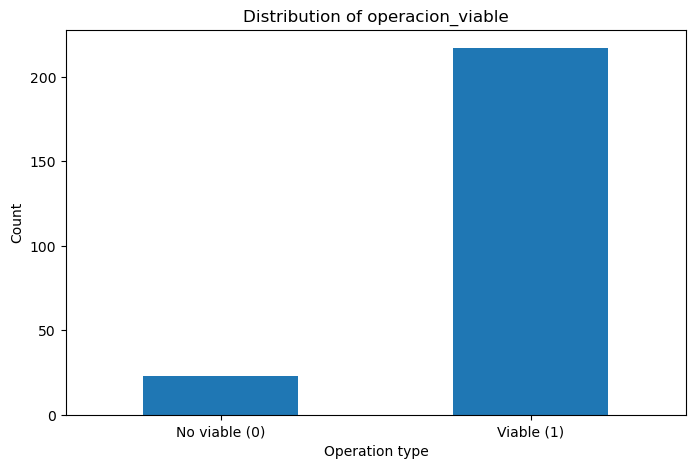

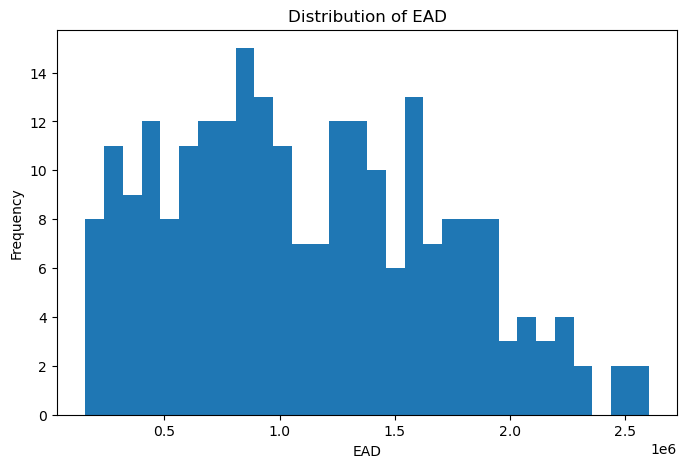

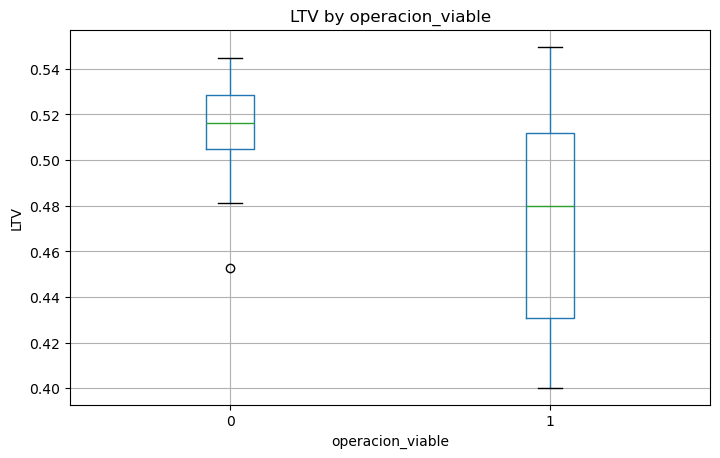

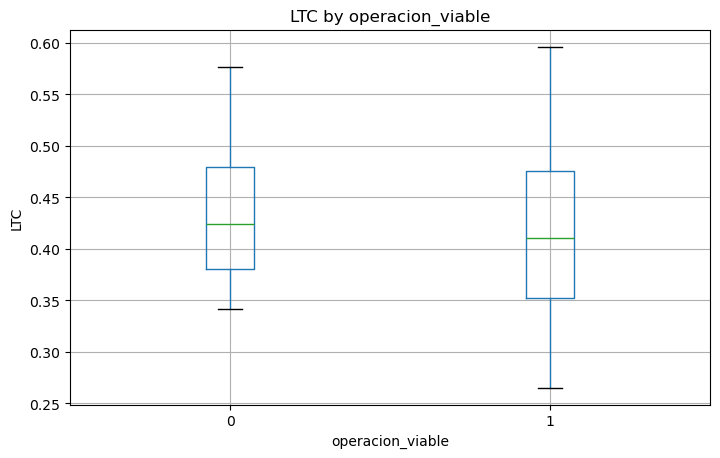

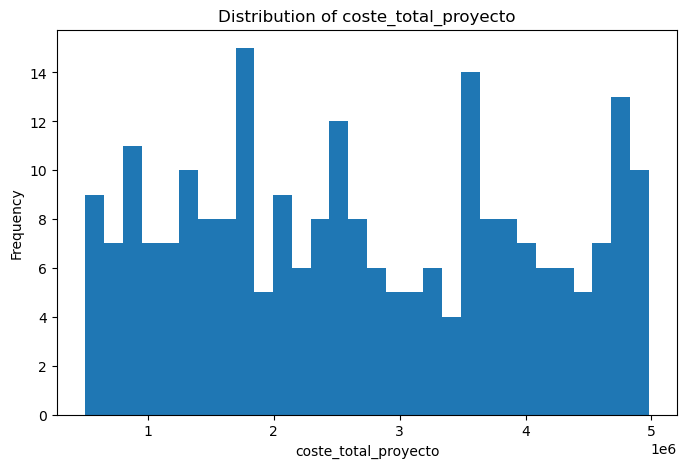

In [46]:
# ============================================================
# BLOCK 43D: Graphical review of key variables
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Visualize key Business Model variables before depuration
#   - Review the target distribution and selected numeric relationships
# DataFrame checked:
#   - business_model_2
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================


# Target distribution
target_counts = business_model_2["operacion_viable"].value_counts().sort_index()
target_counts.index = ["No viable (0)", "Viable (1)"]

plt.figure(figsize=(8, 5))
target_counts.plot(kind="bar")
plt.title("Distribution of operacion_viable")
plt.xlabel("Operation type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# EAD distribution
plt.figure(figsize=(8, 5))
business_model_2["EAD"].plot(kind="hist", bins=30)
plt.title("Distribution of EAD")
plt.xlabel("EAD")
plt.ylabel("Frequency")
plt.show()

# LTV by target
ax = business_model_2.boxplot(
    column="LTV",
    by="operacion_viable",
    figsize=(8, 5)
)
plt.title("LTV by operacion_viable")
plt.suptitle("")
plt.xlabel("operacion_viable")
plt.ylabel("LTV")
plt.show()

# LTC by target
ax = business_model_2.boxplot(
    column="LTC",
    by="operacion_viable",
    figsize=(8, 5)
)
plt.title("LTC by operacion_viable")
plt.suptitle("")
plt.xlabel("operacion_viable")
plt.ylabel("LTC")
plt.show()

# Project cost distribution
plt.figure(figsize=(8, 5))
business_model_2["coste_total_proyecto"].plot(kind="hist", bins=30)
plt.title("Distribution of coste_total_proyecto")
plt.xlabel("coste_total_proyecto")
plt.ylabel("Frequency")
plt.show()

1) The distribution of operacion_viable is imbalanced. Most are viable. Meaning the model could get a high accuracy by assigning most cases as viable, which is not useful if it fails to detect the risky/ non viable operations. got to review  recall, F1, AUC, Cofnusion matrix etc
2) Distribution of EAD is telling me how much money is at risk in the operation. Most operations are concentrated in the middle/lower range, with fewer very large exposures. This could be used for testing viability.
3) LTV by operation_viable: we compare the ltv agaisnt both operacion viable and no viable. Here we are comparing the loan amount compared with the property value. The non-viable group seems to have higher ltv. The viable group has a wider spread, but its middle value is lower. This means that a higher LTV usually means less collateral cushion. So if something goes wrong, the lender has less protection.
4) LTC by operacion_viable: compare the LTC against viable y no viable. this is the loan amount compared with total project cost. The difference between the viable and no viable is weaker than LTV since we can see that the boxes overlap more. LTC may still matter, but visually it does not separate the two groups as clearly as LTV.
5) Distribucion of coste_total_proyecto: meaning how big or expensive the project is. The projects have different sizes. There are more projects in some cost ranges and fewer at the largest project sizes. Important given that financing a smaller project is not the same as financing a larger one. 

In [47]:
# ============================================================
# BLOCK 44: Review missing values
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Identify missing values in Business Model 2
#   - Review whether missing values are expected or require treatment
# DataFrame checked:
#   - business_model_2
# DataFrame created:
#   - missing_summary_business_model_2
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

missing_summary_business_model_2 = (
    business_model_2
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "variable", 0: "missing_values"})
)

missing_summary_business_model_2["missing_pct"] = (
    missing_summary_business_model_2["missing_values"] / len(business_model_2)
).round(4)

missing_summary_business_model_2 = missing_summary_business_model_2.sort_values(
    by="missing_values",
    ascending=False
)

missing_summary_business_model_2[
    missing_summary_business_model_2["missing_values"] > 0
]

,variable,missing_values,missing_pct
11,fecha_ultimo_pago_proxy_RD,76,0.3167
23,Viviendas Siguiente Año,5,0.0208
24,m2 Siguiente Año,5,0.0208


fecha_ultimo_pago_proxy_RD has 76 missing values and requires treatment due to high missingness. Viviendas Siguiente Año and m2 Siguiente Año each have 5 missing values. These variables describe future market activity and may be useful for validation or context, but they should not be used as predictors because they are not available at the initial evaluation moment.

In [48]:
# ============================================================
# BLOCK 45: Review duplicate records
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Check exact duplicate rows and duplicated operation IDs
#   - Confirm whether duplicated records require treatment
# DataFrame checked:
#   - business_model_2
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

duplicate_rows = business_model_2.duplicated().sum()
duplicate_operation_ids = business_model_2["operacion_id_simulada"].duplicated().sum()

print("duplicate rows:", duplicate_rows)
print("Duplicate operacion_id_simulada:", duplicate_operation_ids)

if duplicate_operation_ids > 0:
    display(
        business_model_2[
            business_model_2["operacion_id_simulada"].duplicated(keep=False)
        ].sort_values("operacion_id_simulada")
    )

duplicate rows: 0
Duplicate operacion_id_simulada: 0


No duplicates were identified. Therefore, no duplicate treatment is required. 

In [49]:
# ============================================================
# BLOCK 46: Review negative values in numeric columns
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Check all numeric columns for negative values
#   - Identify which negative values are valid and which may require treatment
# DataFrame checked:
#   - business_model_2
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

numeric_cols = business_model_2.select_dtypes(include=["number"]).columns

negative_values_summary = pd.DataFrame({
    "variable": numeric_cols,
    "negative_values": [
        (business_model_2[col] < 0).sum()
        for col in numeric_cols
    ]
})

negative_values_summary = negative_values_summary[
    negative_values_summary["negative_values"] > 0
].sort_values("negative_values", ascending=False)

negative_values_summary

,variable,negative_values
15,Score Zona (nivel+tendencia-volatilidad),124
12,Crecimiento YoY m2,119
41,desviacion_coste_pct,105
11,Crecimiento YoY Viviendas,93
60,margen_neto_ajustado,23
61,margen_neto_ajustado_pct_ead,23


The review identified negative values in six numeric variables. The highest counts appear in Score Zona (nivel+tendencia-volatilidad) with 124 negative values, Crecimiento YoY m2 with 119, desviacion_coste_pct with 105 and Crecimiento YoY Viviendas with 93. These values are valid because they represent weaker territorial scores, negative market growth or negative cost deviation. The variables margen_neto_ajustado and margen_neto_ajustado_pct_ead each show 23 negative values, which correspond to non-viable operations. Therefore, no treatment is required for these negative values.

,variable,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
10,Crecimiento YoY Viviendas,-0.194588,0.217956,0.412544,-8.134033e-01,8.367714e-01,63,26.25
36,indice_coste_seguimiento,130.400875,135.265375,4.864500,1.231041e+02,1.425621e+02,53,22.08
11,Crecimiento YoY m2,-0.604644,1.252665,1.857310,-3.390609e+00,4.038630e+00,50,20.83
6,total_ultimo_pago_proxy_RD,0.000000,60000.000000,60000.000000,-9.000000e+04,1.500000e+05,48,20.00
3,Valor_RD_proxy,4293.000000,143958.000000,139665.000000,-2.052045e+05,3.534555e+05,42,17.50
5,total_valor_saldado_proxy_RD,0.000000,84000.000000,84000.000000,-1.260000e+05,2.100000e+05,39,16.25
7,Visados Viviendas,85.000000,456.000000,371.000000,-4.715000e+02,1.012500e+03,39,16.25
15,Viviendas Siguiente Año,87.000000,458.000000,371.000000,-4.695000e+02,1.014500e+03,39,16.25
8,Superficie a Construir m2,115584.750000,856060.000000,740475.250000,-9.951281e+05,1.966773e+06,26,10.83
9,m2 por Vivienda,536.839225,3635.452174,3098.612949,-4.111080e+03,8.283372e+03,24,10.00


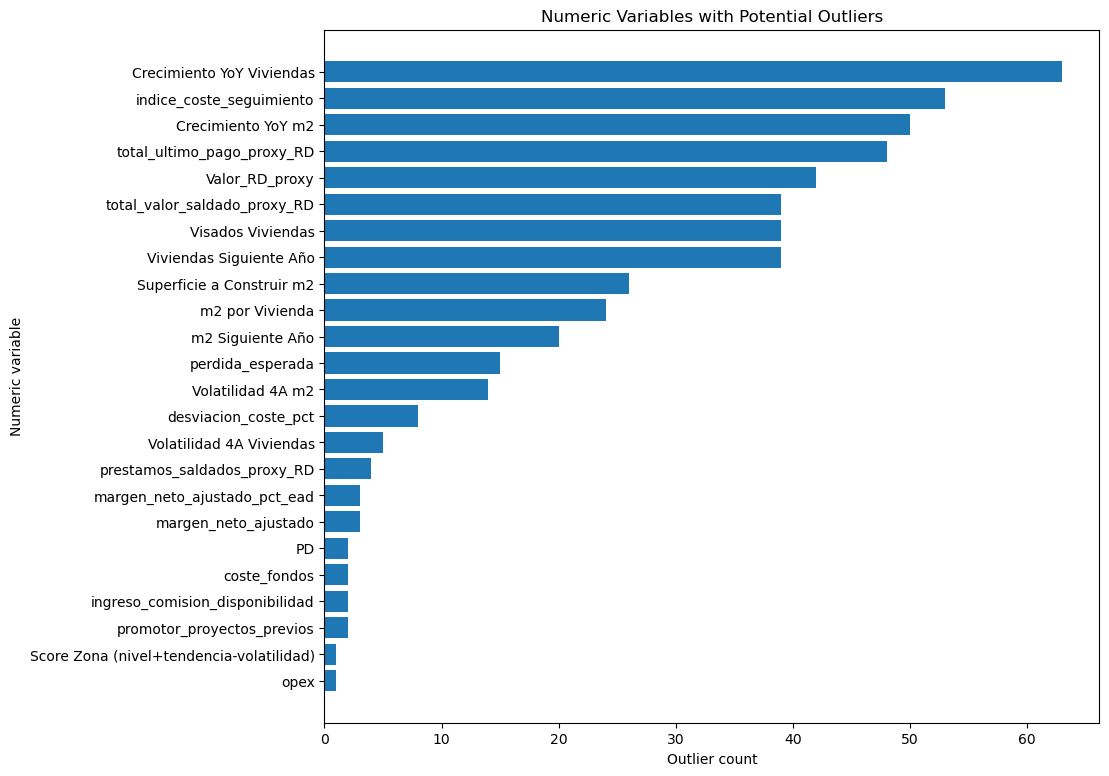

In [50]:
# ============================================================
# BLOCK 47: Review outliers in numeric variables
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Identify potential outliers in continuous numeric variables
#   - Review whether extreme values may require treatment before modeling
# DataFrame checked:
#   - business_model_2
# DataFrame created:
#   - outlier_summary
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - Binary variables are excluded from the outlier review.
#   - Outliers are identified using the IQR method.
# ============================================================


# Identify numeric columns in Business Model 2
numeric_cols = business_model_2.select_dtypes(include=["number"]).columns.tolist()


# Identify binary numeric columns
binary_cols = [
    col for col in numeric_cols
    if business_model_2[col].dropna().nunique() <= 2
]

# Keep numeric variables that are not binary
continuous_numeric_cols = [
    col for col in numeric_cols
    if col not in binary_cols
]


# Calculate potential outliers using the IQR method

outlier_summary = []

for col in continuous_numeric_cols:
    q1 = business_model_2[col].quantile(0.25)
    q3 = business_model_2[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (business_model_2[col] < lower_bound) |
        (business_model_2[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "variable": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_pct": round(outlier_count / len(business_model_2) * 100, 2)
    })

# Convert results into a summary table
outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    by="outlier_count",
    ascending=False
)

# Keep only variables with at least one potential outlier
outlier_summary_filtered = outlier_summary[
    outlier_summary["outlier_count"] > 0
]

display(outlier_summary_filtered)

# Plot all variables with at least one potential outlier
outlier_plot = outlier_summary_filtered.sort_values(
    by="outlier_count",
    ascending=False
)

plt.figure(figsize=(10, 9))
plt.barh(
    outlier_plot["variable"],
    outlier_plot["outlier_count"]
)
plt.title("Numeric Variables with Potential Outliers")
plt.xlabel("Outlier count")
plt.ylabel("Numeric variable")
plt.gca().invert_yaxis()
plt.show()

The IQR review identified 24 numeric variables with potential outliers. The highest counts appear in Crecimiento YoY Viviendas with 63 outliers, indice_coste_seguimiento with 53, Crecimiento YoY m2 with 50 and total_ultimo_pago_proxy_RD with 48. These outliers are not treated automatically because they are not necessarily errors. In the growth variables, they reflect strong changes in provincial construction activity. In the cost index variables, they reflect variation in construction cost conditions. In the RD proxy variables, they reflect differences in the original reference amounts. Future variables and economic-result variables also appear in the review, but they will be evaluated later according to their modeling role.

,variable,unique_categories,missing_values,most_frequent_category,most_frequent_count,most_frequent_pct
0,operacion_id_simulada,240,0,ESP_A_00001,1,0.42
1,proyecto_id_simulado,240,0,PROY_00001,1,0.42
2,promotor_id_simulado,240,0,promotor_00001,1,0.42
12,indice_coste_seguimiento_mes,53,0,2021M11,11,4.58
11,indice_coste_base_mes,50,0,2021M03,11,4.58
4,Nombre_cliente_proxy_RD,44,0,ARISTOFENO MARTINEZ/ELADIO MARTINEZ,18,7.50
6,fecha_ultimo_pago_proxy_RD,30,76,NaT,76,31.67
5,Negocio_proxy_RD,6,0,PERSONAL,204,85.00
3,Provincia,5,0,Alicante,48,20.00
7,tipo_promotor,5,0,cooperativa,56,23.33


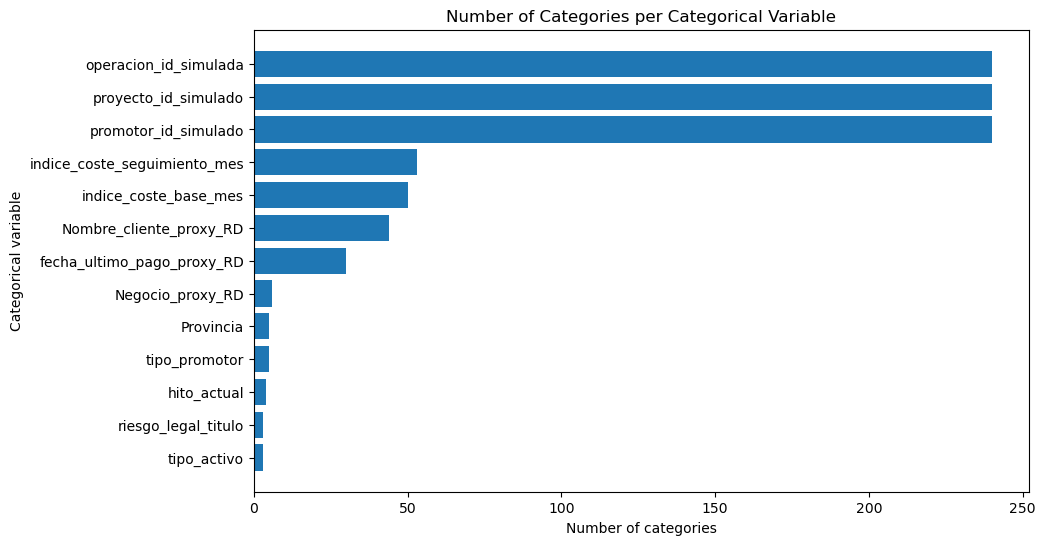

In [51]:
# ============================================================
# BLOCK 48: Review categorical variables and number of categories
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review categorical variables before column treatment
#   - Identify the number of categories in each categorical variable
#   - Detect high-cardinality or traceability variables
# DataFrame checked:
#   - business_model_2
# DataFrame created:
#   - categorical_summary
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - This block is diagnostic only.
#   - Categorical variables are reviewed before dropping, grouping, or encoding.
#   - The review helps identify variables that may be irrelevant, high-cardinality, or useful for dummy encoding.
# ============================================================

# Identify categorical columns
categorical_cols = business_model_2.select_dtypes(include=["object", "category"]).columns.tolist()

# Summarize categorical variables
categorical_summary = []

for col in categorical_cols:
    value_counts = business_model_2[col].value_counts(dropna=False)

    categorical_summary.append({
        "variable": col,
        "unique_categories": business_model_2[col].nunique(dropna=False),
        "missing_values": business_model_2[col].isna().sum(),
        "most_frequent_category": value_counts.index[0],
        "most_frequent_count": value_counts.iloc[0],
        "most_frequent_pct": round(value_counts.iloc[0] / len(business_model_2) * 100, 2)
    })

categorical_summary = pd.DataFrame(categorical_summary).sort_values(
    by="unique_categories",
    ascending=False
)

display(categorical_summary)

# Plot number of categories per categorical variable
categorical_plot = categorical_summary.sort_values(
    by="unique_categories",
    ascending=False
)

plt.figure(figsize=(10, 6))
plt.barh(
    categorical_plot["variable"],
    categorical_plot["unique_categories"]
)
plt.title("Number of Categories per Categorical Variable")
plt.xlabel("Number of categories")
plt.ylabel("Categorical variable")
plt.gca().invert_yaxis()
plt.show()

The categorical review shows that operacion_id_simulada, proyecto_id_simulado and promotor_id_simulado each have 240 unique values, confirming that they function as identifiers rather than predictors. The variables Nombre_cliente_proxy_RD, Negocio_proxy_RD and fecha_ultimo_pago_proxy_RD belong to the RD proxy information and will not be used in the modeling views. The NaT value in fecha_ultimo_pago_proxy_RD reflects missingness, not a meaningful category. The remaining lower-cardinality variables, such as Provincia, tipo_promotor, hito_actual, riesgo_legal_titulo and tipo_activo, are valid categorical candidates for later encoding.

# Depuration

In [52]:
# ============================================================
# BLOCK 49: Treat missing values
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Drop proxy date variable with high missing values
#   - Remove rows with missing future validation values
#   - Confirm that Business Model 2 has no remaining missing values
#   - Review target distribution after missing value treatment
# DataFrame updated:
#   - business_model_2
# Columns dropped:
#   - fecha_ultimo_pago_proxy_RD
# Files created:
#   - None
# Notes / Decision:
#   - fecha_ultimo_pago_proxy_RD is removed because it has a high number of missing values and limited value for the Spain Business Model.
#   - Rows with missing future validation values are removed instead of imputing future information.
# ============================================================

business_model_2 = business_model_2.drop(
    columns=["fecha_ultimo_pago_proxy_RD"],
    errors="ignore"
)

business_model_2 = business_model_2.dropna(
    subset=[
        "Viviendas Siguiente Año",
        "m2 Siguiente Año"
    ]
)

print("Business Model 2 shape after missing value treatment:", business_model_2.shape)
print("Total missing values after treatment:", business_model_2.isna().sum().sum())
print("Target variable available:", "operacion_viable" in business_model_2.columns)

print("\nTarget distribution after missing value treatment:")
display(
    business_model_2["operacion_viable"]
    .value_counts()
    .rename_axis("operacion_viable")
    .reset_index(name="count")
)

Business Model 2 shape after missing value treatment: (235, 75)
Total missing values after treatment: 0
Target variable available: True

Target distribution after missing value treatment:


,operacion_viable,count
0,1,212
1,0,23


business_model_2 now contains 235 rows and 75 columns after missing-value treatment. The treatment removed fecha_ultimo_pago_proxy_RD and the five records with missing future validation values. After this step, the dataset has 0 missing values. The target variable operacion_viable remains available, with 212 viable operations and 23 non-viable. 

In [53]:
# ============================================================
# BLOCK 50: Remove variables not valid for modeling
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Remove variables that should not enter the clean modeling views
#   - Remove identifiers, RD proxy variables, future variables and leakage variables
# DataFrame checked:
#   - hybrid
# DataFrame updated:
#   - business_model_2
# Columns dropped:
#   - id_cols
#   - rd_proxy_cols
#   - future_cols
#   - leakage_cols
# Files created:
#   - None
# Notes / Decision:
#   - hybrid keeps the original full Business Model.
#   - business_model_2 becomes the clean base used to create the origination and monitoring views.
#   - Variables that create fuga de informacion are removed before creating the origination and monitoring views.
# ============================================================

# Identifier variables
id_cols = [
    "operacion_id_simulada",
    "proyecto_id_simulado",
    "promotor_id_simulado"
]

# RD proxy variables
rd_proxy_cols = [
    "Codigo_cliente_proxy_RD",
    "No_Prestamo_proxy_RD",
    "Nombre_cliente_proxy_RD",
    "Negocio_proxy_RD",
    "Valor_RD_proxy",
    "prestamos_saldados_proxy_RD",
    "total_valor_saldado_proxy_RD",
    "total_ultimo_pago_proxy_RD",
    "ha_saldado_antes_proxy_RD"
]

# Future validation variables
future_cols = [
    "Viviendas Siguiente Año",
    "m2 Siguiente Año",
    "Zona Buena Top2 Siguiente Año",
    "Zona Buena Above Median Siguiente Año"
]

# Economic result and leakage variables
leakage_cols = [
    "margen_neto_ajustado",
    "margen_neto_ajustado_pct_ead",
    "ingresos_totales",
    "ingreso_intereses_anual",
    "ingreso_comisiones_totales",
    "ingreso_comision_apertura",
    "ingreso_comision_disponibilidad",
    "coste_fondos",
    "coste_fondos_pct",
    "opex",
    "opex_pct_ead",
    "perdida_esperada",
    "PD",
    "LGD",
    "tipo_nominal_anual",
    "comision_apertura_pct",
    "comision_disponibilidad_pct",
    "pricing_score",
    "EAD",
    "ead_por_ltv",
    "ead_por_ltc",
    "importe_dispuesto",
    "importe_comprometido",
    "importe_no_dispuesto",
]

excluded_predictive_cols = (
    id_cols +
    rd_proxy_cols +
    future_cols +
    leakage_cols
)

business_model_2 = business_model_2.drop(
    columns=excluded_predictive_cols,
    errors="ignore"
).copy()

print("Original full Business Model:", hybrid.shape)
print("Business Model 2 clean:", business_model_2.shape)
print("Excluded columns from modeling:", len(excluded_predictive_cols))
print("Total missing values in Business Model 2:", business_model_2.isna().sum().sum())
print("Target variable available:", "operacion_viable" in business_model_2.columns)

Original full Business Model: (240, 76)
Business Model 2 clean: (235, 35)
Excluded columns from modeling: 40
Total missing values in Business Model 2: 0
Target variable available: True


business_model_2 was further depurated by removing variables that should not be used for modeling, including identifiers, RD proxy fields, future variables, economic result variables and direct or indirect components of operacion_viable. The purpose of this step is to avoid using variables that already contain the answer or that would not be available at the moment of evaluation. After this exclusion, business_model_2 contains 235 records and 35 variables, with no missing values and with the target variable still available. This depurated dataset is used as the base for two different modeling views: origination_view and monitoring_view.

# Origination view 

In [54]:
# ============================================================
# BLOCK 51: Build origination view
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Build the origination view for the initial approval moment
#   - Keep the target variable for supervised classification
# DataFrame checked:
#   - business_model_2
# DataFrame created:
#   - origination_view
#   - origination_view_columns
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - origination_view includes only variables available at the initial evaluation moment.
#   - The target variable operacion_viable is kept for supervised classification.
# ============================================================

target_col = "operacion_viable"

origination_predictor_cols = [
    # Public market variables available at origination
    "Provincia",
    "Año_originacion",
    "Visados Viviendas",
    "Superficie a Construir m2",
    "m2 por Vivienda",
    "Crecimiento YoY Viviendas",
    "Crecimiento YoY m2",
    "Volatilidad 4A Viviendas",
    "Volatilidad 4A m2",
    "Score Zona (nivel+tendencia-volatilidad)",

    # Promotor and project profile variables available at origination
    "tipo_promotor",
    "promotor_experiencia_anios",
    "promotor_proyectos_previos",
    "equity_promotor_pct",
    "deuda_existente_promotor_pct",
    "documentacion_completa",
    "riesgo_legal_titulo",
    "tipo_activo",

    # Financial structure variables available at origination
    "coste_total_proyecto",
    "valor_tasacion_as_is",
    "LTV",
    "LTC",
    "porcentaje_preventas",

    # Base cost index variables available at origination
    "indice_coste_base_mes",
    "indice_coste_base"
]

origination_view = business_model_2[
    origination_predictor_cols + [target_col]
].copy()

origination_view_columns = pd.DataFrame({
    "view": "origination_view",
    "variable": origination_view.columns,
    "role": [
        "target" if col == target_col else "origination_predictor"
        for col in origination_view.columns
    ]
})

print("Business Model 2 shape:", business_model_2.shape)
print("Origination view shape:", origination_view.shape)
print("Origination predictors:", len(origination_predictor_cols))
print("Target variable available:", target_col in origination_view.columns)

display(origination_view_columns)

Business Model 2 shape: (235, 35)
Origination view shape: (235, 26)
Origination predictors: 25
Target variable available: True


,view,variable,role
0,origination_view,Provincia,origination_predictor
1,origination_view,Año_originacion,origination_predictor
2,origination_view,Visados Viviendas,origination_predictor
3,origination_view,Superficie a Construir m2,origination_predictor
4,origination_view,m2 por Vivienda,origination_predictor
5,origination_view,Crecimiento YoY Viviendas,origination_predictor
6,origination_view,Crecimiento YoY m2,origination_predictor
7,origination_view,Volatilidad 4A Viviendas,origination_predictor
8,origination_view,Volatilidad 4A m2,origination_predictor
9,origination_view,Score Zona (nivel+tendencia-volatilidad),origination_predictor


origination_view represents the information available at the initial evaluation moment, before the operation is approved and before project monitoring information is observed. Its purpose is to evaluate how well the model can identify the synthetic target operacion_viable using only the variables that would reasonably be known at origination. The view contains 235 records, 25 predictors and the target variable

# Monitoring view

In [55]:
# ============================================================
# BLOCK 52: Build monitoring view
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Build the view for the monitoring moment
#   - Explicitly list all variables included in monitoring_view
#   - Keep the target variable for supervised classification
# DataFrame checked:
#   - business_model_2
# DataFrame created:
#   - monitoring_view
#   - monitoring_view_columns
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - monitoring_view is created from the depurated business_model_2.
#   - It includes all origination predictors.
#   - It also includes variables observed during project monitoring.
# ============================================================

monitoring_predictor_cols = [
    # Origination predictors
    "Provincia",
    "Año_originacion",
    "Visados Viviendas",
    "Superficie a Construir m2",
    "m2 por Vivienda",
    "Crecimiento YoY Viviendas",
    "Crecimiento YoY m2",
    "Volatilidad 4A Viviendas",
    "Volatilidad 4A m2",
    "Score Zona (nivel+tendencia-volatilidad)",

    "tipo_promotor",
    "promotor_experiencia_anios",
    "promotor_proyectos_previos",
    "equity_promotor_pct",
    "deuda_existente_promotor_pct",
    "documentacion_completa",
    "riesgo_legal_titulo",
    "tipo_activo",

    "coste_total_proyecto",
    "valor_tasacion_as_is",
    "LTV",
    "LTC",
    "porcentaje_preventas",

    "indice_coste_base_mes",
    "indice_coste_base",

    # Monitoring predictors
    "hito_actual",
    "retraso_obra_meses",
    "indice_coste_seguimiento_mes",
    "indice_coste_seguimiento",
    "desviacion_coste_pct",
    "evidencia_hito",
    "stop_desembolsos"
]

monitoring_view = business_model_2[
    monitoring_predictor_cols + [target_col]
].copy()

monitoring_view_columns = pd.DataFrame({
    "view": "monitoring_view",
    "variable": monitoring_view.columns,
    "role": [
        "target" if col == target_col
        else "monitoring_predictor" if col in [
            "hito_actual",
            "retraso_obra_meses",
            "indice_coste_seguimiento_mes",
            "indice_coste_seguimiento",
            "desviacion_coste_pct",
            "evidencia_hito",
            "stop_desembolsos"
        ]
        else "origination_predictor"
        for col in monitoring_view.columns
    ]
})

print("Business Model 2 shape:", business_model_2.shape)
print("Monitoring view shape:", monitoring_view.shape)
print("Monitoring predictors:", len(monitoring_predictor_cols))
print("Target variable available:", target_col in monitoring_view.columns)

display(monitoring_view_columns)

Business Model 2 shape: (235, 35)
Monitoring view shape: (235, 33)
Monitoring predictors: 32
Target variable available: True


,view,variable,role
0,monitoring_view,Provincia,origination_predictor
1,monitoring_view,Año_originacion,origination_predictor
2,monitoring_view,Visados Viviendas,origination_predictor
3,monitoring_view,Superficie a Construir m2,origination_predictor
4,monitoring_view,m2 por Vivienda,origination_predictor
5,monitoring_view,Crecimiento YoY Viviendas,origination_predictor
6,monitoring_view,Crecimiento YoY m2,origination_predictor
7,monitoring_view,Volatilidad 4A Viviendas,origination_predictor
8,monitoring_view,Volatilidad 4A m2,origination_predictor
9,monitoring_view,Score Zona (nivel+tendencia-volatilidad),origination_predictor


monitoring_view represents a later evaluation moment, when the operation has already been approved and project follow-up information is available. This view is not a substitute for origination_view; it reflects a different decision moment. Its purpose is to evaluate whether an active operation still fits the synthetic viability logic of the Business Model once monitoring variables such as delays, cost deviations, milestone evidence and disbursement controls are observed. The view contains 235 records, 32 predictors, and the target variable

In [56]:
# ============================================================
# BLOCK 53: Define display helper for side by side tables
# ============================================================
from IPython.display import display_html

def display_side_by_side(left_df, right_df, left_title, right_title):
    left_html = left_df.to_html(index=False)
    right_html = right_df.to_html(index=False)

    display_html(
        f"""
        <div style="display: flex; gap: 30px; align-items: flex-start;">
            <div>
                <h4>{left_title}</h4>
                {left_html}
            </div>
            <div>
                <h4>{right_title}</h4>
                {right_html}
            </div>
        </div>
        """,
        raw=True
    )

In [57]:
# ============================================================
# BLOCK 54: Review target balance in modeling views
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review the distribution of the synthetic target in each modeling view
#   - Confirm whether origination_view and monitoring_view have the same target balance
#   - Identify class imbalance before model training and evaluation
# DataFrame created / checked / updated:
#   - origination_view checked
#   - monitoring_view checked
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - The same target variable is used in both views
#   - Class imbalance must be considered when evaluating classification models
# ============================================================


target_col = "operacion_viable"

target_label_map = {
    0: "Non viable",
    1: "Viable"
}

view_dict = {
    "origination_view": origination_view,
    "monitoring_view": monitoring_view
}

target_balance_rows = []

for view_name, view_df in view_dict.items():
    
    for target_value, target_label in target_label_map.items():
        count = (view_df[target_col] == target_value).sum()
        percentage = count / len(view_df) * 100
        
        target_balance_rows.append({
            "view": view_name,
            "target_label": target_label,
            "count": count,
            "percentage": round(percentage, 2)
        })

target_balance_views = pd.DataFrame(target_balance_rows)

origination_target_balance = target_balance_views[
    target_balance_views["view"] == "origination_view"
].drop(columns=["view"]).reset_index(drop=True)

monitoring_target_balance = target_balance_views[
    target_balance_views["view"] == "monitoring_view"
].drop(columns=["view"]).reset_index(drop=True)

display_side_by_side(
    origination_target_balance,
    monitoring_target_balance,
    "Origination view",
    "Monitoring view"
)

view_structure_rows = []

for view_name, view_df in view_dict.items():
    view_structure_rows.append({
        "view": view_name,
        "records": len(view_df),
        "total_columns": view_df.shape[1],
        "predictors": view_df.shape[1] - 1
    })

view_structure_summary = pd.DataFrame(view_structure_rows)

display(view_structure_summary)

print(
    "Same target distribution:",
    origination_view[target_col].value_counts().sort_index().equals(
        monitoring_view[target_col].value_counts().sort_index()
    )
)

target_label,count,percentage
Non viable,23,9.79
Viable,212,90.21
target_label,count,percentage
Non viable,23,9.79
Viable,212,90.21


,view,records,total_columns,predictors
0,origination_view,235,26,25
1,monitoring_view,235,33,32


Same target distribution: True


The target balance review confirms that both origination_view and monitoring_view preserve the same target distribution. This is expected because both views are built from the same 235 operations in business_model_2; the difference between them is the number and type of predictos, not the target definition. In both views, viable operations represent 90.21% of the data, while non-viable operations represent 9.79%. This confirms the presence of class imbalance; that said, the best approach is not just to focus on accuracy but also to review the confusion matrix, precision, recall, F1 score, and ROC AUC or PR AUC. Stress testing will be incorporated before closing the predictive section to assess whether the viability rule generates too many viable operations and whether the models learn patterns beyond the majority class. 

predictor_type,count,percentage
Numeric,20,80.0
Categorical,5,20.0
Total predictors,25,100.0
predictor_type,count,percentage
Numeric,25,78.12
Categorical,7,21.88
Total predictors,32,100.00


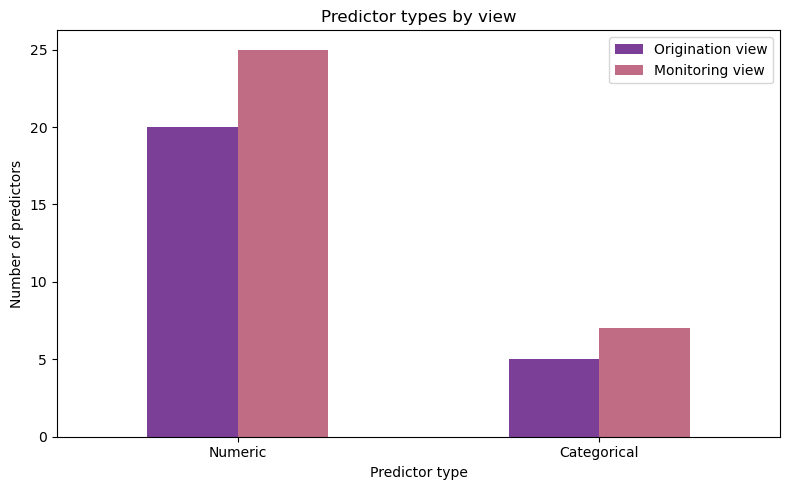

In [58]:
# ============================================================
# BLOCK 55: Review predictor types in modeling views
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review numeric and categorical predictors in each modeling view
#   - Confirm which predictor groups require encoding before model training
#   - Keep the modeling view preparation organized before classification
# DataFrame created / checked / updated:
#   - origination_view checked
#   - monitoring_view checked
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - Categorical predictors require additional review before encoding
#   - Numeric predictors can be used directly or scaled depending on the model
# ============================================================


target_col = "operacion_viable"

view_dict = {
    "origination_view": origination_view,
    "monitoring_view": monitoring_view
}

predictor_type_rows = []

for view_name, view_df in view_dict.items():
    
    predictors = view_df.drop(columns=[target_col])
    
    numeric_predictors = predictors.select_dtypes(include=["number"]).columns.tolist()
    categorical_predictors = predictors.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    total_predictors = predictors.shape[1]
    
    predictor_type_rows.append({
        "view": view_name,
        "predictor_type": "Numeric",
        "count": len(numeric_predictors),
        "percentage": round(len(numeric_predictors) / total_predictors * 100, 2)
    })
    
    predictor_type_rows.append({
        "view": view_name,
        "predictor_type": "Categorical",
        "count": len(categorical_predictors),
        "percentage": round(len(categorical_predictors) / total_predictors * 100, 2)
    })
    
    predictor_type_rows.append({
        "view": view_name,
        "predictor_type": "Total predictors",
        "count": total_predictors,
        "percentage": 100.00
    })

predictor_type_summary = pd.DataFrame(predictor_type_rows)

origination_predictor_types = predictor_type_summary[
    predictor_type_summary["view"] == "origination_view"
].drop(columns=["view"]).reset_index(drop=True)

monitoring_predictor_types = predictor_type_summary[
    predictor_type_summary["view"] == "monitoring_view"
].drop(columns=["view"]).reset_index(drop=True)

display_side_by_side(
    origination_predictor_types,
    monitoring_predictor_types,
    "Origination view predictor types",
    "Monitoring view predictor types"
)

plot_data = predictor_type_summary[
    predictor_type_summary["predictor_type"].isin(["Numeric", "Categorical"])
].pivot(
    index="predictor_type",
    columns="view",
    values="count"
)

plot_data = plot_data.loc[["Numeric", "Categorical"]]

ax = plot_data[["origination_view", "monitoring_view"]].plot(
    kind="bar",
    figsize=(8, 5),
    color=["#7B3F98", "#C06C84"]
)

plt.title("Predictor types by view")
plt.xlabel("Predictor type")
plt.ylabel("Number of predictors")
plt.xticks(rotation=0)
ax.legend(["Origination view", "Monitoring view"])
plt.tight_layout()
plt.show()

Both modeling views are mainly composed of numeric variables. origination_view contains 25 predictors, with 20 numeric predictors and 5 categorical predictors, while monitoring_view contains 32 predictors, with 25 numeric predictors and 7 categorical predictors. This confirms that the monitoring view incorporates additional follow-up information while preserving a similar overall structure. The result is important because categorical predictors cannot be used directly by most classification models and must be reviewed before encoding. This review is specifically relevant in a small dataset of 235 observations because categorical variables with many unique values can create too many dummy variables, increasing model complexity and the risk of overfitting(sobreajuste). Therefore, the next step is to review categorical cardinality.

categorical_variable,unique_categories
indice_coste_base_mes,50
Provincia,5
tipo_promotor,5
riesgo_legal_titulo,3
tipo_activo,3
categorical_variable,unique_categories
indice_coste_seguimiento_mes,53
indice_coste_base_mes,50
Provincia,5
tipo_promotor,5


categorical_variable,unique_categories
indice_coste_base_mes,50
categorical_variable,unique_categories
indice_coste_seguimiento_mes,53
indice_coste_base_mes,50


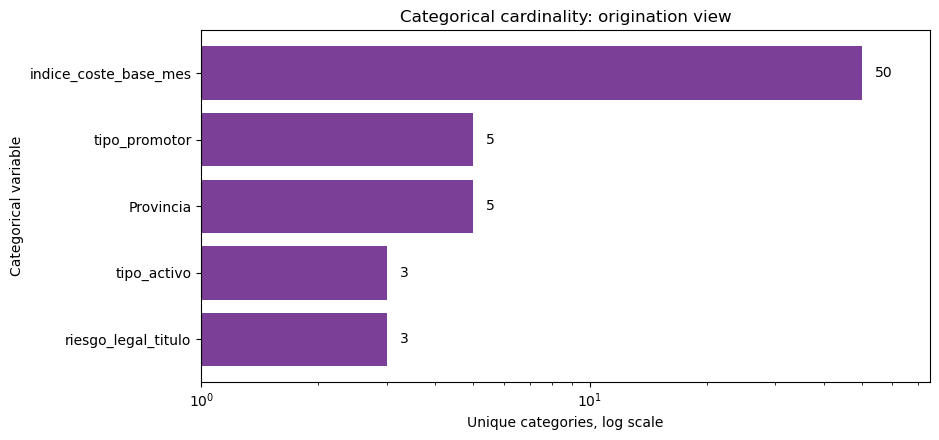

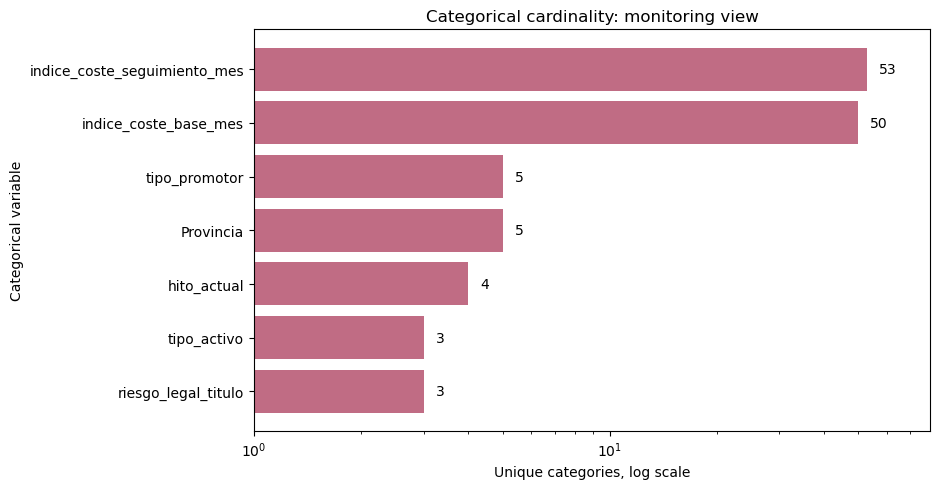

In [59]:
# ============================================================
# BLOCK 56: Review categorical cardinality in modeling views
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review the number of unique categories in each categorical predictor
#   - Identify categorical variables that may create too many dummy variables
#   - Support encoding decisions before preparing model ready datasets
# DataFrame created / checked / updated:
#   - origination_view checked
#   - monitoring_view checked
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - Low cardinality variables can usually be encoded with dummy variables
#   - High cardinality variables should be reviewed carefully to reduce model complexity
# ============================================================


target_col = "operacion_viable"

view_dict = {
    "origination_view": origination_view,
    "monitoring_view": monitoring_view
}

cardinality_rows = []

for view_name, view_df in view_dict.items():
    
    predictors = view_df.drop(columns=[target_col])
    categorical_predictors = predictors.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    
    for col in categorical_predictors:
        unique_count = view_df[col].nunique()
        
        cardinality_rows.append({
            "view": view_name,
            "categorical_variable": col,
            "unique_categories": unique_count
        })

categorical_cardinality = pd.DataFrame(cardinality_rows)

origination_cardinality = categorical_cardinality[
    categorical_cardinality["view"] == "origination_view"
].drop(columns=["view"]).copy().sort_values(
    by="unique_categories",
    ascending=False
).reset_index(drop=True)

monitoring_cardinality = categorical_cardinality[
    categorical_cardinality["view"] == "monitoring_view"
].drop(columns=["view"]).copy().sort_values(
    by="unique_categories",
    ascending=False
).reset_index(drop=True)

display_side_by_side(
    origination_cardinality,
    monitoring_cardinality,
    "Origination view categorical cardinality",
    "Monitoring view categorical cardinality"
)
high_cardinality_limit = 10

origination_high_cardinality = origination_cardinality[
    origination_cardinality["unique_categories"] > high_cardinality_limit
].reset_index(drop=True)

monitoring_high_cardinality = monitoring_cardinality[
    monitoring_cardinality["unique_categories"] > high_cardinality_limit
].reset_index(drop=True)

display_side_by_side(
    origination_high_cardinality,
    monitoring_high_cardinality,
    "Origination view high-cardinality variables",
    "Monitoring view high-cardinality variables"
)
origination_plot = origination_cardinality.sort_values(
    by="unique_categories",
    ascending=True
)

monitoring_plot = monitoring_cardinality.sort_values(
    by="unique_categories",
    ascending=True
)

plt.figure(figsize=(9.5, 4.5))
bars = plt.barh(
    origination_plot["categorical_variable"],
    origination_plot["unique_categories"],
    color="#7B3F98"
)

plt.title("Categorical cardinality: origination view")
plt.xlabel("Unique categories, log scale")
plt.ylabel("Categorical variable")
plt.xscale("log")
plt.xlim(1, origination_plot["unique_categories"].max() * 1.5)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width * 1.08,
        bar.get_y() + bar.get_height() / 2,
        int(width),
        va="center"
    )

plt.tight_layout()
plt.show()

plt.figure(figsize=(9.5, 5))
bars = plt.barh(
    monitoring_plot["categorical_variable"],
    monitoring_plot["unique_categories"],
    color="#C06C84"
)

plt.title("Categorical cardinality: monitoring view")
plt.xlabel("Unique categories, log scale")
plt.ylabel("Categorical variable")
plt.xscale("log")
plt.xlim(1, monitoring_plot["unique_categories"].max() * 1.5)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width * 1.08,
        bar.get_y() + bar.get_height() / 2,
        int(width),
        va="center"
    )

plt.tight_layout()
plt.show()

The categorical cardinality review identifies how many unique categories exist in each categorical predictor before encoding. This step is important because categorical variables with many unique values can create a large number of dummy variables, increasing model complexity in a dataset of 235 observations.

In origination_view, most categorical predictors have low cardinality. Provincia and tipo_promotor contain 5 categories, while riesgo_legal_titulo and tipo_activo contain 3 categories. The exception is indice_coste_base_mes, which contains 50 unique categories and therefore represents a high-cardinality variable.

In monitoring_view, the same low-cardinality variables are present, with the additional monitoring variable hito_actual, which contains 4 categories. However, this view also includes two high-cardinality variables: indice_coste_seguimiento_mes, with 53 unique categories, and indice_coste_base_mes, with 50 unique categories.

Overall, the results suggest that the low-cardinality categorical predictors can continue to the category distribution review, while the month-label variables should be reviewed carefully before encoding

categorical_variable,top_category,top_category_count,top_category_percentage,rare_categories_count
riesgo_legal_titulo,bajo,164,69.79,0
tipo_activo,obra_nueva,126,53.62,0
tipo_promotor,cooperativa,55,23.40,0
Provincia,Alicante,47,20.00,0
indice_coste_base_mes,2021M03,11,4.68,34
categorical_variable,top_category,top_category_count,top_category_percentage,rare_categories_count
riesgo_legal_titulo,bajo,164,69.79,0
tipo_activo,obra_nueva,126,53.62,0
hito_actual,inicio_obra,85,36.17,0
tipo_promotor,cooperativa,55,23.40,0


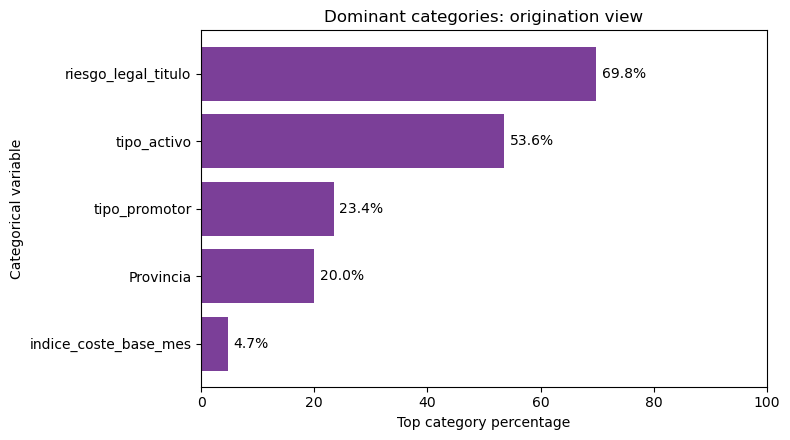

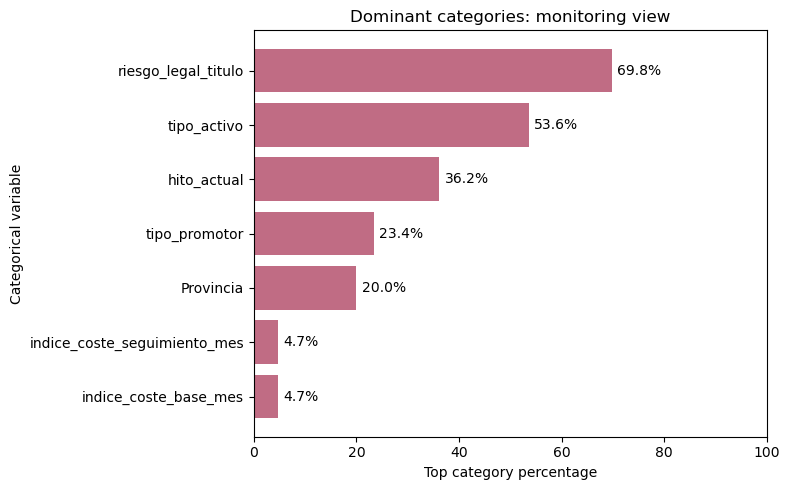

In [60]:
# ============================================================
# BLOCK 57: Review categorical distribution in modeling views
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review the distribution of categories within each categorical predictor
#   - Identify dominant categories and rare categories before encoding
#   - Support encoding and grouping decisions
# DataFrame created / checked / updated:
#   - origination_view checked
#   - monitoring_view checked
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - Category distribution is reviewed after cardinality
#   - Variables with dominant or rare categories should be reviewed before encoding
# ============================================================


target_col = "operacion_viable"

view_dict = {
    "origination_view": origination_view,
    "monitoring_view": monitoring_view
}

category_distribution_rows = []

for view_name, view_df in view_dict.items():
    
    predictors = view_df.drop(columns=[target_col])
    categorical_predictors = predictors.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    
    for col in categorical_predictors:
        
        counts = view_df[col].value_counts(dropna=False)
        percentages = view_df[col].value_counts(normalize=True, dropna=False) * 100
        
        top_category = counts.index[0]
        top_count = counts.iloc[0]
        top_percentage = percentages.iloc[0]
        rare_categories = (counts <= 5).sum()
        
        category_distribution_rows.append({
            "view": view_name,
            "categorical_variable": col,
            "top_category": str(top_category),
            "top_category_count": top_count,
            "top_category_percentage": round(top_percentage, 2),
            "rare_categories_count": rare_categories
        })

categorical_distribution_summary = pd.DataFrame(category_distribution_rows)

origination_categorical_distribution = categorical_distribution_summary[
    categorical_distribution_summary["view"] == "origination_view"
].drop(columns=["view"]).copy().sort_values(
    by="top_category_percentage",
    ascending=False
).reset_index(drop=True)

monitoring_categorical_distribution = categorical_distribution_summary[
    categorical_distribution_summary["view"] == "monitoring_view"
].drop(columns=["view"]).copy().sort_values(
    by="top_category_percentage",
    ascending=False
).reset_index(drop=True)

display_side_by_side(
    origination_categorical_distribution,
    monitoring_categorical_distribution,
    "Origination view categorical distribution",
    "Monitoring view categorical distribution"
)

origination_plot = origination_categorical_distribution.sort_values(
    by="top_category_percentage",
    ascending=True
)

monitoring_plot = monitoring_categorical_distribution.sort_values(
    by="top_category_percentage",
    ascending=True
)

plt.figure(figsize=(8, 4.5))
bars = plt.barh(
    origination_plot["categorical_variable"],
    origination_plot["top_category_percentage"],
    color="#7B3F98"
)

plt.title("Dominant categories: origination view")
plt.xlabel("Top category percentage")
plt.ylabel("Categorical variable")
plt.xlim(0, 100)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
bars = plt.barh(
    monitoring_plot["categorical_variable"],
    monitoring_plot["top_category_percentage"],
    color="#C06C84"
)

plt.title("Dominant categories: monitoring view")
plt.xlabel("Top category percentage")
plt.ylabel("Categorical variable")
plt.xlim(0, 100)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

The categorical distribution review evaluates how concentrated each categorical predictor is before encoding. The results show that the main business categorical variables do not present rare category problems. Provincia, tipo_promotor, riesgo_legal_titulo, tipo_activo, and hito_actual all have a rare_categories_count of 0, meaning that none of their categories appear in five observations or fewer. This supports keeping these variables as candidates for later encoding. However, the month label variables show a different pattern. indice_coste_base_mes has 34 rare categories and indice_coste_seguimiento_mes has 40 rare categories. This confirms that these variables are highly fragmented across specific year month labels. Since the cost information is already captured in numeric form through indice_coste_base, indice_coste_seguimiento, and desviacion_coste_pct, the month label variables should be excluded before creating the final model.

In [61]:
# ============================================================
# BLOCK 58: Remove high-cardinality month-label variables before encoding
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Exclude high-cardinality month-label variables from the modeling views
#   - Update the predictor lists and modeling view documentation
#   - Confirm categorical cardinality after the exclusion
# DataFrame created / checked / updated:
#   - origination_view updated
#   - monitoring_view updated
#   - origination_view_columns updated
#   - monitoring_view_columns updated
#   - categorical_cardinality updated
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - Month-label variables remain in business_model_2 for traceability
#   - Only indice_coste_base_mes and indice_coste_seguimiento_mes are excluded
#   - Numeric cost variables remain in the relevant modeling views
# ============================================================

target_col = "operacion_viable"

origination_predictor_cols = [
    col for col in origination_predictor_cols
    if col != "indice_coste_base_mes"
]

monitoring_predictor_cols = [
    col for col in monitoring_predictor_cols
    if col not in [
        "indice_coste_base_mes",
        "indice_coste_seguimiento_mes"
    ]
]

origination_view = business_model_2[
    origination_predictor_cols + [target_col]
].copy()

monitoring_view = business_model_2[
    monitoring_predictor_cols + [target_col]
].copy()

origination_view_columns = pd.DataFrame({
    "view": "origination_view",
    "variable": origination_view.columns,
    "role": [
        "target" if col == target_col else "origination_predictor"
        for col in origination_view.columns
    ]
})

monitoring_only_predictors = [
    "hito_actual",
    "retraso_obra_meses",
    "indice_coste_seguimiento",
    "desviacion_coste_pct",
    "evidencia_hito",
    "stop_desembolsos"
]

monitoring_view_columns = pd.DataFrame({
    "view": "monitoring_view",
    "variable": monitoring_view.columns,
    "role": [
        "target" if col == target_col
        else "monitoring_predictor" if col in monitoring_only_predictors
        else "origination_predictor"
        for col in monitoring_view.columns
    ]
})

view_dict = {
    "origination_view": origination_view,
    "monitoring_view": monitoring_view
}

cardinality_rows = []

for view_name, view_df in view_dict.items():

    predictors = view_df.drop(columns=[target_col])

    categorical_predictors = predictors.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()

    for col in categorical_predictors:

        unique_count = view_df[col].nunique()

        cardinality_rows.append({
            "view": view_name,
            "categorical_variable": col,
            "unique_categories": unique_count
        })

categorical_cardinality = pd.DataFrame(cardinality_rows)

origination_cardinality = categorical_cardinality[
    categorical_cardinality["view"] == "origination_view"
].drop(columns=["view"]).copy().sort_values(
    by="unique_categories",
    ascending=False
).reset_index(drop=True)

monitoring_cardinality = categorical_cardinality[
    categorical_cardinality["view"] == "monitoring_view"
].drop(columns=["view"]).copy().sort_values(
    by="unique_categories",
    ascending=False
).reset_index(drop=True)

origination_html = origination_cardinality.to_html(index=False)
monitoring_html = monitoring_cardinality.to_html(index=False)

display_html(
    f"""
    <div style="display: flex; gap: 30px; align-items: flex-start;">
        <div>
            <h4 style="color: #7B3F98;">
                Origination view categorical cardinality
            </h4>
            {origination_html}
        </div>
        <div>
            <h4 style="color: #C06C84;">
                Monitoring view categorical cardinality
            </h4>
            {monitoring_html}
        </div>
    </div>
    """,
    raw=True
)

categorical_variable,unique_categories
Provincia,5
tipo_promotor,5
riesgo_legal_titulo,3
tipo_activo,3
categorical_variable,unique_categories
Provincia,5
tipo_promotor,5
hito_actual,4
riesgo_legal_titulo,3
tipo_activo,3


After excluding indice_coste_base_mes and indice_coste_seguimiento_mes, all remaining categorical predictors have low cardinality, ranging from three to five categories. No additional categorical variables require exclusion or grouping before encoding. 

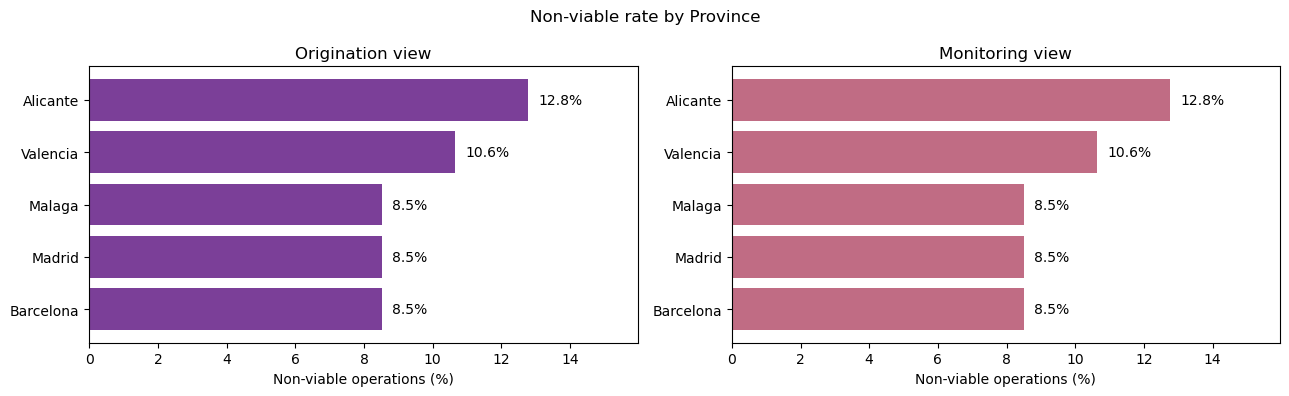

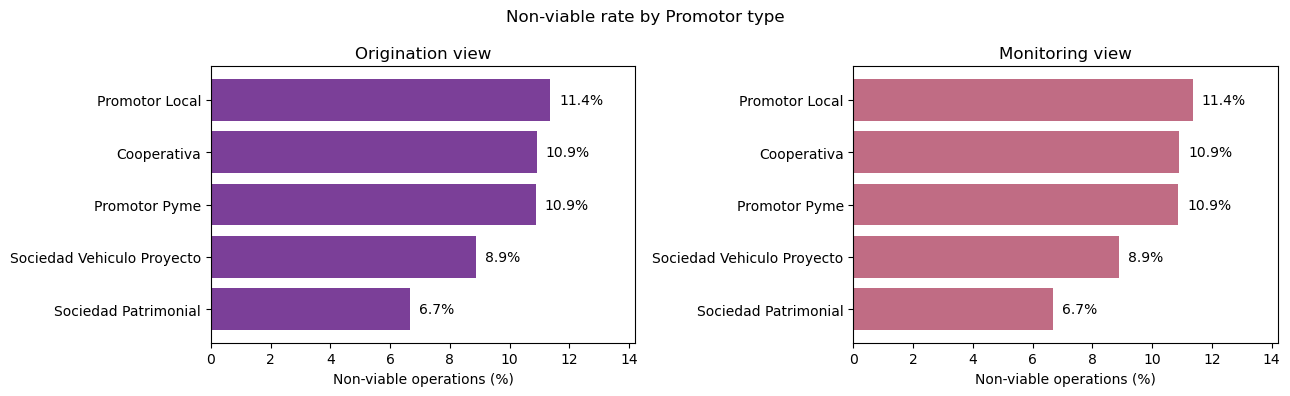

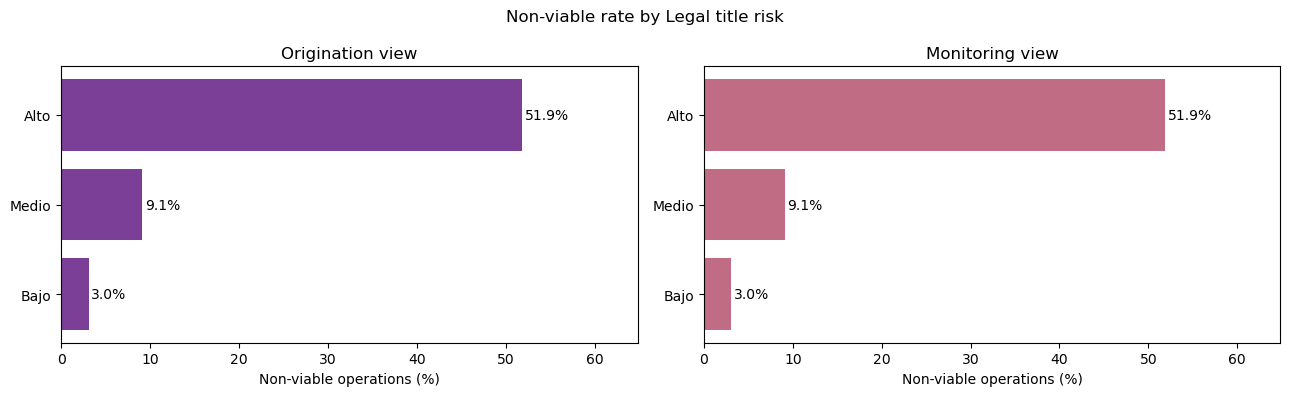

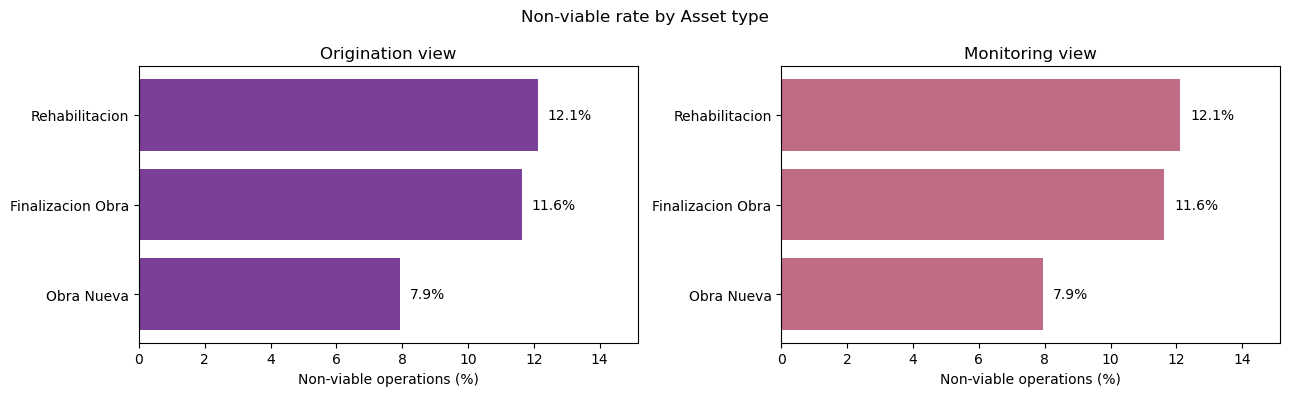

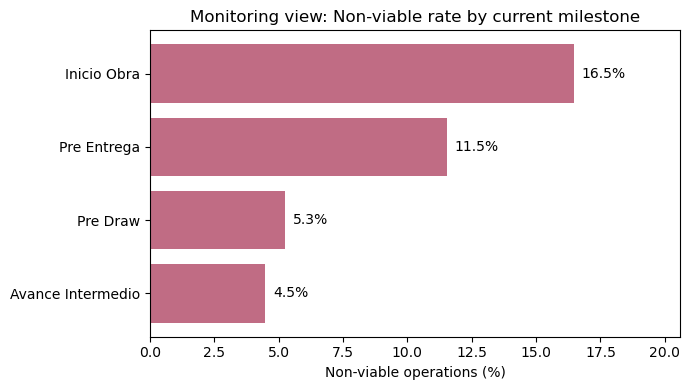

In [62]:
# ============================================================
# BLOCK 59: Analyze categorical predictors against the target
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Compare non-viable rates across categorical predictors
#   - Analyze origination_view and monitoring_view separately
#   - Display shared predictors side by side for comparison
# DataFrame created / checked / updated:
#   - origination_categorical_viability_summary
#   - monitoring_categorical_viability_summary
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - Both modeling views remain separate
#   - Shared predictors use the same category order and scale
#   - hito_actual is only analyzed in monitoring_view
#   - No predictors are removed in this block
# ============================================================

origination_categorical_predictors = [
    "Provincia",
    "tipo_promotor",
    "riesgo_legal_titulo",
    "tipo_activo"
]
monitoring_categorical_predictors = (
    origination_categorical_predictors + ["hito_actual"]
)
variable_titles = {
    "Provincia": "Province",
    "tipo_promotor": "Promotor type",
    "riesgo_legal_titulo": "Legal title risk",
    "tipo_activo": "Asset type",
    "hito_actual": "Current milestone"
}
def create_categorical_summary(dataframe, variables):
    summaries = []

    for variable in variables:
        summary = (
            dataframe.groupby(variable, observed=False)[target_col]
            .agg(
                total_operations="size",
                non_viable_operations=lambda values: (values == 0).sum()
            )
            .reset_index()
            .rename(columns={variable: "category"})
        )
        summary["non_viable_pct"] = (
            summary["non_viable_operations"]
            / summary["total_operations"] * 100
        ).round(2)

        summary["categorical_variable"] = variable
        summaries.append(summary)
    return pd.concat(summaries, ignore_index=True)
origination_categorical_viability_summary = create_categorical_summary(
    origination_view,
    origination_categorical_predictors
)
monitoring_categorical_viability_summary = create_categorical_summary(
    monitoring_view,
    monitoring_categorical_predictors
)

for variable in origination_categorical_predictors:
    origination_data = origination_categorical_viability_summary[
        origination_categorical_viability_summary["categorical_variable"] == variable
    ].copy()
    monitoring_data = monitoring_categorical_viability_summary[
        monitoring_categorical_viability_summary["categorical_variable"] == variable
    ].copy()
    category_order = (
        origination_data.sort_values("non_viable_pct")["category"].tolist() )
    origination_data = (
        origination_data.set_index("category")
        .reindex(category_order)
        .reset_index() )
    monitoring_data = (
        monitoring_data.set_index("category")
        .reindex(category_order)
        .reset_index())
    for data in [origination_data, monitoring_data]:
        data["category_display"] = (
            data["category"].astype(str)
            .str.replace("_", " ", regex=False)
            .str.title() )
    x_limit = max(
        10,
        origination_data["non_viable_pct"].max() * 1.25,
        monitoring_data["non_viable_pct"].max() * 1.25)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for axis, data, title, color in zip(
        axes,
        [origination_data, monitoring_data],
        ["Origination view", "Monitoring view"],
        ["#7B3F98", "#C06C84"]):
        bars = axis.barh(
            data["category_display"],
            data["non_viable_pct"],
            color=color)
        axis.set_title(title)
        axis.set_xlabel("Non-viable operations (%)")
        axis.set_xlim(0, x_limit)
        for bar, percentage in zip(bars, data["non_viable_pct"]):
            axis.text(
                percentage + 0.3,
                bar.get_y() + bar.get_height() / 2,
                f"{percentage:.1f}%",
                va="center")
    fig.suptitle(f"Non-viable rate by {variable_titles[variable]}")
    plt.tight_layout()
    plt.show()
monitoring_data = monitoring_categorical_viability_summary[
    monitoring_categorical_viability_summary[
        "categorical_variable"
    ] == "hito_actual"
].sort_values("non_viable_pct").copy()
monitoring_data["category_display"] = (
    monitoring_data["category"].astype(str)
    .str.replace("_", " ", regex=False)
    .str.title())
plt.figure(figsize=(7, 4))
bars = plt.barh(
    monitoring_data["category_display"],
    monitoring_data["non_viable_pct"],
    color="#C06C84")
plt.title("Monitoring view: Non-viable rate by current milestone")
plt.xlabel("Non-viable operations (%)")
plt.xlim(0, max(10, monitoring_data["non_viable_pct"].max() * 1.25))
for bar, percentage in zip(bars, monitoring_data["non_viable_pct"]):
    plt.text(
        percentage + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{percentage:.1f}%",
        va="center"
    )
plt.tight_layout()
plt.show()

used to see whether the non-viable rate changes meaningfully across the main categorical predictors before moving to association tests and modeling. The differences by province are relatively small, with Alicante at 12.8%, Valencia at 10.6%, and Barcelona, Madrid, and Málaga each at 8.5%, suggesting that location alone offers limited separation in this synthetic sample. By promotor type, local promoters show the highest non-viable rate at 11.4%, followed by cooperatives and SME promoters at 10.9%, project vehicles at 8.9%, and property-holding companies at 6.7%, which may reflect differences in financial structure or operating stability, although this still needs to be tested jointly with the other variables. Asset type shows a similar moderate pattern, with rehabilitation at 12.1%, project completion at 11.6%, and new construction at 7.9%, which could be consistent with higher execution or cost uncertainty in rehabilitation and unfinished projects. The clearest result appears in riesgo_legal_titulo, where the non-viable rate rises from 3.0% for low risk to 9.1% for medium risk and 51.9% for high risk, a pattern that aligns directly with the Business Model because legal uncertainty can weaken collateral enforceability and recovery. In monitoring_view, hito_actual adds further differentiation, with construction start at 16.5%, pre-delivery at 11.5%, pre-draw at 5.3%, and intermediate progress at 4.5%. These results are descriptive rather than causal, but they help confirm whether the synthetic target behaves logically and identify which variables may deserve closer attention in the later models.

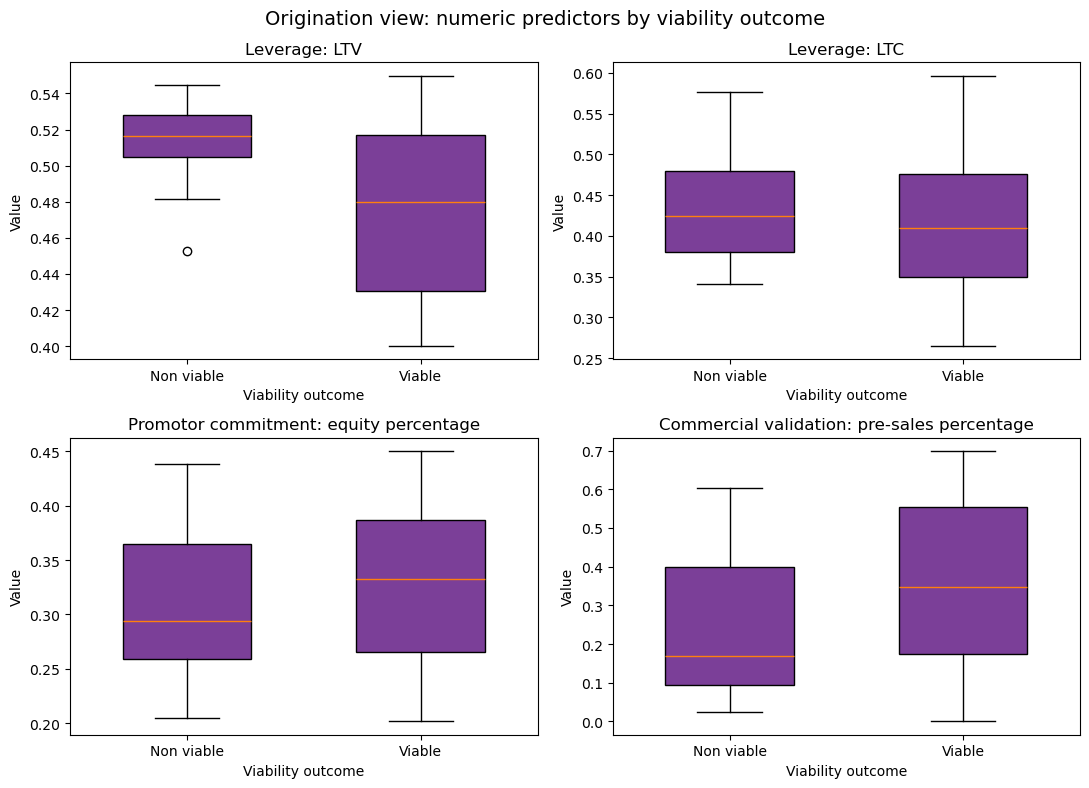

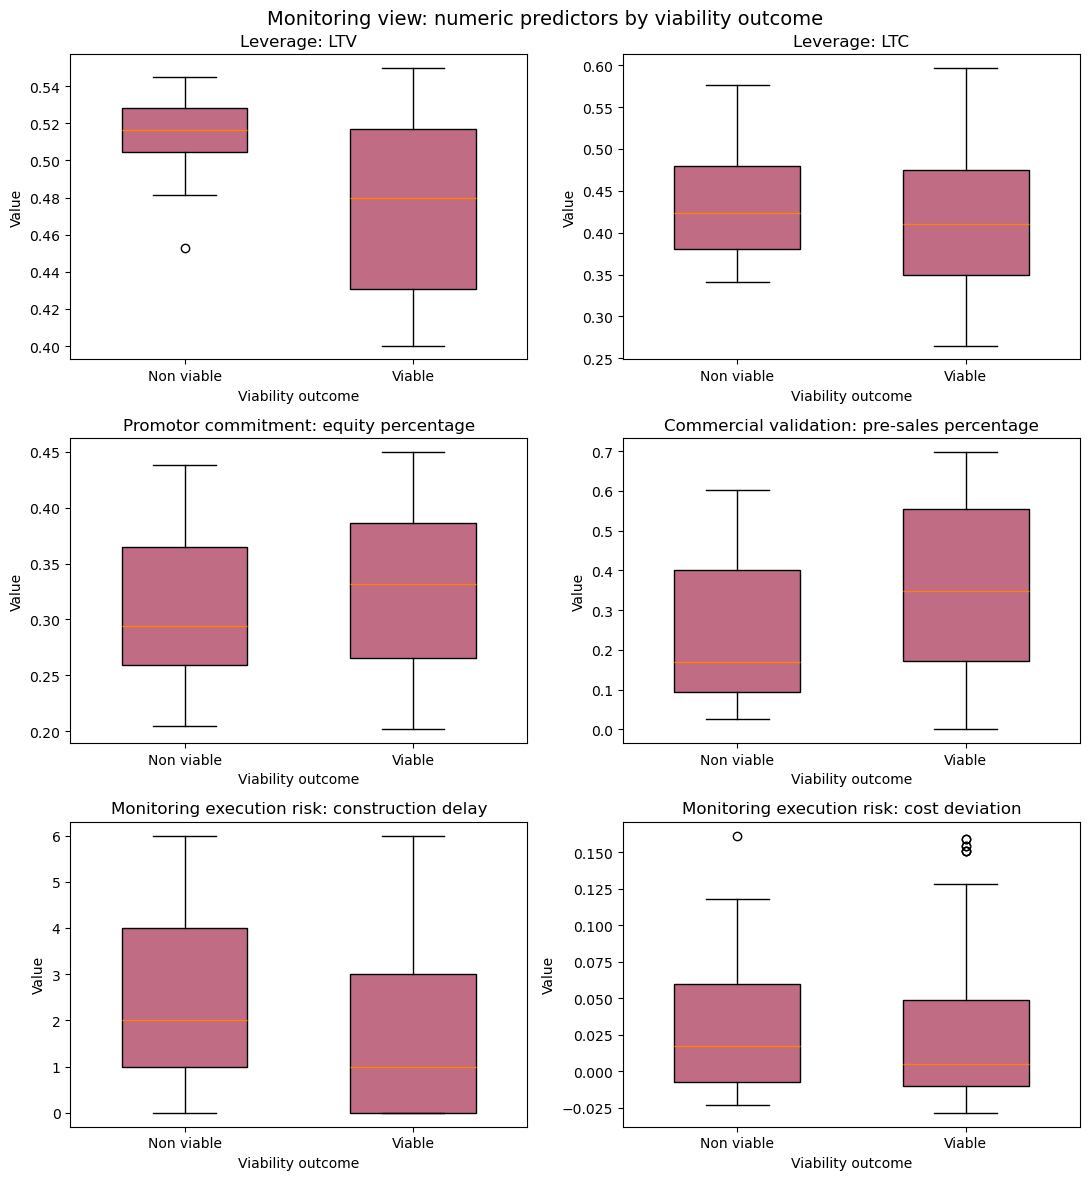

In [63]:
# ============================================================
# BLOCK 60: Review key numeric predictors by viability outcome
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review selected numeric predictors by viability outcome
#   - Separate origination and monitoring views for clearer interpretation
#   - Support model preparation with Business Model relevant variables
# DataFrame created / checked / updated:
#   - origination_view checked
#   - monitoring_view checked
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - Variables are reviewed based on Business Model relevance
#   - Origination variables are available before approval
#   - Monitoring variables include follow up information available after approval
# ============================================================

target_col = "operacion_viable"

target_order = [0, 1]
target_labels = ["Non viable", "Viable"]

origination_numeric_predictors = [
    "LTV",
    "LTC",
    "equity_promotor_pct",
    "porcentaje_preventas"
]

monitoring_numeric_predictors = [
    "LTV",
    "LTC",
    "equity_promotor_pct",
    "porcentaje_preventas",
    "retraso_obra_meses",
    "desviacion_coste_pct"
]

variable_labels = {
    "LTV": "Leverage: LTV",
    "LTC": "Leverage: LTC",
    "equity_promotor_pct": "Promotor commitment: equity percentage",
    "porcentaje_preventas": "Commercial validation: pre-sales percentage",
    "retraso_obra_meses": "Monitoring execution risk: construction delay",
    "desviacion_coste_pct": "Monitoring execution risk: cost deviation"
}
def plot_numeric_predictors_by_target(dataframe, variables, view_title, color):
    
    n_cols = 2
    n_rows = (len(variables) + 1) // n_cols
    
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(11, 4 * n_rows)
    )
    
    axes = axes.flatten()
    
    for i, variable in enumerate(variables):
        
        plot_values = [
            dataframe.loc[
                dataframe[target_col] == target,
                variable
            ].dropna()
            for target in target_order
        ]
        
        boxplot = axes[i].boxplot(
            plot_values,
            tick_labels=target_labels,
            patch_artist=True,
            widths=0.55
        )
        
        for box in boxplot["boxes"]:
            box.set_facecolor(color)
        
        axes[i].set_title(variable_labels[variable])
        axes[i].set_xlabel("Viability outcome")
        axes[i].set_ylabel("Value")
    
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    
    fig.suptitle(view_title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_numeric_predictors_by_target(
    origination_view,
    origination_numeric_predictors,
    "Origination view: numeric predictors by viability outcome",
    "#7B3F98"
)

plot_numeric_predictors_by_target(
    monitoring_view,
    monitoring_numeric_predictors,
    "Monitoring view: numeric predictors by viability outcome",
    "#C06C84"
)

The selected numerical variables were reviewed because they represent the main quantitative logic for the business model. LTV and LTC capture leverage and exposure, equity_promotor_pct reflects the promoter's own financial commitment, and procentaje_preventas captures commercial validation of the project in the monitoring view. retraso_obra_meses and desviacion_coste_pct are added because they represent follow up information related to execution risk and cost pressure. the grpah show that non viable oeprations generally have higher LTV. Slightly higher LTC, lower promoter equity, and lower pre-sales, while viable operations tend to show stronger equity contribution and commercial validation. In monitoring view, non viable operations also show higher construction delays and slightly higher cost deviation. Overall, the variables behave in an economically coherent way, but the overlap between groups shows that viability is not explained by a single numeric variable and supports moving to multivariable classification models. 

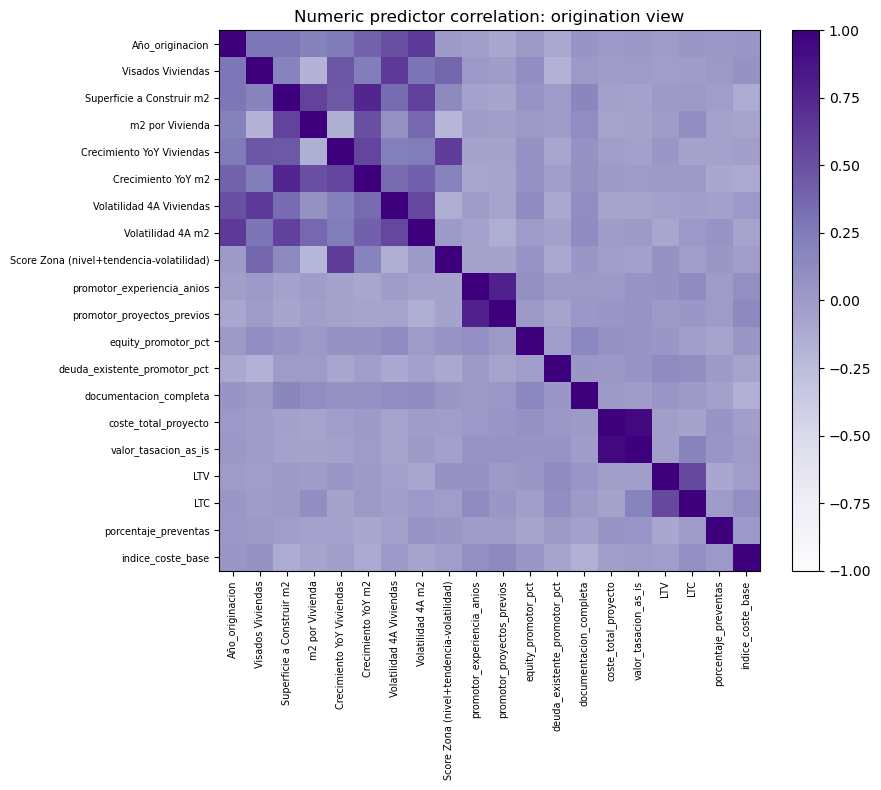

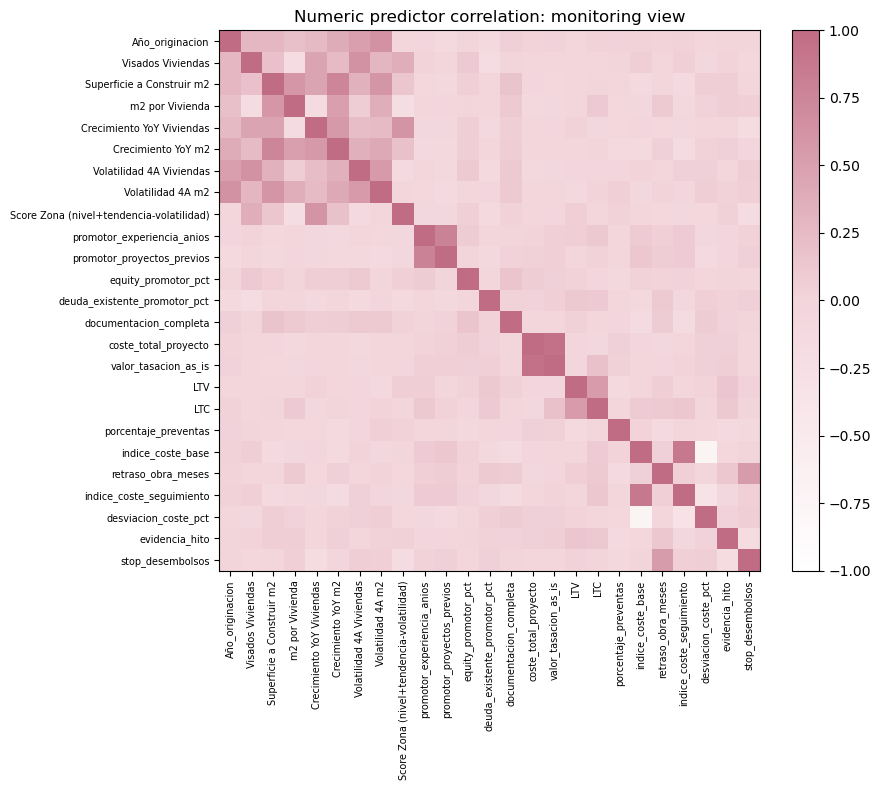

predictor_1,predictor_2,correlation,absolute_correlation
coste_total_proyecto,valor_tasacion_as_is,0.944319,0.944319
promotor_experiencia_anios,promotor_proyectos_previos,0.785936,0.785936
Superficie a Construir m2,Crecimiento YoY m2,0.752697,0.752697
Visados Viviendas,Volatilidad 4A Viviendas,0.630420,0.630420
Año_originacion,Volatilidad 4A m2,0.626518,0.626518
Crecimiento YoY Viviendas,Score Zona (nivel+tendencia-volatilidad),0.616650,0.616650
Superficie a Construir m2,Volatilidad 4A m2,0.588062,0.588062
Superficie a Construir m2,m2 por Vivienda,0.579192,0.579192
Crecimiento YoY Viviendas,Crecimiento YoY m2,0.564169,0.564169
Volatilidad 4A Viviendas,Volatilidad 4A m2,0.547278,0.547278


In [64]:
# ============================================================
# BLOCK 61: Review numeric redundancy before final modeling views
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review redundancy among numeric predictors before finalizing modeling views
#   - Identify strongly overlapping Business Model variables
#   - Support a defensible feature reduction decision before model preparation
# DataFrame created / checked / updated:
#   - redundancy_outputs
#   - origination_top_numeric_correlations
#   - monitoring_top_numeric_correlations
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - The target variable is excluded from this review
#   - This block is diagnostic and does not remove predictors
# ============================================================

target_col = "operacion_viable"



from matplotlib.colors import LinearSegmentedColormap

monitoring_cmap = LinearSegmentedColormap.from_list(
    "monitoring_rose",
    ["#FFFFFF", "#F3D5DC", "#C06C84"]
)
redundancy_views = {
    "Origination view": {
        "data": origination_view,
        "color_map": "Purples"
    },
    "Monitoring view": {
        "data": monitoring_view,
        "color_map": monitoring_cmap
    }
}


def get_numeric_correlation_review(dataframe):
    
    numeric_predictors = (
        dataframe
        .drop(columns=[target_col])
        .select_dtypes(include=["number"])
    )
    
    correlation_matrix = numeric_predictors.corr()
    
    correlation_pairs = (
        correlation_matrix
        .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
        .stack()
        .reset_index()
    )
    
    correlation_pairs.columns = [
        "predictor_1",
        "predictor_2",
        "correlation"
    ]
    
    correlation_pairs["absolute_correlation"] = correlation_pairs["correlation"].abs()
    
    top_correlations = (
        correlation_pairs
        .sort_values("absolute_correlation", ascending=False)
        .head(15)
        .reset_index(drop=True)
    )
    
    return correlation_matrix, top_correlations


def plot_correlation_heatmap(matrix, title, color_map):
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    heatmap = ax.imshow(
        matrix,
        cmap=color_map,
        vmin=-1,
        vmax=1
    )
    
    ax.set_title(title)
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_yticks(range(len(matrix.index)))
    ax.set_xticklabels(matrix.columns, rotation=90, fontsize=7)
    ax.set_yticklabels(matrix.index, fontsize=7)
    
    fig.colorbar(
        heatmap,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )
    
    plt.tight_layout()
    plt.show()


redundancy_outputs = {}

for view_name, view_info in redundancy_views.items():
    
    correlation_matrix, top_correlations = get_numeric_correlation_review(
        view_info["data"]
    )
    
    redundancy_outputs[view_name] = {
        "correlation_matrix": correlation_matrix,
        "top_correlations": top_correlations
    }
    
    plot_correlation_heatmap(
        correlation_matrix,
        f"Numeric predictor correlation: {view_name.lower()}",
        view_info["color_map"]
    )


origination_top_numeric_correlations = redundancy_outputs["Origination view"]["top_correlations"]
monitoring_top_numeric_correlations = redundancy_outputs["Monitoring view"]["top_correlations"]

display_side_by_side(
    origination_top_numeric_correlations,
    monitoring_top_numeric_correlations,
    "Origination view strongest numeric relationships",
    "Monitoring view strongest numeric relationships"
)

The numeric redundancy review shows that most relationships between predictors are moderate and economically interpretable, but one pair stands out clearly: coste_total_proyecto and valor_tasacion_as_is, with a correlation of 0.944 in both modeling views. This indicates that both variables are capturing a very similar project scale signal, which could create multicollinearity and make the logistic regression coefficients less stable or harder to interpret. Since the same predictor structure will be used later to compare logistic regression, decision tree, Random Forest and XGBoost, the redundancy decision must be applied consistently before modeling. Although both variables are relevant to the Business Model, valor_tasacion_as_is is removed from the final modeling views because the collateral-risk logic remains represented through LTV, while coste_total_proyecto is retained to preserve the absolute scale and budget size of the development. Therefore, the model keeps the project cost dimension directly through coste_total_proyecto, the project financing pressure through LTC, and the collateral risk ratio through LTV, while reducing duplicated information before the predictive modeling stage.

In [65]:
# ============================================================
# BLOCK 62: Drop redundant valuation variable and recheck correlations
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Drop valor_tasacion_as_is from the final modeling views
#   - Recheck the strongest numeric correlations after the reduction
# DataFrame created / checked / updated:
#   - origination_view updated
#   - monitoring_view updated
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - valor_tasacion_as_is is removed only from the modeling views
#   - The variable remains available in the full Business Model
# ============================================================

target_col = "operacion_viable"

drop_cols = ["valor_tasacion_as_is"]

origination_view = origination_view.drop(
    columns=[col for col in drop_cols if col in origination_view.columns]
)

monitoring_view = monitoring_view.drop(
    columns=[col for col in drop_cols if col in monitoring_view.columns]
)

origination_predictor_cols = [
    col for col in origination_view.columns
    if col != target_col
]

monitoring_predictor_cols = [
    col for col in monitoring_view.columns
    if col != target_col
]

def get_top_numeric_correlations(df, target_col, top_n=15):
    numeric_cols = df.drop(columns=[target_col]).select_dtypes(include="number").columns
    corr_matrix = df[numeric_cols].corr()

    corr_pairs = (
        corr_matrix
        .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        .stack()
        .reset_index()
    )

    corr_pairs.columns = ["variable_1", "variable_2", "correlation"]
    corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()

    return (
        corr_pairs
        .sort_values("abs_correlation", ascending=False)
        .head(top_n)
        .drop(columns="abs_correlation")
        .reset_index(drop=True)
    )

origination_top_correlations_after = get_top_numeric_correlations(
    origination_view,
    target_col
)

monitoring_top_correlations_after = get_top_numeric_correlations(
    monitoring_view,
    target_col
)

display_side_by_side(
    origination_top_correlations_after,
    monitoring_top_correlations_after,
    "Origination view: top correlations after reduction",
    "Monitoring view: top correlations after reduction"
)

print("Origination view:", origination_view.shape)
print("Monitoring view:", monitoring_view.shape)
print("Dropped from origination view:", [col for col in drop_cols if col not in origination_view.columns])
print("Dropped from monitoring view:", [col for col in drop_cols if col not in monitoring_view.columns])

variable_1,variable_2,correlation
promotor_experiencia_anios,promotor_proyectos_previos,0.785936
Superficie a Construir m2,Crecimiento YoY m2,0.752697
Visados Viviendas,Volatilidad 4A Viviendas,0.630420
Año_originacion,Volatilidad 4A m2,0.626518
Crecimiento YoY Viviendas,Score Zona (nivel+tendencia-volatilidad),0.616650
Superficie a Construir m2,Volatilidad 4A m2,0.588062
Superficie a Construir m2,m2 por Vivienda,0.579192
Crecimiento YoY Viviendas,Crecimiento YoY m2,0.564169
Volatilidad 4A Viviendas,Volatilidad 4A m2,0.547278
LTV,LTC,0.545348


Origination view: (235, 24)
Monitoring view: (235, 30)
Dropped from origination view: ['valor_tasacion_as_is']
Dropped from monitoring view: ['valor_tasacion_as_is']


In [66]:
# ============================================================
# BLOCK 63: Final variable list summary for modeling views
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Update the variable list summary after final modeling view preparation
#   - Confirm the final variables available in each modeling view
# DataFrame created / checked / updated:
#   - final_variable_list_summary
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
# ============================================================

final_modeling_variables = sorted(
    set(origination_view.columns).union(set(monitoring_view.columns))
)

excluded_from_modeling = [
    col for col in hybrid.columns
    if col not in final_modeling_variables
]

final_variable_list_summary = pd.DataFrame({
    "dataset_or_view": [
        "hybrid",
        "excluded_from_modeling",
        "origination_view",
        "monitoring_view"
    ],
    "num_variables": [
        hybrid.shape[1],
        len(excluded_from_modeling),
        origination_view.shape[1],
        monitoring_view.shape[1]
    ],
    "variables": [
        ", ".join(hybrid.columns),
        ", ".join(excluded_from_modeling),
        ", ".join(origination_view.columns),
        ", ".join(monitoring_view.columns)
    ]
})

display(final_variable_list_summary)

,dataset_or_view,num_variables,variables
0,hybrid,76,"operacion_id_simulada, proyecto_id_simulado, p..."
1,excluded_from_modeling,46,"operacion_id_simulada, proyecto_id_simulado, p..."
2,origination_view,24,"Provincia, Año_originacion, Visados Viviendas,..."
3,monitoring_view,30,"Provincia, Año_originacion, Visados Viviendas,..."


Use this paragraph to close the section:

The final variable list summary confirms the separation between the full Business Model and the final modeling views. The original `hybrid` dataset contains 76 variables, including identifiers, RD proxy variables, future validation variables, economic calculation variables, exposure variables, monitoring variables, and the target variable. From these, 46 variables are excluded from the final modeling views for different methodological reasons, including information leakage, variables not available at the decision moment, RD proxy fields, future validation fields, high-cardinality month labels, exposure-related variables, and the redundancy-based removal of `valor_tasacion_as_is`. After these exclusions, `origination_view` contains 24 variables, including 23 predictors and `operacion_viable`, while `monitoring_view` contains 30 variables, including 29 predictors and `operacion_viable`.


<div style="background:#1f4e79; color:white; padding:25px; border-radius:8px; font-size:42px; font-weight:bold;">
PART H: PREDICTIVE MODELING PREPARATION AND EVALUATION
</div>

<br>


In [67]:
# ============================================================
# BLOCK 64: Prepare final regression inputs
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Prepare final X and y objects for binary logistic regression
#   - Verify that the target variable is binary in both modeling views
#   - Identify numeric and categorical predictors for later preprocessing
# DataFrame created / checked / updated:
#   - regression_input_summary
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

target_col = "operacion_viable"

regression_views = {
    "origination_view": origination_view,
    "monitoring_view": monitoring_view
}

regression_inputs = {}
regression_input_rows = []

for view_name, view_df in regression_views.items():
    X = view_df.drop(columns=[target_col]).copy()
    y = view_df[target_col].copy()
    
    numeric_cols = X.select_dtypes(include="number").columns.tolist()
    categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    
    target_values = sorted(y.dropna().unique().tolist())
    
    regression_inputs[view_name] = {
        "X": X,
        "y": y,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols
    }
    
    regression_input_rows.append({
        "modeling_view": view_name,
        "records": len(view_df),
        "predictors": X.shape[1],
        "numeric_predictors": len(numeric_cols),
        "categorical_predictors": len(categorical_cols),
        "target_variable": target_col,
        "target_values": target_values,
        "missing_values": view_df.isna().sum().sum()
    })

regression_input_summary = pd.DataFrame(regression_input_rows)

display(regression_input_summary)

,modeling_view,records,predictors,numeric_predictors,categorical_predictors,target_variable,target_values,missing_values
0,origination_view,235,23,19,4,operacion_viable,"[0, 1]",0
1,monitoring_view,235,29,24,5,operacion_viable,"[0, 1]",0


In [68]:
# ============================================================
# BLOCK 65: Create stratified train and test splits
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Create stratified 70/30 train and test splits for each modeling view
#   - Verify that the target distribution is preserved in each split
# DataFrame created / checked / updated:
#   - split_distribution_summary
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

from sklearn.model_selection import train_test_split

test_size = 0.30
random_state = 42

regression_splits = {}
split_distribution_rows = []

for view_name, input_data in regression_inputs.items():
    X = input_data["X"]
    y = input_data["y"]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    
    regression_splits[view_name] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }
    
    for split_name, split_y in {
        "Train": y_train,
        "Test": y_test
    }.items():
        class_counts = split_y.value_counts().sort_index()
        class_percentages = split_y.value_counts(normalize=True).sort_index() * 100
        
        for target_value in class_counts.index:
            split_distribution_rows.append({
                "modeling_view": view_name,
                "split": split_name,
                "target_value": target_value,
                "records": class_counts.loc[target_value],
                "percentage": round(class_percentages.loc[target_value], 2)
            })

split_distribution_summary = pd.DataFrame(split_distribution_rows)

def format_split_distribution(summary, view_name):
    subset = summary[
        summary["modeling_view"] == view_name
    ]

    records = (
        subset
        .pivot(index="split", columns="target_value", values="records")
        .rename(columns={
            0: "non_viable_records",
            1: "viable_records"
        })
        .reindex(["Train", "Test"])
    )

    percentages = (
        subset
        .pivot(index="split", columns="target_value", values="percentage")
        .rename(columns={
            0: "non_viable_pct",
            1: "viable_pct"
        })
        .reindex(["Train", "Test"])
    )

    table = records.join(percentages).reset_index()

    table.insert(
        1,
        "total_records",
        table["non_viable_records"] + table["viable_records"]
    )

    return table[
        [
            "split",
            "total_records",
            "non_viable_records",
            "non_viable_pct",
            "viable_records",
            "viable_pct"
        ]
    ]


origination_split_distribution = format_split_distribution(
    split_distribution_summary,
    "origination_view"
)

monitoring_split_distribution = format_split_distribution(
    split_distribution_summary,
    "monitoring_view"
)

display_side_by_side(
    origination_split_distribution,
    monitoring_split_distribution,
    "Origination view: train and test distribution",
    "Monitoring view: train and test distribution"
)

target_value,split,total_records,non_viable_records,non_viable_pct,viable_records,viable_pct
,Train,164,16,9.76,148,90.24
,Test,71,7,9.86,64,90.14
target_value,split,total_records,non_viable_records,non_viable_pct,viable_records,viable_pct
,Train,164,16,9.76,148,90.24
,Test,71,7,9.86,64,90.14


The stratified 70/30 partition preserved the original class distribution in both analytical views. The training sets contain 164 operations, including 16 non-viable and 148 viable cases, while the test sets contain 71 operations, including 7 non-viable and 64 viable cases. The distributions are identical because the origination and monitoring views contain the same operations and target variable, although they differ in the predictors available at each analytical stage. The limited number of non-viable observations should be considered when interpreting later model performance, as small changes in classification may produce noticeable differences in minority-class metrics.

In [69]:
# ============================================================
# BLOCK 66: Create majority-class baseline evaluation datasets
# Purpose:
#   - Identify the majority class from each training set
#   - Assign that class to every test observation
#   - Prepare actual, predicted, correct, and error indicators
# DataFrames created:
#   - origination_baseline_eval
#   - monitoring_baseline_eval
# Files created:
#   - None
# ============================================================

baseline_evaluations = {}

for view_name, split_data in regression_splits.items():
    y_train = split_data["y_train"].astype(int)
    y_test = split_data["y_test"].astype(int)

    majority_class = int(y_train.value_counts().idxmax())

    baseline_eval = pd.DataFrame({
        "actual": y_test.to_numpy(),
        "predicted": majority_class
    })

    baseline_eval["correct"] = (
        baseline_eval["actual"] ==
        baseline_eval["predicted"]
    ).astype(int)

    baseline_eval["classification_error"] = (
        baseline_eval["actual"] !=
        baseline_eval["predicted"]
    ).astype(int)

    baseline_evaluations[view_name] = baseline_eval

origination_baseline_eval = baseline_evaluations[
    "origination_view"
]

monitoring_baseline_eval = baseline_evaluations[
    "monitoring_view"
]

baseline_setup_summary = pd.DataFrame([
    {
        "modeling_view": "origination_view",
        "test_records": len(origination_baseline_eval),
        "predicted_class": "1 - Viable",
        "unique_prediction_values": str(
            sorted(
                origination_baseline_eval[
                    "predicted"
                ].unique().tolist()
            )
        )
    },
    {
        "modeling_view": "monitoring_view",
        "test_records": len(monitoring_baseline_eval),
        "predicted_class": "1 - Viable",
        "unique_prediction_values": str(
            sorted(
                monitoring_baseline_eval[
                    "predicted"
                ].unique().tolist()
            )
        )
    }
])

display(baseline_setup_summary)

,modeling_view,test_records,predicted_class,unique_prediction_values
0,origination_view,71,1 - Viable,[1]
1,monitoring_view,71,1 - Viable,[1]


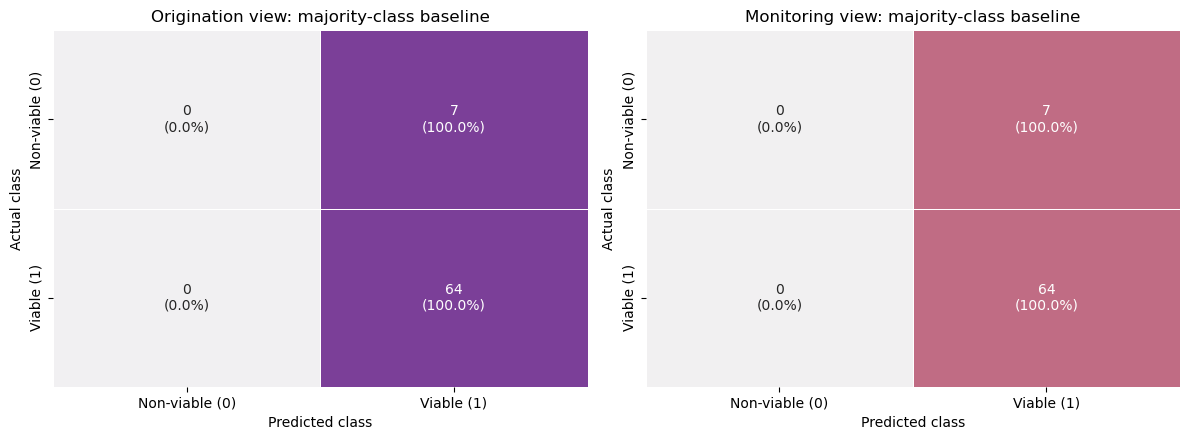

In [70]:
# ============================================================
# BLOCK 67: Create majority-class baseline confusion matrices
# Purpose:
#   - Compare actual and predicted classes for each baseline
#   - Store confusion matrices for later metric calculations
#   - Visualize baseline classification results
# DataFrames created:
#   - origination_baseline_confusion
#   - monitoring_baseline_confusion
# Files created:
#   - None
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class_labels = [
    "Non-viable (0)",
    "Viable (1)"
]

baseline_confusion_matrices = {}

for view_name, baseline_eval in baseline_evaluations.items():
    confusion_values = confusion_matrix(
        baseline_eval["actual"],
        baseline_eval["predicted"],
        labels=[0, 1]
    )

    baseline_confusion_matrices[view_name] = pd.DataFrame(
        confusion_values,
        index=class_labels,
        columns=class_labels
    )

origination_baseline_confusion = baseline_confusion_matrices[
    "origination_view"
]

monitoring_baseline_confusion = baseline_confusion_matrices[
    "monitoring_view"
]

# Calculate row percentages
origination_baseline_confusion_pct = (
    origination_baseline_confusion
    .div(
        origination_baseline_confusion.sum(axis=1),
        axis=0
    )
    .mul(100)
)

monitoring_baseline_confusion_pct = (
    monitoring_baseline_confusion
    .div(
        monitoring_baseline_confusion.sum(axis=1),
        axis=0
    )
    .mul(100)
)


def create_confusion_annotations(counts, percentages):
    annotations = counts.astype(str).copy()

    for row in counts.index:
        for column in counts.columns:
            annotations.loc[row, column] = (
                f"{counts.loc[row, column]}\n"
                f"({percentages.loc[row, column]:.1f}%)"
            )

    return annotations


origination_baseline_annotations = (
    create_confusion_annotations(
        origination_baseline_confusion,
        origination_baseline_confusion_pct
    )
)

monitoring_baseline_annotations = (
    create_confusion_annotations(
        monitoring_baseline_confusion,
        monitoring_baseline_confusion_pct
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5)
)

sns.heatmap(
    origination_baseline_confusion_pct,
    annot=origination_baseline_annotations,
    fmt="",
    cmap=sns.light_palette("#7B3F98", as_cmap=True),
    vmin=0,
    vmax=100,
    cbar=False,
    linewidths=0.5,
    ax=axes[0]
)

axes[0].set_title(
    "Origination view: majority-class baseline"
)
axes[0].set_xlabel("Predicted class")
axes[0].set_ylabel("Actual class")

sns.heatmap(
    monitoring_baseline_confusion_pct,
    annot=monitoring_baseline_annotations,
    fmt="",
    cmap=sns.light_palette("#C06C84", as_cmap=True),
    vmin=0,
    vmax=100,
    cbar=False,
    linewidths=0.5,
    ax=axes[1]
)

axes[1].set_title(
    "Monitoring view: majority-class baseline"
)
axes[1].set_xlabel("Predicted class")
axes[1].set_ylabel("Actual class")

plt.tight_layout()
plt.show()

The majority class baseline predicted every test operation as viable in both analytical views. This rule correctly classified all 64 viable operations but incorrectly assigned the 7 non viable operations to the viable class, resulting in a 0% detection rate for non viable cases. This behavior is expected because the baseline does not use any predictors and simply reproduces the most frequent class observed in the training data. Therefore, although the baseline correctly classifies most observations due to the strong class imbalances, it cannot distinguish economically nonviable options and serves only as a minimum benchmark for the subsequent classification models

In [71]:
# ============================================================
# BLOCK 68: Consolidate majority-class baseline metrics
# Purpose:
#   - Summarize the baseline evaluation in one comparison row
#   - Evaluate overall performance and non-viable detection
#   - Calculate probability-based no-skill metrics
# DataFrame created:
#   - baseline_metrics_summary
# Files created:
#   - None
# ============================================================


from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

# Confirm that both views have the same baseline outcomes
origination_baseline = (
    baseline_evaluations["origination_view"][
        ["actual", "predicted"]
    ]
    .reset_index(drop=True)
)

monitoring_baseline = (
    baseline_evaluations["monitoring_view"][
        ["actual", "predicted"]
    ]
    .reset_index(drop=True)
)

assert origination_baseline.equals(
    monitoring_baseline
), "Baseline outcomes differ across analytical views."

# Use one shared baseline calculation because predictors are not used
y_true = origination_baseline["actual"].astype(int)
y_pred = origination_baseline["predicted"].astype(int)

# Treat non-viable operations as the class of interest
y_true_non_viable = (y_true == 0).astype(int)

# Use training prevalence as the constant no-skill probability
y_train = regression_splits[
    "origination_view"
]["y_train"].astype(int)

non_viable_train_prevalence = (
    y_train == 0
).mean()

non_viable_probability = np.full(
    shape=len(y_true),
    fill_value=non_viable_train_prevalence
)

accuracy = accuracy_score(
    y_true,
    y_pred
)

classification_error = 1 - accuracy

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision_non_viable = precision_score(
    y_true,
    y_pred,
    pos_label=0,
    zero_division=0
)

recall_non_viable = recall_score(
    y_true,
    y_pred,
    pos_label=0,
    zero_division=0
)

f1_non_viable = f1_score(
    y_true,
    y_pred,
    pos_label=0,
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

pr_auc = average_precision_score(
    y_true_non_viable,
    non_viable_probability
)

baseline_metrics_summary = pd.DataFrame([{
    "model": "Majority baseline",
    "accuracy_pct": round(
        accuracy * 100,
        2
    ),
    "classification_error_pct": round(
        classification_error * 100,
        2
    ),
    "balanced_accuracy_pct": round(
        balanced_accuracy * 100,
        2
    ),
    "precision_non_viable_pct": round(
        precision_non_viable * 100,
        2
    ),
    "recall_non_viable_pct": round(
        recall_non_viable * 100,
        2
    ),
    "f1_non_viable_pct": round(
        f1_non_viable * 100,
        2
    ),
    "macro_f1_pct": round(
        macro_f1 * 100,
        2
    ),
    "pr_auc_pct": round(
        pr_auc * 100,
        2
    )
}])

# Create a clean comparison table by analytical view
baseline_metrics_display = pd.DataFrame({
    "Metric": [
        "Model",
        "Accuracy",
        "Classification error",
        "Balanced accuracy",
        "Precision: non-viable",
        "Recall: non-viable",
        "F1-score: non-viable",
        "Macro F1-score",
        "PR-AUC"
    ],
    "Origination view": [
        baseline_metrics_summary.loc[0, "model"],
        f'{baseline_metrics_summary.loc[0, "accuracy_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "classification_error_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "balanced_accuracy_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "precision_non_viable_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "recall_non_viable_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "f1_non_viable_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "macro_f1_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "pr_auc_pct"]:.2f}%'
    ],
    "Monitoring view": [
        baseline_metrics_summary.loc[0, "model"],
        f'{baseline_metrics_summary.loc[0, "accuracy_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "classification_error_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "balanced_accuracy_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "precision_non_viable_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "recall_non_viable_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "f1_non_viable_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "macro_f1_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "pr_auc_pct"]:.2f}%'
    ]
})

display(
    baseline_metrics_display.style
    .hide(axis="index")
    .set_caption(
        "Majority-class baseline performance by analytical view"
    )
)

Metric,Origination view,Monitoring view
Model,Majority baseline,Majority baseline
Accuracy,90.14%,90.14%
Classification error,9.86%,9.86%
Balanced accuracy,50.00%,50.00%
Precision: non-viable,0.00%,0.00%
Recall: non-viable,0.00%,0.00%
F1-score: non-viable,0.00%,0.00%
Macro F1-score,47.41%,47.41%
PR-AUC,9.86%,9.86%


The majority-class baseline is a simple reference model that assumes every operation is viable because that is the most common outcome in the training data. Since it does not use any of the variables from either the origination or monitoring view, both views produce the same results. At first glance, the 90.14% accuracy appears high, but this is misleading because the model correctly identifies only the 64 viable operations and misses all 7 non-viable operations. This is why precision, recall, and F1-score for the non-viable class are all 0.00%. The balanced accuracy of 50.00%, the Macro F1-score of 47.41%, and the PR-AUC of 9.86% confirm that the baseline is not able to separate viable from non-viable cases. Its purpose is therefore not to make useful predictions, but to provide a minimum benchmark that the later models should improve.


In [72]:
# ============================================================
# BLOCK 69: Review categorical training distributions
# Purpose:
#   - Confirm the remaining categorical predictors
#   - Display category counts and percentages using training data only
#   - Support the later selection of reference categories
# DataFrames created:
#   - categorical_predictor_overview
#   - categorical_reference_review
#   - origination_reference_review
#   - monitoring_reference_review
# Files created:
#   - None
# ============================================================

categorical_reference_review = {}
categorical_overview_rows = []

for view_name, split_data in regression_splits.items():
    X_train = split_data["X_train"].copy()

    categorical_columns = (
        X_train
        .select_dtypes(
            include=["object", "category", "bool"]
        )
        .columns
        .tolist()
    )

    numeric_columns = (
        X_train
        .select_dtypes(
            exclude=["object", "category", "bool"]
        )
        .columns
        .tolist()
    )

    categorical_overview_rows.append({
        "Analytical view": view_name.replace(
            "_view",
            " view"
        ).title(),
        "Total predictors": X_train.shape[1],
        "Numeric predictors": len(numeric_columns),
        "Categorical predictors": len(categorical_columns),
        "Named categorical predictors": ", ".join(
            categorical_columns
        )
    })

    review_rows = []

    for variable in categorical_columns:
        category_counts = (
            X_train[variable]
            .astype("object")
            .fillna("Missing")
            .value_counts(dropna=False)
        )

        total_records = int(category_counts.sum())
        maximum_count = int(category_counts.max())

        for category, count in category_counts.items():
            review_rows.append({
                "Variable": variable,
                "Category": category,
                "Training records": int(count),
                "Training percentage": (
                    f"{count / total_records * 100:.2f}%"
                ),
                "Most frequent": (
                    "Yes"
                    if int(count) == maximum_count
                    else ""
                )
            })

    categorical_reference_review[view_name] = (
        pd.DataFrame(review_rows)
    )

categorical_predictor_overview = pd.DataFrame(
    categorical_overview_rows
)

origination_reference_review = (
    categorical_reference_review[
        "origination_view"
    ]
)

monitoring_reference_review = (
    categorical_reference_review[
        "monitoring_view"
    ]
)

display(
    categorical_predictor_overview.style
    .hide(axis="index")
    .set_caption(
        "Training predictor overview by analytical view"
    )
)

display_side_by_side(
    origination_reference_review,
    monitoring_reference_review,
    "Origination view: categorical training review",
    "Monitoring view: categorical training review"
)

Analytical view,Total predictors,Numeric predictors,Categorical predictors,Named categorical predictors
Origination View,23,19,4,"Provincia, tipo_promotor, riesgo_legal_titulo, tipo_activo"
Monitoring View,29,24,5,"Provincia, tipo_promotor, riesgo_legal_titulo, tipo_activo, hito_actual"


Variable,Category,Training records,Training percentage,Most frequent
Provincia,Madrid,37,22.56%,Yes
Provincia,Malaga,35,21.34%,
Provincia,Alicante,34,20.73%,
Provincia,Barcelona,29,17.68%,
Provincia,Valencia,29,17.68%,
tipo_promotor,sociedad_vehiculo_proyecto,38,23.17%,Yes
tipo_promotor,cooperativa,37,22.56%,
tipo_promotor,promotor_local,31,18.90%,
tipo_promotor,sociedad_patrimonial,30,18.29%,
tipo_promotor,promotor_pyme,28,17.07%,


The origination view contains four categorical predictors, while the monitoring view contains five. Both views share the same four categorical variables, and the monitoring view additionally includes hito_actual. Within tipo_promotor, sociedad_vehiculo_proyecto and cooperativa represented 23.17% and 22.56% of the origination training sample, respectively. Although their representation was nearly identical, sociedad_vehiculo_proyecto was retained as the reference because it is more consistent with the project-level orientation of the Business Model, concentrating the project’s assets, debt, collateral, costs, and cash flows within a dedicated entity. By contrast, a cooperative represents a more specialized member-based development structure.

In [73]:
# ============================================================
# BLOCK 70: Confirm selected reference categories
# Purpose:
#   - Store the reference category selected for each predictor
#   - Display the selections for both analytical views
# DataFrames created:
#   - origination_reference_selection
#   - monitoring_reference_selection
# Files created:
#   - None
# ============================================================

categorical_reference_map = {
    "origination_view": {
        "Provincia": "Madrid",
        "tipo_promotor": "sociedad_vehiculo_proyecto",
        "riesgo_legal_titulo": "bajo",
        "tipo_activo": "obra_nueva"
    },
    "monitoring_view": {
        "Provincia": "Madrid",
        "tipo_promotor": "sociedad_vehiculo_proyecto",
        "riesgo_legal_titulo": "bajo",
        "tipo_activo": "obra_nueva",
        "hito_actual": "inicio_obra"
    }
}

origination_reference_selection = pd.DataFrame(
    categorical_reference_map["origination_view"].items(),
    columns=[
        "Categorical predictor",
        "Reference category"
    ]
)

monitoring_reference_selection = pd.DataFrame(
    categorical_reference_map["monitoring_view"].items(),
    columns=[
        "Categorical predictor",
        "Reference category"
    ]
)

display_side_by_side(
    origination_reference_selection,
    monitoring_reference_selection,
    "Origination view: selected references",
    "Monitoring view: selected references"
)

Categorical predictor,Reference category
Provincia,Madrid
tipo_promotor,sociedad_vehiculo_proyecto
riesgo_legal_titulo,bajo
tipo_activo,obra_nueva
Categorical predictor,Reference category
Provincia,Madrid
tipo_promotor,sociedad_vehiculo_proyecto
riesgo_legal_titulo,bajo
tipo_activo,obra_nueva
hito_actual,inicio_obra


In [74]:
# ============================================================
# BLOCK 71: Complete unpenalized logistic regression diagnostics
# Purpose:
#   - Fit the complete unpenalized model for each view
#   - Evaluate numerical stability and training separation
# 
# DataFrames created:
#   - complete_logistic_diagnostic_summary
#   - origination_complete_diagnostic
#   - monitoring_complete_diagnostic
#   - origination_complete_coefficients
#   - monitoring_complete_coefficients
# Files created:
#   - None
# ============================================================

import warnings
import statsmodels.api as sm

# 1. Standardize numeric predictors and create 0/1 dummies
def build_complete_design_matrix(X_train, reference_categories):
    categorical_columns = list(reference_categories)
    numeric_columns = [c for c in X_train.columns if c not in categorical_columns]

    X_raw = X_train[numeric_columns].apply(pd.to_numeric, errors="raise").astype(float)
    numeric_mean = X_raw.mean()
    numeric_std = X_raw.std(ddof=0).replace(0, 1)
    parts = [(X_raw - numeric_mean) / numeric_std]

    for variable in categorical_columns:
        reference = reference_categories[variable]
        observed = X_train[variable].astype(str)
        assert reference in observed.unique(), (
            f"Reference category '{reference}' is not present in {variable}."
        )

        levels = [reference] + sorted(set(observed) - {reference})
        categorical_series = pd.Series(
            pd.Categorical(observed, categories=levels),
            index=X_train.index,
            name=variable
        )

        parts.append(pd.get_dummies(
            categorical_series,
            prefix=variable,
            prefix_sep="=",
            drop_first=True,
            dtype=float
        ))

    X_design = sm.add_constant(pd.concat(parts, axis=1), has_constant="add")
    X_design = X_design.apply(pd.to_numeric, errors="raise").astype(float)

    return {
        "X_design": X_design,
        "numeric_columns": numeric_columns,
        "categorical_columns": categorical_columns,
        "numeric_mean": numeric_mean,
        "numeric_std": numeric_std
    }

# 2. Fit one complete model and calculate its diagnostics
def fit_complete_view(view_name, split_data):
    X_train = split_data["X_train"].copy()
    y_train = pd.to_numeric(split_data["y_train"], errors="raise").astype(float)

    design = build_complete_design_matrix(
        X_train,
        categorical_reference_map[view_name]
    )

    X_design = design["X_design"]
    y_train = y_train.reindex(X_design.index)

    assert X_design.index.equals(y_train.index)
    assert np.isfinite(X_design.to_numpy()).all()
    assert np.isfinite(y_train.to_numpy()).all()

    design_array = X_design.to_numpy()
    matrix_rank = int(np.linalg.matrix_rank(design_array))
    design_columns = X_design.shape[1]
    full_column_rank = matrix_rank == design_columns
    condition_number = float(np.linalg.cond(design_array))

    with warnings.catch_warnings(record=True) as captured_warnings:
        warnings.simplefilter("always")
        model = sm.Logit(y_train, X_design).fit(
            method="lbfgs",
            maxiter=5000,
            disp=False
        )

    warning_messages = [str(w.message) for w in captured_warnings]
    if any("Inverting hessian failed" in m for m in warning_messages):
        warning_summary = "Hessian inversion failed"
    elif warning_messages:
        warning_summary = " | ".join(sorted(set(warning_messages)))
    else:
        warning_summary = "None"

    try:
        covariance_available = bool(
            np.isfinite(np.asarray(model.cov_params())).all()
        )
    except Exception:
        covariance_available = False

    probabilities = np.asarray(model.predict(X_design), dtype=float)
    training_records = len(y_train)
    non_viable_records = int((y_train == 0).sum())
    viable_records = int((y_train == 1).sum())
    estimated_parameters = len(model.params)
    transformed_predictors = X_design.shape[1] - 1
    cases_per_parameter = non_viable_records / estimated_parameters

    below_001 = int((probabilities < 0.01).sum())
    above_099 = int((probabilities > 0.99).sum())
    separation_warning = (below_001 + above_099) / training_records >= 0.95
    low_minority_support = non_viable_records < estimated_parameters
    inference_reliable = (
        covariance_available
        and not separation_warning
        and not low_minority_support
    )

    negative_two_log_likelihood = float(-2 * model.llf)
    aic = float(model.aic)
    bic = float(model.bic)
    denominator = training_records - estimated_parameters - 1
    aicc = (
        aic + 2 * estimated_parameters * (estimated_parameters + 1) / denominator
        if denominator > 0 else np.nan
    )

    coefficients = model.params.drop("const", errors="ignore")
    coefficient_table = (
        coefficients.rename("Coefficient")
        .rename_axis("Parameter")
        .reset_index()
        .assign(_magnitude=lambda x: x["Coefficient"].abs())
        .sort_values("_magnitude", ascending=False)
        .drop(columns="_magnitude")
        .reset_index(drop=True)
    )

    if not covariance_available:
        conclusion = "Training separation and unavailable classical inference"
    elif separation_warning:
        conclusion = "Training separation and unreliable classical inference"
    elif low_minority_support:
        conclusion = "Insufficient minority support for complete-model inference"
    else:
        conclusion = "No major diagnostic issue detected"

    converged = bool(model.mle_retvals.get("converged", False))
    yes_no = lambda value: "Yes" if value else "No"

    summary = {
        "Analytical view": view_name.replace("_view", " view").title(),
        "Training records": training_records,
        "Non-viable records": non_viable_records,
        "Viable records": viable_records,
        "Original predictors": X_train.shape[1],
        "Transformed predictors": transformed_predictors,
        "Estimated parameters": estimated_parameters,
        "Non-viable cases per parameter": cases_per_parameter,
        "Matrix rank": matrix_rank,
        "Design columns": design_columns,
        "Full column rank": full_column_rank,
        "Condition number": condition_number,
        "Maximum coefficient magnitude": float(coefficients.abs().max()),
        "Probabilities below 0.01": below_001,
        "Probabilities above 0.99": above_099,
        "-2 Log L": negative_two_log_likelihood,
        "AIC": aic,
        "AICc": aicc,
        "BIC / SC": bic,
        "Converged": converged,
        "Covariance available": covariance_available,
        "Reliable inference": inference_reliable,
        "Estimation warning": warning_summary,
        "Diagnostic conclusion": conclusion
    }

    display_table = pd.DataFrame({
        "Diagnostic": [
            "Training records",
            "Non-viable records",
            "Original predictors",
            "Transformed predictors",
            "Estimated parameters",
            "Non-viable cases per parameter",
            "Design matrix rank",
            "Condition number",
            "Maximum coefficient magnitude",
            "Extreme fitted probabilities",
            "-2 Log L",
            "AIC",
            "AICc",
            "BIC / SC",
            "Converged",
            "Covariance matrix available",
            "Reliable classical inference",
            "Diagnostic conclusion"
        ],
        "Result": [
            str(training_records),
            str(non_viable_records),
            str(X_train.shape[1]),
            str(transformed_predictors),
            str(estimated_parameters),
            f"{cases_per_parameter:.2f}",
            f"{matrix_rank} of {design_columns} "
            f"({'full rank' if full_column_rank else 'not full rank'})",
            f"{condition_number:.2f}",
            f"{coefficients.abs().max():.2f}",
            f"{below_001} below 0.01; {above_099} above 0.99",
            f"{negative_two_log_likelihood:.2f}",
            f"{aic:.2f}",
            f"{aicc:.2f}",
            f"{bic:.2f}",
            yes_no(converged),
            yes_no(covariance_available),
            yes_no(inference_reliable),
            conclusion
        ]
    })

    stored_design = {
        "X_train_design": X_design,
        "y_train_model": y_train,
        "numeric_columns": design["numeric_columns"],
        "categorical_columns": design["categorical_columns"],
        "numeric_mean": design["numeric_mean"],
        "numeric_std": design["numeric_std"]
    }

    return {
        "model": model,
        "design": stored_design,
        "coefficients": coefficient_table,
        "summary": summary,
        "display": display_table
    }

# 3. Run and store both analytical views
complete_results = {
    view_name: fit_complete_view(view_name, split_data)
    for view_name, split_data in regression_splits.items()
}

complete_diagnostic_models = {
    view: result["model"] for view, result in complete_results.items()
}
complete_design_matrices = {
    view: result["design"] for view, result in complete_results.items()
}
complete_coefficient_tables = {
    view: result["coefficients"] for view, result in complete_results.items()
}
diagnostic_display_tables = {
    view: result["display"] for view, result in complete_results.items()
}
diagnostic_summary_rows = [
    result["summary"] for result in complete_results.values()
]

complete_logistic_diagnostic_summary = pd.DataFrame(diagnostic_summary_rows)

origination_complete_diagnostic = diagnostic_display_tables["origination_view"]
monitoring_complete_diagnostic = diagnostic_display_tables["monitoring_view"]
origination_complete_coefficients = complete_coefficient_tables["origination_view"]
monitoring_complete_coefficients = complete_coefficient_tables["monitoring_view"]

display_side_by_side(
    origination_complete_diagnostic,
    monitoring_complete_diagnostic,
    "Origination view: complete-model diagnostic",
    "Monitoring view: complete-model diagnostic"
)

## 4. Create view1 modeling bases from the transformed matrices
def build_view1_from_design(view_name):
    stored = complete_design_matrices[view_name]
    X_model = stored["X_train_design"].drop(columns="const").copy()
    y_model = stored["y_train_model"].astype(int).rename(target_col)

    preprocessing = {
        "numeric_columns": stored["numeric_columns"],
        "categorical_columns": stored["categorical_columns"],
        "dummy_columns": [
            column for column in X_model.columns
            if column not in stored["numeric_columns"]
        ],
        "predictor_columns": X_model.columns.tolist(),
        "numeric_mean": stored["numeric_mean"],
        "numeric_std": stored["numeric_std"]
    }

    return pd.concat([X_model, y_model], axis=1), preprocessing

# Create the transformed modeling bases
origination_view1, origination_view1_preprocessing = (
    build_view1_from_design("origination_view")
)

monitoring_view1, monitoring_view1_preprocessing = (
    build_view1_from_design("monitoring_view")
)

# Create the explanatory-variable lists for automatic selection
origination_selection_variables = (
    origination_view1_preprocessing["predictor_columns"]
)

monitoring_selection_variables = (
    monitoring_view1_preprocessing["predictor_columns"]
)

# Verify the transformed modeling bases
def view1_summary_row(label, view1, preprocessing):
    target = view1[target_col]

    return {
        "View": label,
        "Training records": len(view1),
        "Standardized numeric": len(
            preprocessing["numeric_columns"]
        ),
        "Dummy variables": len(
            preprocessing["dummy_columns"]
        ),
        "Total predictors": len(
            preprocessing["predictor_columns"]
        ),
        "Non-viable": int((target == 0).sum()),
        "Viable": int((target == 1).sum())
    }

view1_summary = pd.DataFrame([
    view1_summary_row(
        "Origination view1",
        origination_view1,
        origination_view1_preprocessing
    ),
    view1_summary_row(
        "Monitoring view1",
        monitoring_view1,
        monitoring_view1_preprocessing
    )
])

display(view1_summary)

Diagnostic,Result
Training records,164
Non-viable records,16
Original predictors,23
Transformed predictors,31
Estimated parameters,32
Non-viable cases per parameter,0.50
Design matrix rank,32 of 32 (full rank)
Condition number,13.91
Maximum coefficient magnitude,217.17
Extreme fitted probabilities,16 below 0.01; 148 above 0.99


,View,Training records,Standardized numeric,Dummy variables,Total predictors,Non-viable,Viable
0,Origination view1,164,19,12,31,16,148
1,Monitoring view1,164,24,15,39,16,148


The complete unpenalized logistic regressions were used to test whether all available origination and monitoring information could reproduce the Business Model’s decision on whether a financing operation is viable. Both models almost perfectly reproduced the classifications observed in the training sample, assigning probabilities below 1% to all 16 non-viable operations and above 99% to all 148 viable operations. This explains the near-zero −2 Log L, which indicates that the predicted probabilities closely matched the existing viability outcomes. However, it does not identify which specific credit factor produced that result because the prediction is generated from the combined effect of all variables included in each view.

From an underwriting perspective, the models are creating a decision rule that is too detailed for the limited number of non-viable operations available. The origination model estimates 32 parameters and the monitoring model 40 from only 16 non-viable cases, meaning that the models may be learning the exact profiles already present rather than producing a stable rule that can be transferred to a new promoter or project. The higher AIC, AICc, and BIC/SC values for monitoring mainly reflect the additional complexity introduced by its larger information set. Although both models converged, the origination model could not produce the covariance information required for reliable p-values and confidence intervals, while the monitoring model remained unreliable because of the same training-separation pattern. Therefore, the complete models are retained as diagnostic references, but reduced and penalized alternatives are required before the individual lending factors can be interpreted and a final decision-support model can be selected.

In [75]:
# ============================================================
# BLOCK 72: Verify dummy-variable support
# Purpose:
#   - Review the frequency of each dummy variable
#   - Compare possible thresholds before removing any level
#   - Identify dummies without non-viable support
# DataFrames created:
#   - origination_dummy_support
#   - monitoring_dummy_support
#   - dummy_threshold_summary
# Files created:
#   - None
# ============================================================

# 1. Calculate support for each dummy variable
def build_dummy_support(view1, preprocessing):
    target = view1[target_col].astype(int)
    rows = []

    for variable in preprocessing["dummy_columns"]:
        active = view1[variable].eq(1)
        total = int(active.sum())

        rows.append({
            "Dummy variable": variable,
            "Total": total,
            "Share": total / len(view1),
            "Non-viable": int((active & target.eq(0)).sum()),
            "Viable": int((active & target.eq(1)).sum()),
            "Below 3": total < 3,
            "Below 5": total < 5,
            "Below 10": total < 10,
            "Zero non-viable support": int((active & target.eq(0)).sum()) == 0
        })

    result = pd.DataFrame(rows).sort_values(
        ["Total", "Dummy variable"]
    ).reset_index(drop=True)

    result["Share"] = result["Share"].map(lambda value: f"{value:.2%}")

    for column in [
        "Below 3",
        "Below 5",
        "Below 10",
        "Zero non-viable support"
    ]:
        result[column] = result[column].map({True: "Yes", False: "No"})

    return result

# 2. Create support tables for both analytical views
origination_dummy_support = build_dummy_support(
    origination_view1,
    origination_view1_preprocessing
)

monitoring_dummy_support = build_dummy_support(
    monitoring_view1,
    monitoring_view1_preprocessing
)

# 3. Summarize the number of dummies affected by each possible rule
def threshold_summary_row(label, support_table):
    return {
        "View": label,
        "Dummy variables": len(support_table),
        "Below 3": int((support_table["Below 3"] == "Yes").sum()),
        "Below 5": int((support_table["Below 5"] == "Yes").sum()),
        "Below 10": int((support_table["Below 10"] == "Yes").sum()),
        "Zero non-viable support": int(
            (support_table["Zero non-viable support"] == "Yes").sum()
        )
    }

dummy_threshold_summary = pd.DataFrame([
    threshold_summary_row(
        "Origination",
        origination_dummy_support
    ),
    threshold_summary_row(
        "Monitoring",
        monitoring_dummy_support
    )
])

# 4. Display the threshold comparison and detailed support
display(dummy_threshold_summary)

display_side_by_side(
    origination_dummy_support,
    monitoring_dummy_support,
    "Origination view1: dummy support",
    "Monitoring view1: dummy support"
)

,View,Dummy variables,Below 3,Below 5,Below 10,Zero non-viable support
0,Origination,12,0,0,0,0
1,Monitoring,15,0,0,0,0


Dummy variable,Total,Share,Non-viable,Viable,Below 3,Below 5,Below 10,Zero non-viable support
riesgo_legal_titulo=alto,18,10.98%,8,10,No,No,No,No
tipo_activo=finalizacion_obra,28,17.07%,4,24,No,No,No,No
tipo_promotor=promotor_pyme,28,17.07%,3,25,No,No,No,No
Provincia=Barcelona,29,17.68%,2,27,No,No,No,No
Provincia=Valencia,29,17.68%,2,27,No,No,No,No
riesgo_legal_titulo=medio,30,18.29%,4,26,No,No,No,No
tipo_promotor=sociedad_patrimonial,30,18.29%,2,28,No,No,No,No
tipo_promotor=promotor_local,31,18.90%,3,28,No,No,No,No
Provincia=Alicante,34,20.73%,6,28,No,No,No,No
Provincia=Malaga,35,21.34%,3,32,No,No,No,No


The dummy-variable review confirms that the transformed modeling bases do not contain categories with insufficient representation. In `origination_view1`, all 12 dummy variables appear in at least 18 of the 164 training operations, while in `monitoring_view1` the same is true for all 15 dummy variables. None of the categories falls below the possible thresholds of 3, 5 or 10 observations, and every dummy includes at least two non-viable operations. Therefore, no category needs to be removed before the automatic variable-selection stage.

From a business perspective, this means that the model has enough examples of each promoter type, province, asset type, legal-risk level and monitoring milestone to assess whether those characteristics contribute to the viability decision. For example, `riesgo_legal_titulo=alto` appears in 18 operations, including 8 non-viable cases, while `Provincia=Alicante` appears in 34 operations, including 6 non-viable cases. In monitoring, `hito_actual=pre_entrega` appears in 18 operations with 3 non-viable cases, and `hito_actual=pre_draw` appears in 36 operations with 2 non-viable cases. Some categories still have limited representation within the minority class, so their individual coefficients may remain unstable, but there is no evidence that they are so rare that they should be removed manually. All dummy variables are therefore retained, allowing the automatic selection methods to determine which lending and project characteristics contribute consistently to the model.


In [76]:
# ============================================================
# BLOCK 73: Automatic variable-selection functions
# Purpose:
#   - Define stepwise, repeated stepwise, RFE, and MMPC-like selection
#   - Use stable logistic estimation when separation is present
# Objects created:
#   - Reusable selection functions
# Files created:
#   - None
# ============================================================

from collections import Counter
from scipy.stats import chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedShuffleSplit,
    cross_val_score
)

# Fit a near-unpenalized logistic model and return its log-likelihood
def stable_log_likelihood(X, y, variables):
    y = pd.Series(y).astype(int)

    if not variables:
        probability = np.repeat(y.mean(), len(y))
    else:
        model = LogisticRegression(
            penalty="l2",
            C=1e6,
            solver="liblinear",
            max_iter=5000,
            random_state=GLOBAL_SEED
        )
        model.fit(X[variables], y)
        probability = model.predict_proba(X[variables])[:, 1]

    probability = np.clip(probability, 1e-12, 1 - 1e-12)

    return float(
        np.sum(
            y * np.log(probability)
            + (1 - y) * np.log(1 - probability)
        )
    )

# Calculate an AIC-, BIC-, or general-k information criterion
def information_criterion(X, y, variables, k_penalty):
    log_likelihood = stable_log_likelihood(X, y, variables)
    estimated_parameters = len(variables) + 1

    return -2 * log_likelihood + k_penalty * estimated_parameters

# Perform forward selection with backward revision
def stepwise_select(X, y, k_penalty, tolerance=1e-6):
    available = X.columns.tolist()
    selected = []
    current_score = information_criterion(
        X, y, selected, k_penalty
    )

    while True:
        changed = False
        remaining = [v for v in available if v not in selected]

        # Test adding each remaining variable
        if remaining:
            additions = [
                (
                    information_criterion(
                        X, y, selected + [variable], k_penalty
                    ),
                    variable
                )
                for variable in remaining
            ]

            best_add_score, best_add_variable = min(additions)

            if best_add_score < current_score - tolerance:
                selected.append(best_add_variable)
                current_score = best_add_score
                changed = True

        # Test removing variables after each addition
        while selected:
            removals = [
                (
                    information_criterion(
                        X,
                        y,
                        [v for v in selected if v != variable],
                        k_penalty
                    ),
                    variable
                )
                for variable in selected
            ]

            best_remove_score, best_remove_variable = min(removals)

            if best_remove_score < current_score - tolerance:
                selected.remove(best_remove_variable)
                current_score = best_remove_score
                changed = True
            else:
                break

        if not changed:
            break

    return selected

# Repeat stepwise selection on different reproducible 80% subsamples
def repeated_stepwise(
    X,
    y,
    criterion,
    n_repeats=41,
    train_share=0.80,
    random_state=GLOBAL_SEED,
    top_n=1
):
    model_counts = Counter()

    splitter = StratifiedShuffleSplit(
        n_splits=n_repeats,
        train_size=train_share,
        random_state=random_state
    )

    for train_index, _ in splitter.split(X, y):
        X_subsample = X.iloc[train_index]
        y_subsample = y.iloc[train_index]

        if criterion == "AIC":
            local_penalty = 2
        elif criterion == "BIC":
            local_penalty = np.log(len(X_subsample))
        else:
            raise ValueError(
                "criterion must be either 'AIC' or 'BIC'."
            )

        selected = stepwise_select(
            X=X_subsample,
            y=y_subsample,
            k_penalty=local_penalty
        )

        model_counts[
            tuple(sorted(selected))
        ] += 1

    ranked_models = model_counts.most_common(top_n)

    selected_sets = [
        list(model_variables)
        for model_variables, _ in ranked_models
    ]

    while len(selected_sets) < top_n:
        selected_sets.append(
            selected_sets[0].copy()
            if selected_sets else []
        )

    frequency_table = pd.DataFrame([
        {
            "Selected variables": (
                " + ".join(model_variables)
                if model_variables
                else "No predictors selected"
            ),
            "Variables": len(model_variables),
            "Frequency": frequency
        }
        for model_variables, frequency
        in model_counts.most_common()
    ])

    return selected_sets, frequency_table

# Evaluate RFE subset sizes from 1 to the stated maximum
def rfe_select(X, y, number_variables=7):
    estimator = RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=GLOBAL_SEED,
        n_jobs=1
    )

    cv = StratifiedKFold(
        n_splits=4,
        shuffle=True,
        random_state=GLOBAL_SEED
    )

    maximum_size = min(
        number_variables,
        X.shape[1]
    )

    size_results = []

    # Compare subset sizes from 1 through the maximum
    for size in range(1, maximum_size + 1):
        selector = RFE(
            estimator=estimator,
            n_features_to_select=size,
            step=1
        )

        mean_accuracy = cross_val_score(
            selector,
            X,
            y,
            cv=cv,
            scoring="accuracy",
            n_jobs=-1
        ).mean()

        size_results.append(
            {
                "Variables": size,
                "CV accuracy": mean_accuracy
            }
        )

    results_table = pd.DataFrame(size_results)

    # Prefer the smaller subset when accuracy is tied
    best_size = (
        results_table
        .sort_values(
            ["CV accuracy", "Variables"],
            ascending=[False, True]
        )
        .iloc[0]["Variables"]
    )

    final_selector = RFE(
        estimator=estimator,
        n_features_to_select=int(best_size),
        step=1
    )

    final_selector.fit(X, y)

    return X.columns[
        final_selector.support_
    ].tolist()
    
# Calculate the conditional likelihood-ratio p-value
def conditional_logistic_pvalue(X, y, conditioning, candidate):
    reduced_ll = stable_log_likelihood(
        X, y, conditioning
    )

    full_ll = stable_log_likelihood(
        X, y, conditioning + [candidate]
    )

    likelihood_ratio = max(
        0,
        2 * (full_ll - reduced_ll)
    )

    return float(chi2.sf(likelihood_ratio, df=1))

# Python approximation of MMPC conditional selection
def mmpc_like_select(X, y, threshold, max_k=3):
    selected = []
    remaining = X.columns.tolist()

    while remaining:
        conditioning = selected[-max_k:]

        candidate_results = [
            (
                conditional_logistic_pvalue(
                    X, y, conditioning, candidate
                ),
                candidate
            )
            for candidate in remaining
        ]

        best_pvalue, best_candidate = min(candidate_results)

        if best_pvalue >= threshold:
            break

        selected.append(best_candidate)
        remaining.remove(best_candidate)

    return selected

In [85]:
# ============================================================
# BLOCK 74: Repeated cross-validation for reduced logistic models
# Purpose:
#   - Evaluate each selected predictor set through repeated stratified CV
#   - Preserve the professor's original metric names
#   - Add metrics focused on the non-viable minority class
# Objects created:
#   - cruzada_logistica_cv()
# Files created:
#   - None
# ============================================================

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    roc_auc_score
)


def cruzada_logistica_cv(
    X,
    y,
    variables,
    grupos=4,
    sinicio=GLOBAL_SEED,
    repe=20
):
    """
    Repeated stratified cross-validation for reduced logistic models.

    Original professor metric names:
        auc   = ROC-AUC
        tasa  = classification error rate
        sensi = recall for Viable operations
        espe  = recall for Non-viable operations

    Additional TFM metrics:
        pr_auc
        balanced_accuracy
        macro_f1
        accuracy
    """

    y = (
        pd.Series(y)
        .astype(int)
        .reset_index(drop=True)
    )

    if variables:
        X_selected = (
            X[variables]
            .reset_index(drop=True)
            .copy()
        )
    else:
        X_selected = pd.DataFrame(index=y.index)

    repeated_cv = RepeatedStratifiedKFold(
        n_splits=grupos,
        n_repeats=repe,
        random_state=sinicio
    )

    prediction_records = []

    for split_number, (train_index, validation_index) in enumerate(
        repeated_cv.split(X_selected, y)
    ):
        repetition = split_number // grupos

        y_train_fold = y.iloc[train_index]

        if variables:
            model = LogisticRegression(
                penalty=None,
                solver="lbfgs",
                max_iter=5000,
                random_state=GLOBAL_SEED
            )

            model.fit(
                X_selected.iloc[train_index],
                y_train_fold
            )

            probability_viable = model.predict_proba(
                X_selected.iloc[validation_index]
            )[:, 1]

        else:
            probability_viable = np.repeat(
                y_train_fold.mean(),
                len(validation_index)
            )

        probability_non_viable = 1 - probability_viable

        predicted = (
            probability_viable >= 0.50
        ).astype(int)

        fold_records = pd.DataFrame({
            "repetition": repetition,
            "observation_index": validation_index,
            "observed": y.iloc[validation_index].to_numpy(),
            "predicted": predicted,
            "probability_viable": probability_viable,
            "probability_non_viable": probability_non_viable
        })

        prediction_records.append(fold_records)

    pooled_predictions = pd.concat(
        prediction_records,
        ignore_index=True
    )

    result_rows = []

    for repetition, repetition_data in pooled_predictions.groupby(
        "repetition"
    ):
        observed = repetition_data["observed"]
        predicted = repetition_data["predicted"]

        observed_non_viable = (
            observed == 0
        ).astype(int)

        accuracy = accuracy_score(
            observed,
            predicted
        )

        tasa = 1 - accuracy

        auc = roc_auc_score(
            observed_non_viable,
            repetition_data["probability_non_viable"]
        )

        sensi = recall_score(
            observed,
            predicted,
            pos_label=1,
            zero_division=0
        )

        espe = recall_score(
            observed,
            predicted,
            pos_label=0,
            zero_division=0
        )

        pr_auc = average_precision_score(
            observed_non_viable,
            repetition_data["probability_non_viable"]
        )

        balanced_accuracy = balanced_accuracy_score(
            observed,
            predicted
        )

        macro_f1 = f1_score(
            observed,
            predicted,
            average="macro",
            zero_division=0
        )

        result_rows.append({
            "repetition": repetition + 1,
            "auc": auc,
            "tasa": tasa,
            "sensi": sensi,
            "espe": espe,
            "pr_auc": pr_auc,
            "balanced_accuracy": balanced_accuracy,
            "macro_f1": macro_f1,
            "accuracy": accuracy
        })

    return pd.DataFrame(result_rows)


In [93]:
# ============================================================
# BLOCK 75: Orchestrator - run every selection method and cross-validate it
# Source (R equivalent):
#   - comparar_modelos_binaria() in "funcion_seleccion_modelos_binaria.R"
# Purpose:
#   - Run STEPWISE AIC / BIC / general-k, repeated STEPWISE AIC / BIC,
#     RFE, and MMPC-like selection (thresholds t1/t2/t3)
#   - Cross-validate a reduced logistic model on each selected variable set
#   - Compare business-relevant metrics for the imbalanced target
#   - Annotate each boxplot with the number of selected variables
# Objects created:
#   - comparar_modelos_binaria()
# Files created:
#   - None
# ============================================================

import time


def comparar_modelos_binaria(
    view1,
    target_col,
    num_vars_rfe=7,
    k_general=14,
    n_repeats_step=41,
    train_share_step=0.80,
    max_k_mmpc=3,
    t1=0.003,
    t2=0.01,
    t3=0.05,
    grupos=4,
    semilla=GLOBAL_SEED,
    repe=20,
    random_state=GLOBAL_SEED
):
    start_time = time.time()

    X = view1.drop(columns=[target_col])
    y = view1[target_col].astype(int)

    print("Ejecutando STEPWISE AIC...")
    listconti1 = stepwise_select(X, y, k_penalty=2)

    print("Ejecutando STEPWISE BIC...")
    listconti2 = stepwise_select(X, y, k_penalty=np.log(len(X)))

    print("Ejecutando STEPWISE con k general...")
    listconti3 = stepwise_select(X, y, k_penalty=k_general)

    print("Ejecutando STEPWISE repetido AIC...")
    sets_aic, _ = repeated_stepwise(
        X, y,
        criterion="AIC",
        n_repeats=n_repeats_step,
        train_share=train_share_step,
        random_state=random_state,
        top_n=1
    )
    listconti4 = sets_aic[0]

    print("Ejecutando STEPWISE repetido BIC...")
    sets_bic, _ = repeated_stepwise(
        X, y,
        criterion="BIC",
        n_repeats=n_repeats_step,
        train_share=train_share_step,
        random_state=random_state,
        top_n=2
    )
    listconti5 = sets_bic[0]
    listconti6 = sets_bic[1] if len(sets_bic) > 1 else sets_bic[0]

    print("Ejecutando RFE...")
    listconti7 = rfe_select(X, y, number_variables=num_vars_rfe)

    print("Ejecutando MMPC...")
    listconti8 = mmpc_like_select(X, y, threshold=t1, max_k=max_k_mmpc)
    listconti9 = mmpc_like_select(X, y, threshold=t2, max_k=max_k_mmpc)
    listconti10 = mmpc_like_select(X, y, threshold=t3, max_k=max_k_mmpc)
    print("Fin MMPC...")

    modelos_nombres = [
        "STEPAIC", "STEPBIC", "STEPk", "STEPrepAIC",
        "STEPrepBIC1", "STEPrepBIC2", "RFE",
        "MMPC003", "MMPC01", "MMPC05"
    ]

    listas_conti = [
        listconti1, listconti2, listconti3, listconti4,
        listconti5, listconti6, listconti7, listconti8,
        listconti9, listconti10
    ]

    medias_list = []

    for nombre, variables in zip(modelos_nombres, listas_conti):
        medias = cruzada_logistica_cv(
            X, y, variables,
            grupos=grupos,
            sinicio=semilla,
            repe=repe
        )
        medias["modelo"] = nombre
        medias_list.append(medias)
        print(f"fin {nombre}")

    union1 = pd.concat(medias_list, ignore_index=True)

    union1["modelo"] = pd.Categorical(
        union1["modelo"],
        categories=modelos_nombres,
        ordered=True
    )

    n_vars = {
        nombre: len(variables)
        for nombre, variables in zip(modelos_nombres, listas_conti)
    }

    colors = plt.cm.rainbow(np.linspace(0, 1, len(modelos_nombres)))

    # Plot one metric across selection methods
    def plot_metric_boxplot(ax, metric, title):
        data_by_model = [
            union1.loc[union1["modelo"] == model_name, metric].dropna()
            for model_name in modelos_nombres
        ]

        boxplot = ax.boxplot(
            data_by_model,
            tick_labels=modelos_nombres,
            patch_artist=True
        )

        for patch, color in zip(boxplot["boxes"], colors):
            patch.set_facecolor(color)

        ax.set_title(title)
        ax.tick_params(axis="x", rotation=90)
        ax.grid(axis="y", alpha=0.25)

        metric_min = union1[metric].min()
        metric_max = union1[metric].max()
        offset = (metric_max - metric_min) * 0.05 if metric_max > metric_min else 0.01

        for position, model_name in enumerate(modelos_nombres, start=1):
            model_maximum = union1.loc[
                union1["modelo"] == model_name,
                metric
            ].max()

            ax.text(
                position,
                model_maximum + offset,
                str(n_vars[model_name]),
                color="red",
                fontweight="bold",
                ha="center",
                fontsize=9
            )

    tfm_metrics = [
        ("pr_auc", "PR-AUC NON-VIABLE"),
        ("espe", "RECALL NON-VIABLE"),
        ("balanced_accuracy", "BALANCED ACCURACY"),
        ("macro_f1", "MACRO F1")
    ]

    fig_tfm, axes_tfm = plt.subplots(1, 4, figsize=(24, 6))

    for axis, (metric, title) in zip(axes_tfm, tfm_metrics):
        plot_metric_boxplot(axis, metric, title)

    plt.tight_layout()
    plt.show()

    listconti_dict = dict(zip(modelos_nombres, listas_conti))
    elapsed = time.time() - start_time

    print(f"Tiempo total de ejecucion: {elapsed:.1f} s")

    return {
        "medias": union1,
        "figure": fig_tfm,
        "tfm_figure": fig_tfm,
        "listconti": listconti_dict
    }

In [94]:
# ============================================================
# BLOCK 76: Reporting tables
# Source (R equivalent):
#   - crear_tabla_modelos_binaria_auc() / _tasa() in
#     "funcion_crear_tabla_modelos_binaria.R"
#   - crear_tabla_presencia() in "funcion_crear_tabla_modelos_presencia.R"
# Purpose:
#   - Summarize CV performance (mean +/- sd) per selection method
#   - Show which variables each method selected (presence/absence matrix)
# Objects created:
#   - crear_tabla_modelos_binaria()
#   - crear_tabla_presencia()
# Files created:
#   - None
# ============================================================

def crear_tabla_modelos_binaria(union1, modelos, metric="auc"):
    """
    Python equivalent of R's crear_tabla_modelos_binaria_auc/_tasa.
    Builds a styled summary table (mean +/- sd of `metric`) per method,
    together with the selected variables and how many there are.
    """
    metodos = list(dict.fromkeys(union1["modelo"].astype(str)))
    stats = (
        union1.groupby("modelo", observed=True)[metric]
        .agg(["mean", "std"])
        .reindex(metodos)
    )

    rows = []
    for m in metodos:
        vars_m = modelos.get(m, [])
        rows.append({
            "Metodo": m,
            "Variables": " + ".join(vars_m) if vars_m else "(none)",
            "N_Variables": len(vars_m),
            f"{metric.upper()}_CV": (
                f"{stats.loc[m, 'mean']:.4f} \u00b1 {stats.loc[m, 'std']:.4f}"
            )
        })

    tabla = pd.DataFrame(rows)

    return (
        tabla.style
        .set_caption(f"Resultados de metodos de seleccion de variables ({metric.upper()})")
        .set_table_styles([
            {"selector": "th", "props": [
                ("background-color", "#4A90E2"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("padding", "6px 10px")
            ]},
            {"selector": "td", "props": [
                ("padding", "6px 10px"),
                ("border", "1px solid #ccc")
            ]},
        ])
        .hide(axis="index")
    )


def crear_tabla_presencia(union1, modelos):
    """
    Python equivalent of R's crear_tabla_presencia(): a colored
    method x variable presence/absence matrix, ordered by how often
    each variable was selected, with a TOTAL row.
    """
    metodos = list(dict.fromkeys(union1["modelo"].astype(str)))
    todas_vars = sorted({v for lst in modelos.values() for v in lst})

    matriz = pd.DataFrame(0, index=metodos, columns=todas_vars)
    for m in metodos:
        for v in modelos.get(m, []):
            matriz.loc[m, v] = 1

    orden = matriz.sum(axis=0).sort_values(ascending=False).index
    matriz = matriz[orden]
    matriz.loc["TOTAL"] = matriz.sum(axis=0)

    def highlight(val):
        return "background-color: #B4D7E8" if val else "background-color: white"

    return (
        matriz.style
        .map(highlight)
        .set_caption("Presencia de variables por metodo de seleccion")
        .set_table_styles([
            {"selector": "th", "props": [
                ("background-color", "#4472C4"),
                ("color", "white"),
                ("padding", "4px 8px")
            ]},
            {"selector": "td", "props": [
                ("text-align", "center"),
                ("padding", "4px 8px"),
                ("border", "1px solid #999")
            ]},
        ])
    )

Ejecutando STEPWISE AIC...
Ejecutando STEPWISE BIC...
Ejecutando STEPWISE con k general...
Ejecutando STEPWISE repetido AIC...
Ejecutando STEPWISE repetido BIC...
Ejecutando RFE...
Ejecutando MMPC...
Fin MMPC...
fin STEPAIC
fin STEPBIC
fin STEPk
fin STEPrepAIC
fin STEPrepBIC1
fin STEPrepBIC2
fin RFE
fin MMPC003
fin MMPC01
fin MMPC05


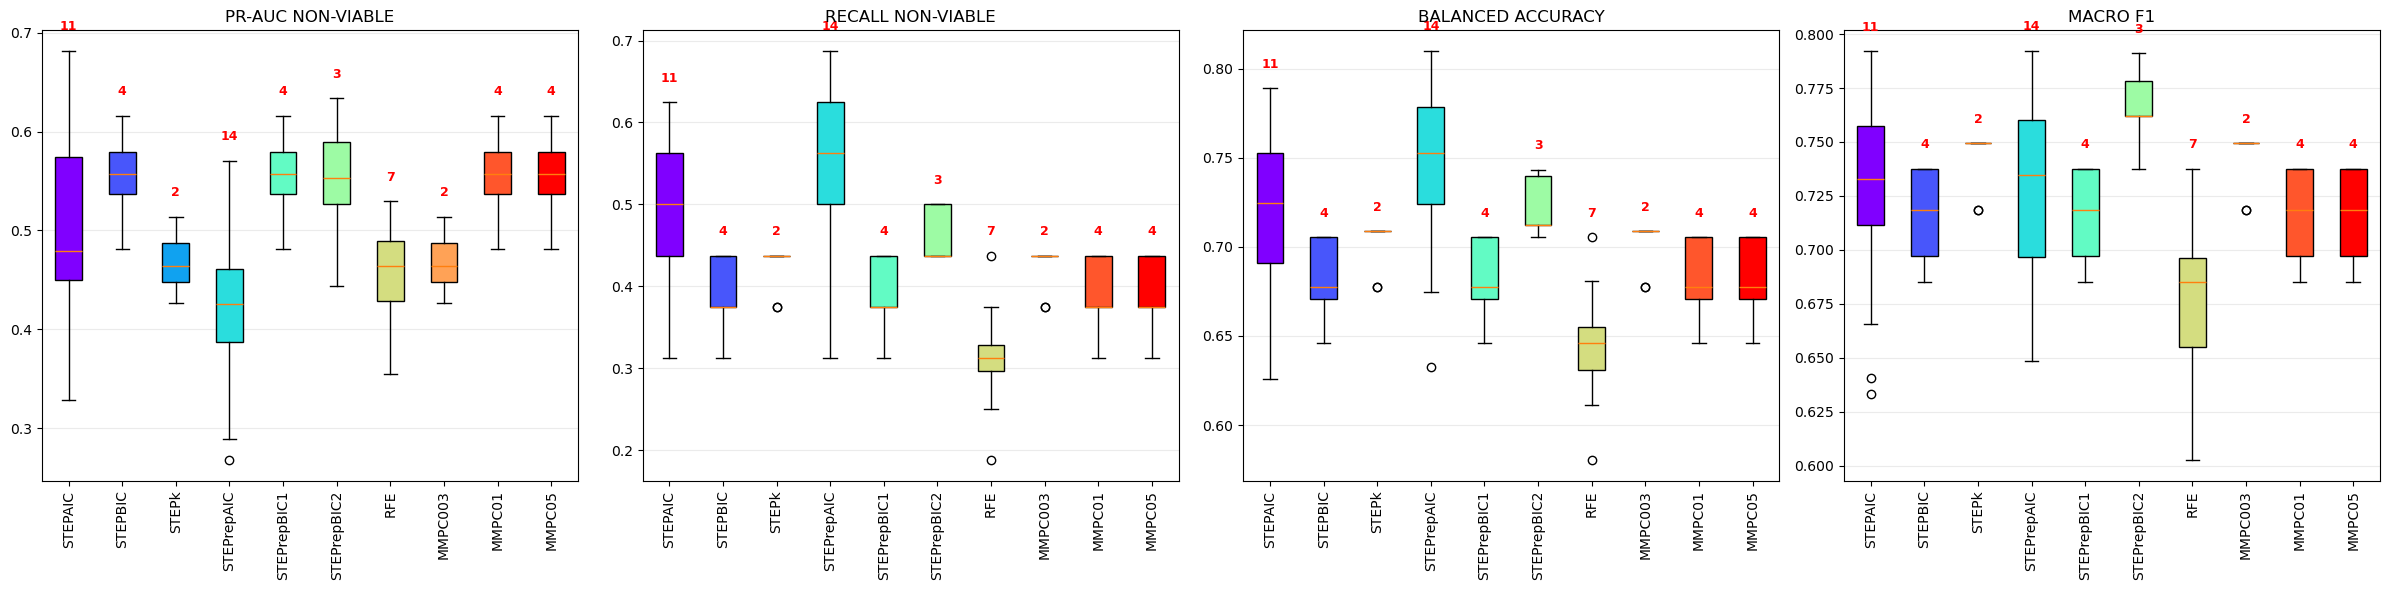

Tiempo total de ejecucion: 92.4 s


Metodo,Variables,N_Variables,ESPE_CV
STEPAIC,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas + Provincia=Alicante + promotor_experiencia_anios + equity_promotor_pct + coste_total_proyecto + tipo_promotor=sociedad_patrimonial + m2 por Vivienda + Provincia=Valencia,11,0.4750 ± 0.0938
STEPBIC,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas,4,0.3969 ± 0.0367
STEPk,riesgo_legal_titulo=alto + LTV,2,0.4313 ± 0.0192
STEPrepAIC,LTV + Provincia=Alicante + Provincia=Malaga + Provincia=Valencia + coste_total_proyecto + equity_promotor_pct + indice_coste_base + m2 por Vivienda + porcentaje_preventas + promotor_experiencia_anios + riesgo_legal_titulo=alto + riesgo_legal_titulo=medio + tipo_promotor=cooperativa + tipo_promotor=promotor_pyme,14,0.5563 ± 0.0882
STEPrepBIC1,LTV + porcentaje_preventas + riesgo_legal_titulo=alto + riesgo_legal_titulo=medio,4,0.3969 ± 0.0367
STEPrepBIC2,LTV + promotor_proyectos_previos + riesgo_legal_titulo=alto,3,0.4625 ± 0.0314
RFE,m2 por Vivienda + Volatilidad 4A Viviendas + equity_promotor_pct + LTV + LTC + porcentaje_preventas + riesgo_legal_titulo=alto,7,0.3125 ± 0.0574
MMPC003,riesgo_legal_titulo=alto + LTV,2,0.4313 ± 0.0192
MMPC01,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas,4,0.3969 ± 0.0367
MMPC05,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas,4,0.3969 ± 0.0367


Metodo,Variables,N_Variables,PR_AUC_CV
STEPAIC,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas + Provincia=Alicante + promotor_experiencia_anios + equity_promotor_pct + coste_total_proyecto + tipo_promotor=sociedad_patrimonial + m2 por Vivienda + Provincia=Valencia,11,0.5028 ± 0.0893
STEPBIC,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas,4,0.5541 ± 0.0384
STEPk,riesgo_legal_titulo=alto + LTV,2,0.4668 ± 0.0247
STEPrepAIC,LTV + Provincia=Alicante + Provincia=Malaga + Provincia=Valencia + coste_total_proyecto + equity_promotor_pct + indice_coste_base + m2 por Vivienda + porcentaje_preventas + promotor_experiencia_anios + riesgo_legal_titulo=alto + riesgo_legal_titulo=medio + tipo_promotor=cooperativa + tipo_promotor=promotor_pyme,14,0.4206 ± 0.0792
STEPrepBIC1,LTV + porcentaje_preventas + riesgo_legal_titulo=alto + riesgo_legal_titulo=medio,4,0.5541 ± 0.0384
STEPrepBIC2,LTV + promotor_proyectos_previos + riesgo_legal_titulo=alto,3,0.5493 ± 0.0460
RFE,m2 por Vivienda + Volatilidad 4A Viviendas + equity_promotor_pct + LTV + LTC + porcentaje_preventas + riesgo_legal_titulo=alto,7,0.4542 ± 0.0510
MMPC003,riesgo_legal_titulo=alto + LTV,2,0.4668 ± 0.0247
MMPC01,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas,4,0.5541 ± 0.0384
MMPC05,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas,4,0.5541 ± 0.0384


Metodo,Variables,N_Variables,BALANCED_ACCURACY_CV
STEPAIC,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas + Provincia=Alicante + promotor_experiencia_anios + equity_promotor_pct + coste_total_proyecto + tipo_promotor=sociedad_patrimonial + m2 por Vivienda + Provincia=Valencia,11,0.7155 ± 0.0470
STEPBIC,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas,4,0.6844 ± 0.0180
STEPk,riesgo_legal_titulo=alto + LTV,2,0.7055 ± 0.0096
STEPrepAIC,LTV + Provincia=Alicante + Provincia=Malaga + Provincia=Valencia + coste_total_proyecto + equity_promotor_pct + indice_coste_base + m2 por Vivienda + porcentaje_preventas + promotor_experiencia_anios + riesgo_legal_titulo=alto + riesgo_legal_titulo=medio + tipo_promotor=cooperativa + tipo_promotor=promotor_pyme,14,0.7448 ± 0.0451
STEPrepBIC1,LTV + porcentaje_preventas + riesgo_legal_titulo=alto + riesgo_legal_titulo=medio,4,0.6844 ± 0.0180
STEPrepBIC2,LTV + promotor_proyectos_previos + riesgo_legal_titulo=alto,3,0.7233 ± 0.0151
RFE,m2 por Vivienda + Volatilidad 4A Viviendas + equity_promotor_pct + LTV + LTC + porcentaje_preventas + riesgo_legal_titulo=alto,7,0.6441 ± 0.0291
MMPC003,riesgo_legal_titulo=alto + LTV,2,0.7055 ± 0.0096
MMPC01,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas,4,0.6844 ± 0.0180
MMPC05,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas,4,0.6844 ± 0.0180


Metodo,Variables,N_Variables,MACRO_F1_CV
STEPAIC,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas + Provincia=Alicante + promotor_experiencia_anios + equity_promotor_pct + coste_total_proyecto + tipo_promotor=sociedad_patrimonial + m2 por Vivienda + Provincia=Valencia,11,0.7267 ± 0.0444
STEPBIC,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas,4,0.7165 ± 0.0183
STEPk,riesgo_legal_titulo=alto + LTV,2,0.7463 ± 0.0095
STEPrepAIC,LTV + Provincia=Alicante + Provincia=Malaga + Provincia=Valencia + coste_total_proyecto + equity_promotor_pct + indice_coste_base + m2 por Vivienda + porcentaje_preventas + promotor_experiencia_anios + riesgo_legal_titulo=alto + riesgo_legal_titulo=medio + tipo_promotor=cooperativa + tipo_promotor=promotor_pyme,14,0.7273 ± 0.0419
STEPrepBIC1,LTV + porcentaje_preventas + riesgo_legal_titulo=alto + riesgo_legal_titulo=medio,4,0.7165 ± 0.0183
STEPrepBIC2,LTV + promotor_proyectos_previos + riesgo_legal_titulo=alto,3,0.7691 ± 0.0140
RFE,m2 por Vivienda + Volatilidad 4A Viviendas + equity_promotor_pct + LTV + LTC + porcentaje_preventas + riesgo_legal_titulo=alto,7,0.6785 ± 0.0336
MMPC003,riesgo_legal_titulo=alto + LTV,2,0.7463 ± 0.0095
MMPC01,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas,4,0.7165 ± 0.0183
MMPC05,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas,4,0.7165 ± 0.0183


,riesgo_legal_titulo=alto,LTV,porcentaje_preventas,riesgo_legal_titulo=medio,m2 por Vivienda,equity_promotor_pct,Provincia=Alicante,Provincia=Valencia,coste_total_proyecto,promotor_experiencia_anios,tipo_promotor=promotor_pyme,tipo_promotor=cooperativa,LTC,promotor_proyectos_previos,indice_coste_base,Volatilidad 4A Viviendas,Provincia=Malaga,tipo_promotor=sociedad_patrimonial
STEPAIC,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,1
STEPBIC,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
STEPk,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
STEPrepAIC,1,1,1,1,1,1,1,1,1,1,1,1,0,0,1,0,1,0
STEPrepBIC1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
STEPrepBIC2,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
RFE,1,1,1,0,1,1,0,0,0,0,0,0,1,0,0,1,0,0
MMPC003,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
MMPC01,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
MMPC05,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Saved: tabla_presencia_variables_origination.html


In [95]:
# ============================================================
# BLOCK 77: Run automatic variable selection on origination_view1
# Purpose:
#   - Apply comparar_modelos_binaria() to the origination modeling base
#   - Display model-selection and imbalance-focused comparison tables
#   - Display the variable-presence matrix and save it as HTML
# DataFrame created:
#   - union1_origination
# Objects created:
#   - modelos_origination (dict of selected variable lists per method)
# Files created:
#   - tabla_presencia_variables_origination.html
# ============================================================

result_origination = comparar_modelos_binaria(
    origination_view1,
    target_col,
    num_vars_rfe=7,
    k_general=14,
    max_k_mmpc=3,
    t1=0.003,
    t2=0.01,
    t3=0.05,
    grupos=4,
    semilla=GLOBAL_SEED,
    repe=20
)

union1_origination = result_origination["medias"]
modelos_origination = result_origination["listconti"]

display(crear_tabla_modelos_binaria(union1_origination, modelos_origination, metric="espe"))
display(crear_tabla_modelos_binaria(union1_origination, modelos_origination, metric="pr_auc"))
display(crear_tabla_modelos_binaria(union1_origination, modelos_origination, metric="balanced_accuracy"))
display(crear_tabla_modelos_binaria(union1_origination, modelos_origination, metric="macro_f1"))

tabla_presencia_origination = crear_tabla_presencia(union1_origination, modelos_origination)
display(tabla_presencia_origination)

tabla_presencia_origination.to_html("tabla_presencia_variables_origination.html")
print("Saved: tabla_presencia_variables_origination.html")

STEPrepBIC2 was selected as the leading reduced specification for the origination view. The model retains only three predictors, LTV, riesgo_legal_titulo=alto, and promotor_proyectos_previos, while achieving competitive PR-AUC for Non-viable operations, the highest Macro F1, strong Balanced accuracy, and relatively stable performance across repeated cross-validation. From a business perspective, the specification concentrates the initial underwriting decision on three core dimensions: the level of leverage against the collateral, the existence of material legal risk over the property title, and the promoter’s previous project experience. This makes the model easier to interpret and implement as an initial screening tool, since each selected variable corresponds to information that can be assessed before financing approval. The result suggests that a parsimonious origination rule based on collateral protection, legal enforceability, and promoter track record may provide a useful first classification of operations before a more detailed credit review. The selection remains provisional until the reduced model is evaluated on the untouched test set and compared with the broader candidate specifications.

Ejecutando STEPWISE AIC...
Ejecutando STEPWISE BIC...
Ejecutando STEPWISE con k general...
Ejecutando STEPWISE repetido AIC...
Ejecutando STEPWISE repetido BIC...
Ejecutando RFE...
Ejecutando MMPC...
Fin MMPC...
fin STEPAIC
fin STEPBIC
fin STEPk
fin STEPrepAIC
fin STEPrepBIC1
fin STEPrepBIC2
fin RFE
fin MMPC003
fin MMPC01
fin MMPC05


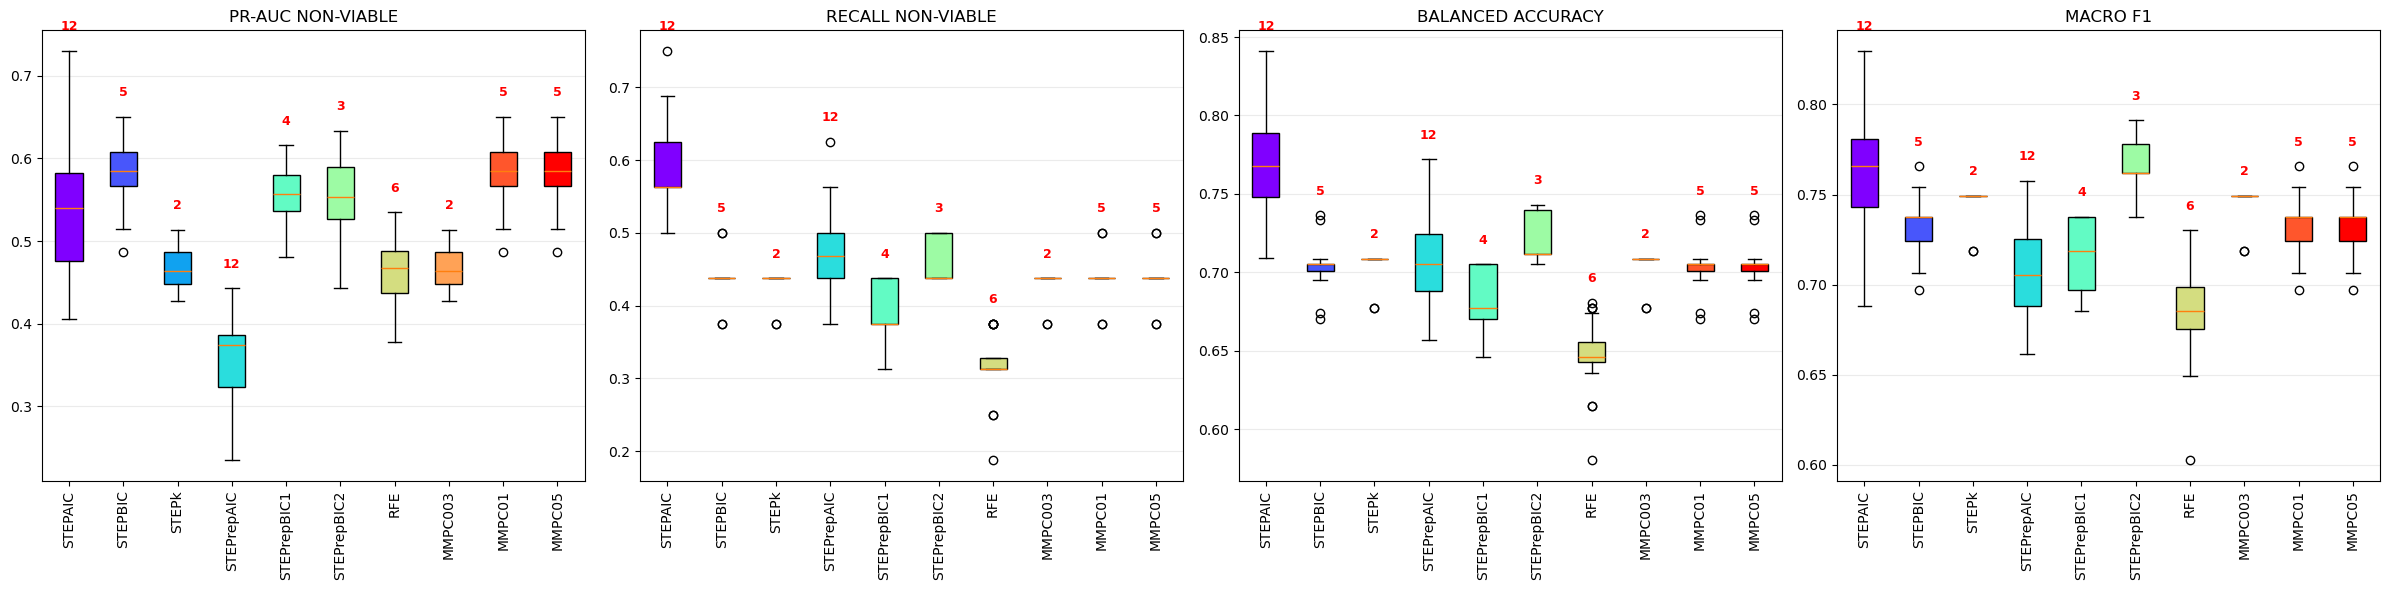

Tiempo total de ejecucion: 155.9 s


Metodo,Variables,N_Variables,ESPE_CV
STEPAIC,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas + stop_desembolsos + tipo_promotor=sociedad_patrimonial + hito_actual=pre_draw + promotor_experiencia_anios + indice_coste_seguimiento + Provincia=Alicante + m2 por Vivienda + equity_promotor_pct,12,0.5875 ± 0.0654
STEPBIC,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas + stop_desembolsos,5,0.4375 ± 0.0287
STEPk,riesgo_legal_titulo=alto + LTV,2,0.4313 ± 0.0192
STEPrepAIC,LTV + Provincia=Alicante + Volatilidad 4A m2 + coste_total_proyecto + equity_promotor_pct + hito_actual=avance_intermedio + hito_actual=pre_draw + indice_coste_seguimiento + promotor_experiencia_anios + retraso_obra_meses + riesgo_legal_titulo=alto + riesgo_legal_titulo=medio,12,0.4750 ± 0.0622
STEPrepBIC1,LTV + porcentaje_preventas + riesgo_legal_titulo=alto + riesgo_legal_titulo=medio,4,0.3969 ± 0.0367
STEPrepBIC2,LTV + promotor_proyectos_previos + riesgo_legal_titulo=alto,3,0.4625 ± 0.0314
RFE,m2 por Vivienda + equity_promotor_pct + LTV + LTC + porcentaje_preventas + riesgo_legal_titulo=alto,6,0.3156 ± 0.0474
MMPC003,riesgo_legal_titulo=alto + LTV,2,0.4313 ± 0.0192
MMPC01,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas + stop_desembolsos,5,0.4375 ± 0.0287
MMPC05,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas + stop_desembolsos,5,0.4375 ± 0.0287


Metodo,Variables,N_Variables,PR_AUC_CV
STEPAIC,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas + stop_desembolsos + tipo_promotor=sociedad_patrimonial + hito_actual=pre_draw + promotor_experiencia_anios + indice_coste_seguimiento + Provincia=Alicante + m2 por Vivienda + equity_promotor_pct,12,0.5403 ± 0.0834
STEPBIC,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas + stop_desembolsos,5,0.5822 ± 0.0427
STEPk,riesgo_legal_titulo=alto + LTV,2,0.4668 ± 0.0247
STEPrepAIC,LTV + Provincia=Alicante + Volatilidad 4A m2 + coste_total_proyecto + equity_promotor_pct + hito_actual=avance_intermedio + hito_actual=pre_draw + indice_coste_seguimiento + promotor_experiencia_anios + retraso_obra_meses + riesgo_legal_titulo=alto + riesgo_legal_titulo=medio,12,0.3601 ± 0.0511
STEPrepBIC1,LTV + porcentaje_preventas + riesgo_legal_titulo=alto + riesgo_legal_titulo=medio,4,0.5541 ± 0.0384
STEPrepBIC2,LTV + promotor_proyectos_previos + riesgo_legal_titulo=alto,3,0.5493 ± 0.0460
RFE,m2 por Vivienda + equity_promotor_pct + LTV + LTC + porcentaje_preventas + riesgo_legal_titulo=alto,6,0.4629 ± 0.0438
MMPC003,riesgo_legal_titulo=alto + LTV,2,0.4668 ± 0.0247
MMPC01,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas + stop_desembolsos,5,0.5822 ± 0.0427
MMPC05,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas + stop_desembolsos,5,0.5822 ± 0.0427


Metodo,Variables,N_Variables,BALANCED_ACCURACY_CV
STEPAIC,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas + stop_desembolsos + tipo_promotor=sociedad_patrimonial + hito_actual=pre_draw + promotor_experiencia_anios + indice_coste_seguimiento + Provincia=Alicante + m2 por Vivienda + equity_promotor_pct,12,0.7684 ± 0.0332
STEPBIC,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas + stop_desembolsos,5,0.7034 ± 0.0147
STEPk,riesgo_legal_titulo=alto + LTV,2,0.7055 ± 0.0096
STEPrepAIC,LTV + Provincia=Alicante + Volatilidad 4A m2 + coste_total_proyecto + equity_promotor_pct + hito_actual=avance_intermedio + hito_actual=pre_draw + indice_coste_seguimiento + promotor_experiencia_anios + retraso_obra_meses + riesgo_legal_titulo=alto + riesgo_legal_titulo=medio,12,0.7088 ± 0.0306
STEPrepBIC1,LTV + porcentaje_preventas + riesgo_legal_titulo=alto + riesgo_legal_titulo=medio,4,0.6844 ± 0.0180
STEPrepBIC2,LTV + promotor_proyectos_previos + riesgo_legal_titulo=alto,3,0.7233 ± 0.0151
RFE,m2 por Vivienda + equity_promotor_pct + LTV + LTC + porcentaje_preventas + riesgo_legal_titulo=alto,6,0.6465 ± 0.0244
MMPC003,riesgo_legal_titulo=alto + LTV,2,0.7055 ± 0.0096
MMPC01,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas + stop_desembolsos,5,0.7034 ± 0.0147
MMPC05,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas + stop_desembolsos,5,0.7034 ± 0.0147


Metodo,Variables,N_Variables,MACRO_F1_CV
STEPAIC,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas + stop_desembolsos + tipo_promotor=sociedad_patrimonial + hito_actual=pre_draw + promotor_experiencia_anios + indice_coste_seguimiento + Provincia=Alicante + m2 por Vivienda + equity_promotor_pct,12,0.7628 ± 0.0352
STEPBIC,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas + stop_desembolsos,5,0.7316 ± 0.0166
STEPk,riesgo_legal_titulo=alto + LTV,2,0.7463 ± 0.0095
STEPrepAIC,LTV + Provincia=Alicante + Volatilidad 4A m2 + coste_total_proyecto + equity_promotor_pct + hito_actual=avance_intermedio + hito_actual=pre_draw + indice_coste_seguimiento + promotor_experiencia_anios + retraso_obra_meses + riesgo_legal_titulo=alto + riesgo_legal_titulo=medio,12,0.7079 ± 0.0267
STEPrepBIC1,LTV + porcentaje_preventas + riesgo_legal_titulo=alto + riesgo_legal_titulo=medio,4,0.7165 ± 0.0183
STEPrepBIC2,LTV + promotor_proyectos_previos + riesgo_legal_titulo=alto,3,0.7691 ± 0.0140
RFE,m2 por Vivienda + equity_promotor_pct + LTV + LTC + porcentaje_preventas + riesgo_legal_titulo=alto,6,0.6830 ± 0.0295
MMPC003,riesgo_legal_titulo=alto + LTV,2,0.7463 ± 0.0095
MMPC01,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas + stop_desembolsos,5,0.7316 ± 0.0166
MMPC05,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas + stop_desembolsos,5,0.7316 ± 0.0166


,riesgo_legal_titulo=alto,LTV,riesgo_legal_titulo=medio,porcentaje_preventas,stop_desembolsos,equity_promotor_pct,m2 por Vivienda,Provincia=Alicante,hito_actual=pre_draw,indice_coste_seguimiento,promotor_experiencia_anios,retraso_obra_meses,LTC,promotor_proyectos_previos,hito_actual=avance_intermedio,coste_total_proyecto,Volatilidad 4A m2,tipo_promotor=sociedad_patrimonial
STEPAIC,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,1
STEPBIC,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
STEPk,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
STEPrepAIC,1,1,1,0,0,1,0,1,1,1,1,1,0,0,1,1,1,0
STEPrepBIC1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
STEPrepBIC2,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
RFE,1,1,0,1,0,1,1,0,0,0,0,0,1,0,0,0,0,0
MMPC003,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
MMPC01,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
MMPC05,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0


Saved: tabla_presencia_variables_monitoring.html


In [96]:
# ============================================================
# BLOCK 78: Run automatic variable selection on monitoring_view1
# Purpose:
#   - Apply comparar_modelos_binaria() to the monitoring modeling base
#   - Display model-selection and imbalance-focused comparison tables
#   - Display the variable-presence matrix and save it as HTML
# DataFrame created:
#   - union1_monitoring
# Objects created:
#   - modelos_monitoring (dict of selected variable lists per method)
# Files created:
#   - tabla_presencia_variables_monitoring.html
# ============================================================

result_monitoring = comparar_modelos_binaria(
    monitoring_view1,
    target_col,
    num_vars_rfe=7,
    k_general=14,
    max_k_mmpc=3,
    t1=0.003,
    t2=0.01,
    t3=0.05,
    grupos=4,
    semilla=GLOBAL_SEED,
    repe=20
)

union1_monitoring = result_monitoring["medias"]
modelos_monitoring = result_monitoring["listconti"]

display(crear_tabla_modelos_binaria(union1_monitoring, modelos_monitoring, metric="espe"))
display(crear_tabla_modelos_binaria(union1_monitoring, modelos_monitoring, metric="pr_auc"))
display(crear_tabla_modelos_binaria(union1_monitoring, modelos_monitoring, metric="balanced_accuracy"))
display(crear_tabla_modelos_binaria(union1_monitoring, modelos_monitoring, metric="macro_f1"))

tabla_presencia_monitoring = crear_tabla_presencia(union1_monitoring, modelos_monitoring)
display(tabla_presencia_monitoring)

tabla_presencia_monitoring.to_html("tabla_presencia_variables_monitoring.html")
print("Saved: tabla_presencia_variables_monitoring.html")

STEPBIC was selected as the reduced specification for the monitoring view. The model retains five predictors, LTV, riesgo_legal_titulo=alto, riesgo_legal_titulo=medio, porcentaje_preventas, and stop_desembolsos, and achieved the highest mean PR-AUC for Non-viable operations with moderate variability across repeated cross-validation. Although other specifications obtained higher values in some classification metrics, STEPBIC was preferred because it provides a more stable and parsimonious structure that is also consistent with the monitoring stage. From a business perspective, the model combines collateral leverage and legal enforceability with commercial progress and the lender’s capacity to suspend further disbursements. This allows the monitoring view to assess whether an operation remains viable as project conditions evolve, rather than reproducing the same decision logic used at origination. The selection remains provisional until its performance is confirmed on the untouched test set.

In [97]:
# ============================================================
# BLOCK 79: Summary table of selected logistic models
# Purpose:
#   - Keep a compact record of the selected reduced logistic models
#   - Store their selected variables and key CV metrics
# DataFrame created:
#   - selected_logistic_summary
# Files created:
#   - None
# ============================================================

selected_logistic_methods = {
    "Origination view": "STEPrepBIC2",
    "Monitoring view": "STEPBIC"
}

selection_sources = {
    "Origination view": (union1_origination, modelos_origination),
    "Monitoring view": (union1_monitoring, modelos_monitoring)
}

metric_map = {
    "PR_AUC_CV": "pr_auc",
    "ESPE_CV": "espe",
    "BALANCED_ACCURACY_CV": "balanced_accuracy",
    "MACRO_F1_CV": "macro_f1"
}

rows = []

for view_name, method_name in selected_logistic_methods.items():
    union_df, modelos_dict = selection_sources[view_name]
    selected_vars = modelos_dict[method_name]

    row = {
        "View": view_name,
        "Selected model": method_name,
        "Selected variables": " + ".join(selected_vars),
        "N_Variables": len(selected_vars)
    }

    for output_col, metric_col in metric_map.items():
        stats = (
            union_df.loc[
                union_df["modelo"].astype(str) == method_name,
                metric_col
            ]
            .agg(["mean", "std"])
        )
        row[output_col] = f"{stats['mean']:.4f} ± {stats['std']:.4f}"

    rows.append(row)

selected_logistic_summary = pd.DataFrame(rows)

display(
    selected_logistic_summary.style
    .set_caption("Summary of selected logistic models")
    .set_table_styles([
        {"selector": "th", "props": [
            ("background-color", "#4A90E2"),
            ("color", "white"),
            ("font-weight", "bold"),
            ("padding", "6px 10px")
        ]},
        {"selector": "td", "props": [
            ("padding", "6px 10px"),
            ("border", "1px solid #ccc")
        ]}
    ])
    .hide(axis="index")
)

View,Selected model,Selected variables,N_Variables,PR_AUC_CV,ESPE_CV,BALANCED_ACCURACY_CV,MACRO_F1_CV
Origination view,STEPrepBIC2,LTV + promotor_proyectos_previos + riesgo_legal_titulo=alto,3,0.5493 ± 0.0460,0.4625 ± 0.0314,0.7233 ± 0.0151,0.7691 ± 0.0140
Monitoring view,STEPBIC,riesgo_legal_titulo=alto + LTV + riesgo_legal_titulo=medio + porcentaje_preventas + stop_desembolsos,5,0.5822 ± 0.0427,0.4375 ± 0.0287,0.7034 ± 0.0147,0.7316 ± 0.0166


In [101]:
# ============================================================
# BLOCK 80: Fit selected reduced logistic models
# Purpose:
#   - Fit the selected reduced specification for each view
#   - Use the same transformed training vectors used in selection
#   - Preserve the selected predictors for test evaluation
# Models fitted:
#   - Origination: STEPrepBIC2
#   - Monitoring: STEPBIC
# Objects created:
#   - selected_reduced_methods
#   - selected_reduced_variables
#   - reduced_logistic_models
# DataFrame created:
#   - reduced_logistic_fit_summary
# Files created:
#   - None
# ============================================================

selected_reduced_methods = {
    "origination_view": "STEPrepBIC2",
    "monitoring_view": "STEPBIC"
}

selected_reduced_variables = {
    "origination_view": modelos_origination["STEPrepBIC2"],
    "monitoring_view": modelos_monitoring["STEPBIC"]
}

transformed_training_views = {
    "origination_view": origination_view1,
    "monitoring_view": monitoring_view1
}

reduced_logistic_models = {}
fit_summary_rows = []

for view_name, training_view in transformed_training_views.items():
    method_name = selected_reduced_methods[view_name]
    selected_variables = selected_reduced_variables[view_name]

    X_train_reduced = training_view[selected_variables].copy()
    y_train_reduced = training_view[target_col].astype(int).copy()

    reduced_model = LogisticRegression(
        penalty=None,
        solver="lbfgs",
        max_iter=5000,
        random_state=GLOBAL_SEED
    )

    reduced_model.fit(
        X_train_reduced,
        y_train_reduced
    )

    reduced_logistic_models[view_name] = reduced_model

    fit_summary_rows.append({
        "View": view_name.replace("_view", "").title(),
        "Selected method": method_name,
        "Training records": len(X_train_reduced),
        "Non-viable": int((y_train_reduced == 0).sum()),
        "Viable": int((y_train_reduced == 1).sum()),
        "N_Variables": len(selected_variables),
        "Converged": reduced_model.n_iter_[0] < 5000
    })

reduced_logistic_fit_summary = pd.DataFrame(fit_summary_rows)

display(
    reduced_logistic_fit_summary.style
    .set_caption("Selected reduced logistic models fitted on training data")
    .hide(axis="index")
)

View,Selected method,Training records,Non-viable,Viable,N_Variables,Converged
Origination,STEPrepBIC2,164,16,148,3,True
Monitoring,STEPBIC,164,16,148,5,True


View,Method,Test records,Non-viable,Viable,Accuracy,Balanced accuracy,Precision Non-viable,Recall Non-viable,F1 Non-viable,Recall Viable,Macro F1,ROC-AUC,PR-AUC
Origination,STEPrepBIC2,71,7,64,92.96%,64.29%,100.00%,28.57%,44.44%,100.00%,70.34%,97.77%,89.92%
Monitoring,STEPBIC,71,7,64,94.37%,84.15%,71.43%,71.43%,71.43%,96.88%,84.15%,97.99%,84.29%


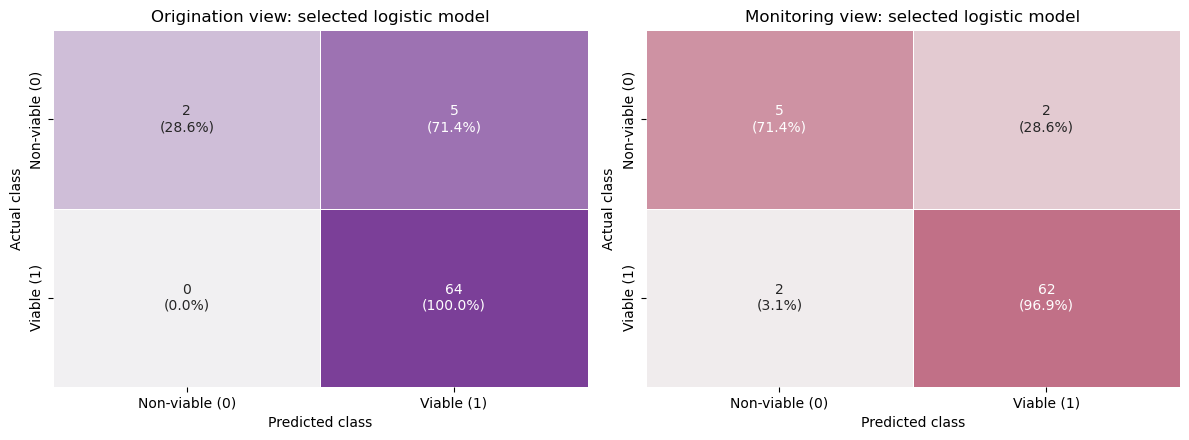

In [102]:
# ============================================================
# BLOCK 81: Evaluate selected reduced logistic models on test
# Purpose:
#   - Transform test data using the training-derived view1 structure
#   - Evaluate the selected models on the untouched test set
#   - Compare minority-class detection across both views
# DataFrames created:
#   - reduced_logistic_test_metrics
#   - reduced_logistic_confusion_matrices
# Objects created:
#   - reduced_logistic_test_results
# Files created:
#   - None
# ============================================================

view1_preprocessing = {
    "origination_view": origination_view1_preprocessing,
    "monitoring_view": monitoring_view1_preprocessing
}

view_colors = {
    "origination_view": "#7B3F98",
    "monitoring_view": "#C06C84"
}


def transform_view1_test(view_name):
    X_test = regression_splits[view_name]["X_test"].copy()
    preprocessing = view1_preprocessing[view_name]

    numeric_columns = preprocessing["numeric_columns"]
    categorical_columns = preprocessing["categorical_columns"]

    X_numeric = (
        X_test[numeric_columns]
        .apply(pd.to_numeric, errors="raise")
        .astype(float)
        .subtract(preprocessing["numeric_mean"])
        .divide(preprocessing["numeric_std"])
    )

    X_dummy = pd.get_dummies(
        X_test[categorical_columns].astype(str),
        prefix_sep="=",
        dtype=float
    ).reindex(
        columns=preprocessing["dummy_columns"],
        fill_value=0.0
    )

    X_transformed = pd.concat(
        [X_numeric, X_dummy],
        axis=1
    ).reindex(
        columns=preprocessing["predictor_columns"]
    )

    assert X_transformed.index.equals(X_test.index)
    assert not X_transformed.isna().any().any()
    assert np.isfinite(X_transformed.to_numpy()).all()

    return X_transformed


reduced_logistic_test_results = {}
reduced_logistic_confusion_matrices = {}
test_metric_rows = []

for view_name, model in reduced_logistic_models.items():
    X_test_view1 = transform_view1_test(view_name)
    selected_variables = selected_reduced_variables[view_name]

    X_test_reduced = X_test_view1[selected_variables]
    y_test = (
        regression_splits[view_name]["y_test"]
        .reindex(X_test_reduced.index)
        .astype(int)
    )

    probability_viable = model.predict_proba(
        X_test_reduced
    )[:, 1]

    probability_non_viable = 1 - probability_viable
    prediction = (probability_viable >= 0.50).astype(int)

    confusion_values = confusion_matrix(
        y_test,
        prediction,
        labels=[0, 1]
    )

    confusion_table = pd.DataFrame(
        confusion_values,
        index=class_labels,
        columns=class_labels
    )

    reduced_logistic_confusion_matrices[
        view_name
    ] = confusion_table

    reduced_logistic_test_results[view_name] = {
        "y_test": y_test,
        "prediction": prediction,
        "probability_viable": probability_viable,
        "probability_non_viable": probability_non_viable
    }

    non_viable_actual = y_test.eq(0).astype(int)

    test_metric_rows.append({
        "View": view_name.replace("_view", "").title(),
        "Method": selected_reduced_methods[view_name],
        "Test records": len(y_test),
        "Non-viable": int((y_test == 0).sum()),
        "Viable": int((y_test == 1).sum()),
        "Accuracy": accuracy_score(y_test, prediction),
        "Balanced accuracy": balanced_accuracy_score(
            y_test,
            prediction
        ),
        "Precision Non-viable": precision_score(
            y_test,
            prediction,
            pos_label=0,
            zero_division=0
        ),
        "Recall Non-viable": recall_score(
            y_test,
            prediction,
            pos_label=0,
            zero_division=0
        ),
        "F1 Non-viable": f1_score(
            y_test,
            prediction,
            pos_label=0,
            zero_division=0
        ),
        "Recall Viable": recall_score(
            y_test,
            prediction,
            pos_label=1,
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_test,
            prediction,
            average="macro",
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            non_viable_actual,
            probability_non_viable
        ),
        "PR-AUC": average_precision_score(
            non_viable_actual,
            probability_non_viable
        )
    })


reduced_logistic_test_metrics = pd.DataFrame(
    test_metric_rows
)

metric_columns = [
    "Accuracy",
    "Balanced accuracy",
    "Precision Non-viable",
    "Recall Non-viable",
    "F1 Non-viable",
    "Recall Viable",
    "Macro F1",
    "ROC-AUC",
    "PR-AUC"
]

display(
    reduced_logistic_test_metrics.style
    .format({
        column: "{:.2%}"
        for column in metric_columns
    })
    .set_caption(
        "Selected reduced logistic models: untouched test performance"
    )
    .hide(axis="index")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, view_name in zip(
    axes,
    ["origination_view", "monitoring_view"]
):
    confusion_table = reduced_logistic_confusion_matrices[
        view_name
    ]

    confusion_pct = (
        confusion_table
        .div(confusion_table.sum(axis=1), axis=0)
        .mul(100)
    )

    annotations = create_confusion_annotations(
        confusion_table,
        confusion_pct
    )

    sns.heatmap(
        confusion_pct,
        annot=annotations,
        fmt="",
        cmap=sns.light_palette(
            view_colors[view_name],
            as_cmap=True
        ),
        vmin=0,
        vmax=100,
        cbar=False,
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(
        f"{view_name.replace('_view', '').title()} view: "
        f"selected logistic model"
    )
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")

plt.tight_layout()
plt.show()

On the untouched test set of 71 operations, including 7 Non-viable and 64 Viable cases, both reduced logistic models achieved high overall accuracy, with 92.96% for origination and 94.37% for monitoring. However, because the target is strongly imbalanced, the comparison should focus mainly on minority-class detection and balanced metrics. The monitoring model produced the stronger classification balance, correctly identifying 5 of the 7 Non-viable operations, equivalent to a Recall Non-viable of 71.43%, compared with only 2 of 7 and 28.57% for the origination model. Monitoring also achieved higher F1 Non-viable, 71.43% versus 44.44%, higher Balanced accuracy, 84.15% versus 64.29%, and higher Macro F1, 84.15% versus 70.34%. At the same time, it correctly classified 62 of the 64 Viable operations, with a Recall Viable of 96.88%, while origination classified all 64 Viable operations correctly and obtained 100.00% Recall Viable. Origination reached 100.00% Precision Non-viable because both operations classified as Non-viable were correct, but it failed to detect the other five Non-viable cases. Its PR-AUC was slightly higher, 89.92% compared with 84.29% for monitoring, while both models showed very high ROC-AUC values, 97.77% and 97.99%, indicating strong ranking capacity across thresholds. From the Business Model perspective, the origination view functions as a conservative initial underwriting filter that minimizes the risk of incorrectly rejecting Viable promoter operations, but it may approve operations whose risk-adjusted economics later become negative. The monitoring view adds greater operational value by identifying a larger proportion of deteriorating operations and supporting actions such as increased supervision, corrective measures or suspension of further drawdowns. The two views should therefore be treated as complementary: origination supports the initial financing decision, while monitoring provides ongoing risk control after approval. These results remain indicative because the test set contains only seven Non-viable observations and the target reflects synthetic Business Model logic rather than observed outcomes from real Spanish lending operations.

Variable,Type,Comparison,Odds ratio,Interpretation
LTV,Numerical,5 percentage points higher,0.197,80.3% lower odds of viability
promotor_proyectos_previos,Numerical,1 additional prior project,1.162,16.2% higher odds of viability
riesgo_legal_titulo,Categorical,alto vs bajo,0.037,96.3% lower odds of viability


Variable,Type,Comparison,Odds ratio,Interpretation
riesgo_legal_titulo,Categorical,alto vs bajo,0.014,98.6% lower odds of viability
LTV,Numerical,5 percentage points higher,0.113,88.7% lower odds of viability
riesgo_legal_titulo,Categorical,medio vs bajo,0.038,96.2% lower odds of viability
porcentaje_preventas,Numerical,10 percentage points higher,1.665,66.5% higher odds of viability
stop_desembolsos,Categorical,Activated vs not activated,<0.001,More than 99.9% lower odds of viability


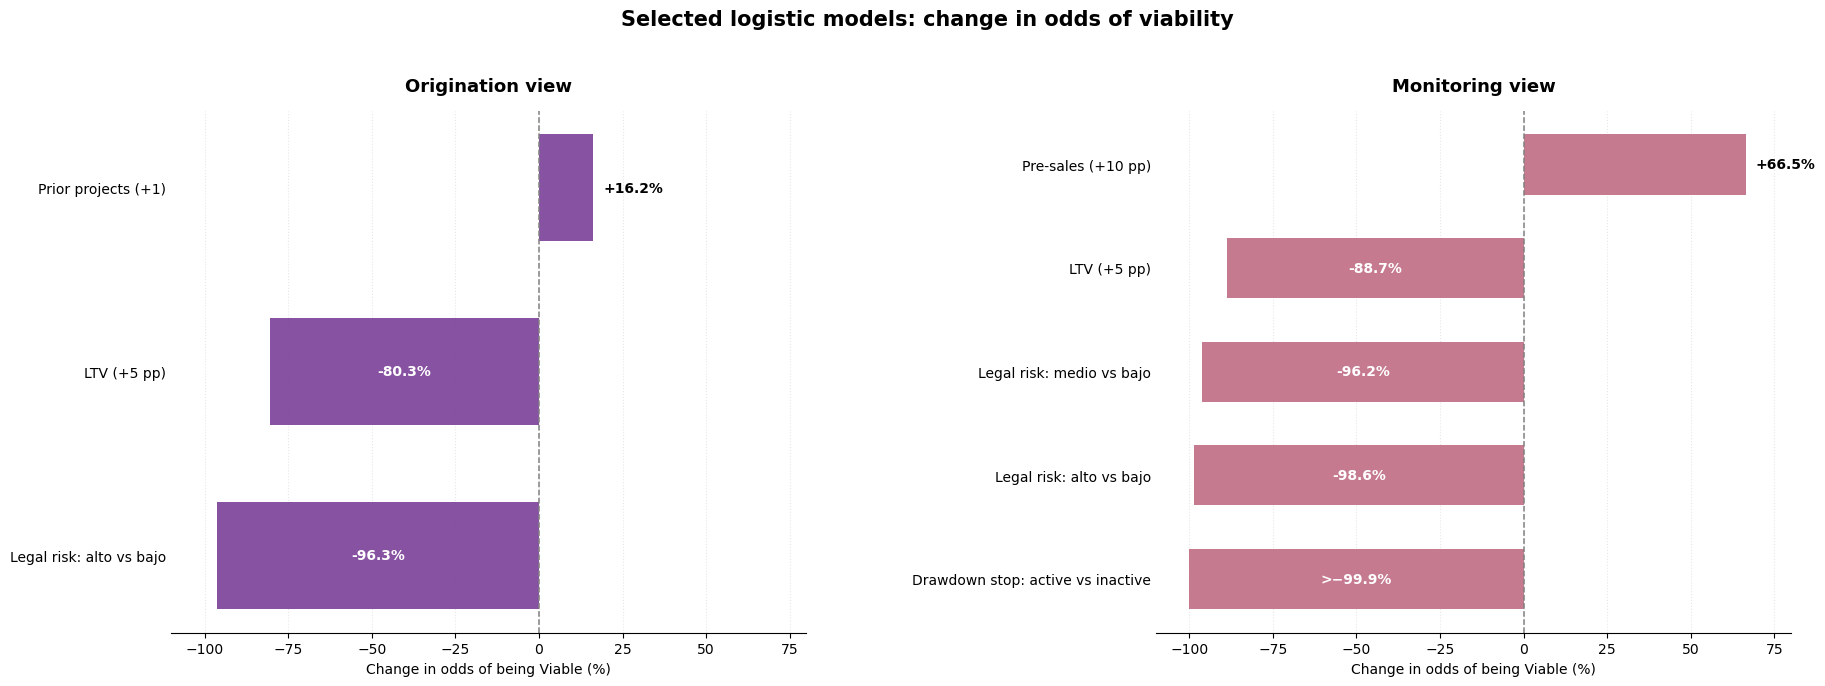

In [109]:
# ============================================================
# BLOCK 82: Interpret selected logistic model odds ratios
# Purpose:
#   - Convert selected coefficients into business odds ratios
#   - Present one interpretation table per analytical view
#   - Compare both views in one combined figure
# DataFrames created:
#   - reduced_logistic_odds_ratios
#   - origination_reduced_odds_ratios
#   - monitoring_reduced_odds_ratios
# Files created:
#   - None
# ============================================================

view_meta = {
    "origination_view": {
        "label": "Origination",
        "color": "#7B3F98",
        "preprocessing": origination_view1_preprocessing
    },
    "monitoring_view": {
        "label": "Monitoring",
        "color": "#C06C84",
        "preprocessing": monitoring_view1_preprocessing
    }
}

business_increments = {
    "LTV": (0.05, "5 percentage points higher", "LTV (+5 pp)"),
    "promotor_proyectos_previos": (
        1.00,
        "1 additional prior project",
        "Prior projects (+1)"
    ),
    "porcentaje_preventas": (
        0.10,
        "10 percentage points higher",
        "Pre-sales (+10 pp)"
    )
}


def odds_interpretation(odds_ratio):
    if odds_ratio < 0.001:
        return "More than 99.9% lower odds of viability"

    change = (odds_ratio - 1) * 100

    if change < 0:
        return f"{abs(change):.1f}% lower odds of viability"

    return f"{change:.1f}% higher odds of viability"


odds_ratio_rows = []

for view_name, model in reduced_logistic_models.items():
    variables = selected_reduced_variables[view_name]
    preprocessing = view_meta[view_name]["preprocessing"]

    if hasattr(model, "feature_names_in_"):
        assert list(model.feature_names_in_) == list(variables)

    for variable, coefficient in zip(
        variables,
        model.coef_[0]
    ):
        if "=" in variable:
            base_variable, category = variable.split("=", 1)

            reference = categorical_reference_map[
                view_name
            ][base_variable]

            variable_type = "Categorical"
            comparison = f"{category} vs {reference}"
            plot_label = (
                f"Legal risk: {category} vs {reference}"
                if base_variable == "riesgo_legal_titulo"
                else f"{base_variable}: {category} vs {reference}"
            )
            log_odds_change = coefficient

        elif variable == "stop_desembolsos":
            standard_deviation = float(
                preprocessing["numeric_std"][variable]
            )

            base_variable = variable
            variable_type = "Categorical"
            comparison = "Activated vs not activated"
            plot_label = "Drawdown stop: active vs inactive"
            log_odds_change = coefficient / standard_deviation

        else:
            increment, comparison, plot_label = (
                business_increments[variable]
            )

            standard_deviation = float(
                preprocessing["numeric_std"][variable]
            )

            base_variable = variable
            variable_type = "Numerical"

            log_odds_change = (
                coefficient
                * increment
                / standard_deviation
            )

        odds_ratio = float(
            np.exp(log_odds_change)
        )

        odds_ratio_rows.append({
            "View": view_meta[view_name]["label"],
            "Variable": base_variable,
            "Type": variable_type,
            "Comparison": comparison,
            "Plot label": plot_label,
            "Odds ratio": odds_ratio,
            "Change in odds (%)": (odds_ratio - 1) * 100,
            "Interpretation": odds_interpretation(odds_ratio)
        })


reduced_logistic_odds_ratios = pd.DataFrame(
    odds_ratio_rows
)

origination_reduced_odds_ratios = (
    reduced_logistic_odds_ratios.loc[
        reduced_logistic_odds_ratios["View"]
        == "Origination"
    ]
    .reset_index(drop=True)
)

monitoring_reduced_odds_ratios = (
    reduced_logistic_odds_ratios.loc[
        reduced_logistic_odds_ratios["View"]
        == "Monitoring"
    ]
    .reset_index(drop=True)
)


def format_odds_ratio(value):
    return "<0.001" if value < 0.001 else f"{value:.3f}"


def display_odds_table(view_results, view_label):
    table = view_results[
        [
            "Variable",
            "Type",
            "Comparison",
            "Odds ratio",
            "Interpretation"
        ]
    ].copy()

    table["Odds ratio"] = (
        table["Odds ratio"]
        .map(format_odds_ratio)
    )

    display(
        table.style
        .set_caption(
            f"{view_label} view: selected logistic model odds ratios"
        )
        .hide(axis="index")
        .set_properties(
            subset=["Odds ratio"],
            **{
                "font-weight": "bold",
                "text-align": "center"
            }
        )
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("font-size", "15px"),
                    ("font-weight", "bold"),
                    ("text-align", "left"),
                    ("margin-bottom", "8px")
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("text-align", "left")
                ]
            }
        ])
    )


def plot_combined_odds_change(
    origination_results,
    monitoring_results
):
    view_data = [
        (
            origination_results,
            "Origination view",
            "#7B3F98"
        ),
        (
            monitoring_results,
            "Monitoring view",
            "#C06C84"
        )
    ]

    max_rows = max(
        len(origination_results),
        len(monitoring_results)
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, max(6.5, max_rows * 1.05 + 2)),
        sharex=True
    )

    for ax, results, title, color in zip(
        axes,
        [item[0] for item in view_data],
        [item[1] for item in view_data],
        [item[2] for item in view_data]
    ):
        plot_data = (
            results
            .sort_values(
                "Change in odds (%)",
                ascending=False
            )
            .reset_index(drop=True)
        )

        bars = ax.barh(
            plot_data["Plot label"],
            plot_data["Change in odds (%)"],
            color=color,
            height=0.58,
            alpha=0.90
        )

        ax.axvline(
            0,
            color="gray",
            linestyle="--",
            linewidth=1.1
        )

        for bar, odds_ratio, change in zip(
            bars,
            plot_data["Odds ratio"],
            plot_data["Change in odds (%)"]
        ):
            y_position = (
                bar.get_y()
                + bar.get_height() / 2
            )

            if odds_ratio < 0.001:
                value_label = ">−99.9%"
            else:
                value_label = f"{change:+.1f}%"

            if change < 0:
                ax.text(
                    change / 2,
                    y_position,
                    value_label,
                    ha="center",
                    va="center",
                    fontsize=10,
                    fontweight="bold",
                    color="white"
                )
            else:
                ax.text(
                    change + 3,
                    y_position,
                    value_label,
                    ha="left",
                    va="center",
                    fontsize=10,
                    fontweight="bold"
                )

        ax.invert_yaxis()
        ax.set_xlim(-110, 80)

        ax.set_title(
            title,
            fontsize=13,
            fontweight="bold",
            pad=14
        )

        ax.set_xlabel(
            "Change in odds of being Viable (%)"
        )

        ax.grid(
            axis="x",
            linestyle=":",
            alpha=0.30
        )

        ax.set_axisbelow(True)
        ax.spines[
            ["top", "right", "left"]
        ].set_visible(False)

        ax.tick_params(
            axis="y",
            length=0,
            labelsize=10
        )

    fig.suptitle(
        "Selected logistic models: change in odds of viability",
        fontsize=15,
        fontweight="bold",
        y=0.98
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.98,
        bottom=0.12,
        top=0.84,
        wspace=0.55
    )

    plt.show()


display_odds_table(
    origination_reduced_odds_ratios,
    "Origination"
)

display_odds_table(
    monitoring_reduced_odds_ratios,
    "Monitoring"
)

plot_combined_odds_change(
    origination_reduced_odds_ratios,
    monitoring_reduced_odds_ratios
)

In [110]:
# Diagnostic review of stop_desembolsos against operacion_viable

stop_review_rows = []

for split_label, split_key in [
    ("Train", "train"),
    ("Test", "test")
]:
    X_split = regression_splits[
        "monitoring_view"
    ][f"X_{split_key}"]

    y_split = regression_splits[
        "monitoring_view"
    ][f"y_{split_key}"].astype(int)

    for stop_value in [0, 1]:
        mask = (
            X_split["stop_desembolsos"]
            == stop_value
        )

        total = int(mask.sum())
        non_viable = int(
            (y_split.loc[mask] == 0).sum()
        )
        viable = int(
            (y_split.loc[mask] == 1).sum()
        )

        stop_review_rows.append({
            "Sample": split_label,
            "stop_desembolsos": stop_value,
            "Operations": total,
            "Non-viable": non_viable,
            "Viable": viable,
            "Non-viable (%)": (
                non_viable / total * 100
                if total > 0
                else np.nan
            ),
            "Viable (%)": (
                viable / total * 100
                if total > 0
                else np.nan
            )
        })


stop_desembolsos_review = pd.DataFrame(
    stop_review_rows
)

display(
    stop_desembolsos_review.style
    .format({
        "Non-viable (%)": "{:.1f}%",
        "Viable (%)": "{:.1f}%"
    })
    .hide(axis="index")
    .set_caption(
        "Monitoring view: stop_desembolsos and operation viability"
    )
)

Sample,stop_desembolsos,Operations,Non-viable,Viable,Non-viable (%),Viable (%)
Train,0,32,0,32,0.0%,100.0%
Train,1,132,16,116,12.1%,87.9%
Test,0,22,0,22,0.0%,100.0%
Test,1,49,7,42,14.3%,85.7%
